<div style="font-size: 2.2em; font-weight: bold; line-height: 1.3;">Final Exam</div>

<div style="font-size: 1.5em; font-weight: bold; line-height: 1.5;">BUSN 41210: Financial Analytics</div>

<div style="font-size: 1.5em; font-weight: bold; line-height: 1.5;">Due: 5:00 pm on Sunday, Oct. 4th, 2026</div>

**Use of AI tools.** You may use any AI tool (ChatGPT, Claude, Copilot or others) for any part of this exam: code, explanations, writing. You are responsible for every answer you submit, exactly as if you had written it yourself. Every number must come from a cell in this notebook, and an answer you cannot explain or reproduce is your error, not the tool's.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



---
# Problem 1: Trees and Ensembles (20 points)

Lecture 8 built a single tree, then pruned it, then averaged many of them. This
problem walks that ladder on a small dataset where you can actually see the tree.

`Social_Network_Ads.csv` records 400 people shown an advertisement: their
`Gender`, `Age` and `EstimatedSalary`, and whether they `Purchased` (1) or not.
Use **5-fold stratified cross-validation with `random_state=7034`** for every
accuracy you report, and pass `random_state=7034` to every tree, forest and boosting model, so
the numbers are comparable to each other.

In [2]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.inspection import permutation_importance

_DATA_DIR = '/classes/41210_MiF_fall2026/Data/'
import os
_DATA_DIR = _DATA_DIR if os.path.isdir(_DATA_DIR) else './'   # class server if present, else a local copy next to the notebook
ads = pd.read_csv(_DATA_DIR + 'Social_Network_Ads.csv')
# ads = pd.read_csv('Social_Network_Ads.csv')
ads['Gender'] = (ads.Gender == 'Male').astype(int)

Xa = ads[['Gender', 'Age', 'EstimatedSalary']]
ya = ads['Purchased']

cv5 = StratifiedKFold(5, shuffle=True, random_state=7034)
def cv_acc(model):
    """5-fold cross-validated accuracy."""
    return cross_val_score(model, Xa, ya, cv=cv5, scoring='accuracy').mean()

print(f"{len(ads)} people, {ya.mean():.1%} of them purchased")

400 people, 35.8% of them purchased


**1.1.** Before any model: what accuracy does the rule *"nobody purchases"* achieve? Report it, and treat it as the number every model below has to beat.

Now grow an **unpruned** classification tree and report its 5-fold accuracy. Then sweep `max_leaf_nodes` over $\{2, 3, 4, 6, 8, 12\}$ and report the accuracy at each. Which size does cross-validation prefer (if two sizes tie, take the smaller), and what happens on either side of it?

In [3]:
from sklearn.model_selection import cross_validate
from sklearn.tree import export_text

# Plot style for every figure in this notebook: colour-blind-checked colours, light grid (no sns.set()).
C_BLUE, C_ORANGE, C_AQUA = '#2a78d6', '#eb6834', '#1baf7a'
C_INK, C_GREY, C_LIGHT = '#0b0b0b', '#52514e', '#e6e5e1'
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True,
                     'grid.color': C_LIGHT, 'grid.linewidth': 0.8, 'axes.edgecolor': C_GREY,
                     'axes.labelcolor': C_INK, 'axes.titlesize': 11, 'xtick.color': C_GREY,
                     'ytick.color': C_GREY, 'lines.linewidth': 2, 'legend.frameon': False,
                     'figure.dpi': 110})

# --- Step 0: describe the data before modelling (AI guide 6.1) ---
N = len(ya)
print(ads.dtypes.to_string())
print('\nclass counts:', ya.value_counts().sort_index().to_dict())
print('distinct values per feature:', Xa.nunique().to_dict())
print(Xa.describe().loc[['mean', 'std', 'min', 'max']].round(1).to_string())
print('\nthe five CV folds (people held out, buyers among them):',
      [(len(te), int(ya.iloc[te].sum())) for _, te in cv5.split(Xa, ya)])
assert ads.shape == (400, 5) and ya.sum() == 143 and Xa.isna().sum().sum() == 0
cells = ads.groupby(list(Xa.columns)).Purchased.agg(['size', 'sum'])
print('people who share all three features with someone else:', int(Xa.duplicated(keep=False).sum()),
      '| feature combinations with conflicting outcomes:', int(((cells['sum'] > 0) & (cells['sum'] < cells['size'])).sum()))

# --- The bar every model must beat: "nobody purchases" (majority class; L6 p.57) ---
base_correct = int((ya == 0).sum())                        # the rule is right for every non-buyer
base_folds = np.array([(ya.iloc[te] == 0).mean() for _, te in cv5.split(Xa, ya)])
assert int(round(base_folds.mean() * N)) == base_correct    # equal 80-person folds: fold average = pooled
print(f'\n"Nobody purchases": {base_correct}/{N} = {base_correct / N:.2%} correct '
      f'(fold by fold {base_folds.min():.2%} to {base_folds.max():.2%})')

User ID            int64
Gender             int64
Age                int64
EstimatedSalary    int64
Purchased          int64

class counts: {0: 257, 1: 143}
distinct values per feature: {'Gender': 2, 'Age': 43, 'EstimatedSalary': 117}
      Gender   Age  EstimatedSalary
mean     0.5  37.7          69742.5
std      0.5  10.5          34097.0
min      0.0  18.0          15000.0
max      1.0  60.0         150000.0

the five CV folds (people held out, buyers among them): [(80, 28), (80, 28), (80, 29), (80, 29), (80, 29)]
people who share all three features with someone else: 40 | feature combinations with conflicting outcomes: 1

"Nobody purchases": 257/400 = 64.25% correct (fold by fold 63.75% to 65.00%)


In [4]:
def cv_detail(model, name):
    """Accuracy on the shared cv5 folds: the mean (identical to cv_acc), people correct out of 400,
    the fold spread, and the mean training-fold accuracy (an over-fitting diagnostic, not a reported accuracy)."""
    r = cross_validate(model, Xa, ya, cv=cv5, scoring='accuracy', return_train_score=True)
    acc = r['test_score'].mean()
    assert np.isclose(acc, cv_acc(model))                    # same folds and fits as the notebook's cv_acc()
    return {'model': name, 'CV accuracy': acc, 'correct /400': int(round(acc * N)),
            'fold min': r['test_score'].min(), 'fold max': r['test_score'].max(),
            'fold sd': r['test_score'].std(ddof=1),
            'training-fold accuracy (diagnostic)': r['train_score'].mean(),
            'folds': np.rint(r['test_score'] * len(ya) / 5).astype(int)}   # people correct in each fold of 80

sizes = [2, 3, 4, 6, 8, 12]
rows = [cv_detail(DecisionTreeClassifier(random_state=7034), 'unpruned')]
rows += [cv_detail(DecisionTreeClassifier(max_leaf_nodes=k, random_state=7034), f'{k} leaves') for k in sizes]
tab11 = pd.DataFrame(rows).set_index('model')

# CV's preferred size: the most people correct; an exact tie goes to the smaller tree (the exam's rule).
best = max(tab11.loc[f'{k} leaves', 'correct /400'] for k in sizes)
tied = [k for k in sizes if tab11.loc[f'{k} leaves', 'correct /400'] == best]
k_star = min(tied)

full_unpruned = DecisionTreeClassifier(random_state=7034).fit(Xa, ya)
print(f'Unpruned tree fitted on all {N}: {full_unpruned.get_n_leaves()} leaves, depth {full_unpruned.get_depth()}, '
      f'in-sample {int(round(full_unpruned.score(Xa, ya) * N))}/{N} correct (diagnostic only)')

show = tab11.drop(columns='folds')
base_row = pd.DataFrame([{'CV accuracy': base_correct / N, 'correct /400': base_correct,
                          'fold min': base_folds.min(), 'fold max': base_folds.max(),
                          'fold sd': base_folds.std(ddof=1)}], index=['nobody purchases (baseline)'])
show = pd.concat([base_row, show])
show['people correct per fold (of 80)'] = [''] + [' '.join(map(str, f)) for f in tab11['folds']]
pct = ['CV accuracy', 'fold min', 'fold max', 'training-fold accuracy (diagnostic)']
display(show.style.format({**{c: '{:.2%}' for c in pct}, 'fold sd': '{:.3f}'}, na_rep='')
            .set_caption('Table 1.1: 5-fold stratified CV accuracy (random_state=7034)'))
print(f'CV prefers {k_star} leaves ({best}/400 correct); sizes tied at the top: {tied}')
from sklearn.model_selection import cross_val_predict
oof = {k: cross_val_predict(DecisionTreeClassifier(max_leaf_nodes=k, random_state=7034), Xa, ya, cv=cv5) for k in tied}
for k in tied[1:]:
    print(f'{k_star}- and {k}-leaf trees make identical out-of-fold predictions for all {N} people:',
          bool((oof[k] == oof[k_star]).all()))

Unpruned tree fitted on all 400: 61 leaves, depth 14, in-sample 399/400 correct (diagnostic only)


,CV accuracy,correct /400,fold min,fold max,fold sd,training-fold accuracy (diagnostic),people correct per fold (of 80)
nobody purchases (baseline),64.25%,257,63.75%,65.00%,0.007,,
unpruned,85.00%,340,83.75%,86.25%,0.013,99.81%,67 68 69 67 69
2 leaves,83.50%,334,81.25%,87.50%,0.024,84.00%,65 67 66 66 70
3 leaves,90.75%,363,85.00%,95.00%,0.037,91.63%,68 72 73 74 76
4 leaves,90.75%,363,85.00%,95.00%,0.037,91.75%,68 72 73 74 76
6 leaves,89.50%,358,86.25%,93.75%,0.027,92.62%,69 71 72 71 75
8 leaves,88.25%,353,82.50%,93.75%,0.045,93.25%,66 72 72 68 75
12 leaves,87.50%,350,83.75%,92.50%,0.036,94.44%,67 72 69 68 74


CV prefers 3 leaves (363/400 correct); sizes tied at the top: [3, 4]
3- and 4-leaf trees make identical out-of-fold predictions for all 400 people: True


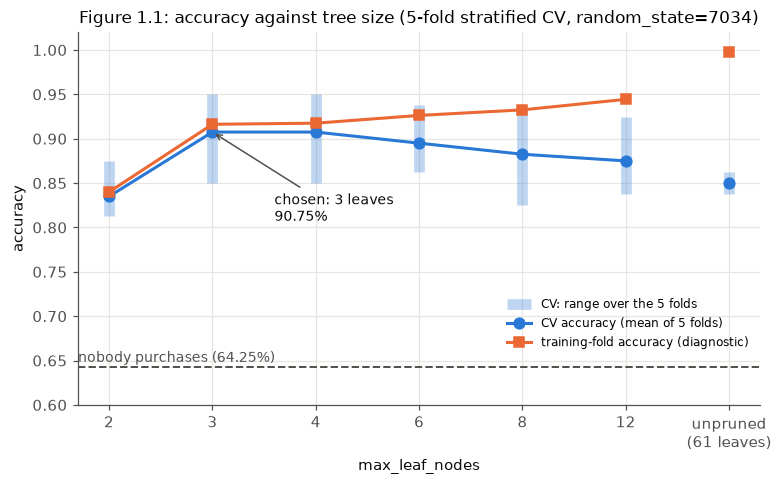

In [5]:
# Figure 1.1: CV accuracy against tree size, with the training-fold accuracy as the over-fitting diagnostic
order = [f'{k} leaves' for k in sizes] + ['unpruned']
labels = [str(k) for k in sizes] + [f'unpruned\n({full_unpruned.get_n_leaves()} leaves)']
x = np.arange(len(order))
cv_mean = tab11.loc[order, 'CV accuracy'].to_numpy()
lo, hi = tab11.loc[order, 'fold min'].to_numpy(), tab11.loc[order, 'fold max'].to_numpy()
tr = tab11.loc[order, 'training-fold accuracy (diagnostic)'].to_numpy()

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.vlines(x, lo, hi, color=C_BLUE, alpha=0.3, linewidth=7, label='CV: range over the 5 folds')
ax.plot(x[:-1], cv_mean[:-1], 'o-', color=C_BLUE, markersize=7, label='CV accuracy (mean of 5 folds)')
ax.plot(x[-1:], cv_mean[-1:], 'o', color=C_BLUE, markersize=7)
ax.plot(x[:-1], tr[:-1], 's-', color=C_ORANGE, markersize=6, label='training-fold accuracy (diagnostic)')
ax.plot(x[-1:], tr[-1:], 's', color=C_ORANGE, markersize=6)
ax.axhline(base_correct / N, color=C_GREY, linestyle='--', linewidth=1.3)
ax.text(-0.3, base_correct / N + 0.006, f'nobody purchases ({base_correct / N:.2%})', color=C_GREY, fontsize=9)
i = sizes.index(k_star)
ax.annotate(f'chosen: {k_star} leaves\n{cv_mean[i]:.2%}', xy=(x[i], cv_mean[i]), xytext=(x[i] + 0.6, cv_mean[i] - 0.1),
            color=C_INK, fontsize=9, arrowprops=dict(arrowstyle='->', color=C_GREY))
ax.set_xticks(x, labels)
ax.set_xlabel('max_leaf_nodes')
ax.set_ylabel('accuracy')
ax.set_ylim(0.6, 1.02)
ax.set_title('Figure 1.1: accuracy against tree size (5-fold stratified CV, random_state=7034)')
ax.legend(loc='lower right', bbox_to_anchor=(1, 0.12), fontsize=8)
plt.show()

**Answer:**

**The bar to beat.** The rule "nobody purchases" is right for every non-buyer: **257 of 400 = 64.25%**. On the individual folds it scores 63.75% to 65.00%, because 257 cannot be split exactly evenly into five stratified folds. Every model below has to beat 64.25% (L6 p.57: accuracy is reported "with the majority-class rate next to it").

**The unpruned tree** scores **85.00%** in 5-fold CV (340/400). That is well above the bar, but it is the worst tree in Table 1.1 except the 2-leaf stump. Grown on all 400 people it has 61 leaves and depth 14. It classifies 399 of the 400 correctly in sample (the one miss is a pair of identical people with opposite outcomes), yet only 85% of people it has not seen. It is memorising noise (L8 p.30, p.38).

**The sweep** (Table 1.1, Figure 1.1):

| `max_leaf_nodes` | 2 | 3 | 4 | 6 | 8 | 12 |
|---|---|---|---|---|---|---|
| CV accuracy | 83.50% | **90.75%** | **90.75%** | 89.50% | 88.25% | 87.50% |

**Cross-validation prefers 3 leaves.** 3 and 4 leaves tie exactly (363/400 correct), and the tie goes to the smaller tree. The tie is not a coincidence: the fourth split only divides a leaf into two leaves with the same predicted class, so the two trees make identical out-of-fold predictions for all 400 people (checked in the cell above). The choice matches Lecture 8's own tree for this dataset (L8 p.33).

**Either side of the optimum:**
- **Fewer leaves: underfitting (bias).** With 2 leaves the tree makes a single split, the Age split at the root in 1.2. It scores 83.50% in CV and 84.0% on its own training folds. Training and test accuracy are both low, so the model is too simple: it misses that younger people with high salaries buy.
- **More leaves: overfitting (variance).** From 6 to 12 leaves, CV accuracy falls from 89.50% to 87.50% while training-fold accuracy keeps rising, from 92.6% to 94.4%. The fully grown tree takes this to the extreme: 99.8% on the training folds and 85.00% out of sample. This is the hump shape of L8 p.32.

**How much to read into the gaps.** One person is 1.25 percentage points of a fold and 0.25 pp of the pooled figure. The 3-leaf tree's fold scores range from 85.0% to 95.0%, so neighbouring sizes (3 vs 6 leaves: 5 people out of 400) are within fold-to-fold noise. The 90.75% also won a search over six sizes, so it is slightly optimistic as an estimate of future accuracy (L4 p.43; L5 p.57). The preference for a small tree does not depend on this: 2 to 4 leaves carry the signal, and larger trees only add noise.

**1.2.** Plot the tree you chose in 1.1 (`plot_tree` with `feature_names=Xa.columns`), and then **say what it does in one or two English sentences** — the kind you could put in front of someone with no statistics.

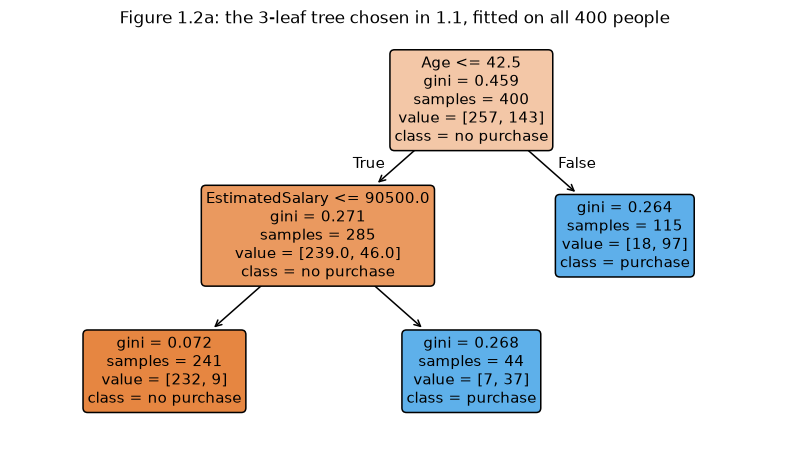

|--- Age <= 42.50
|   |--- EstimatedSalary <= 90500.00
|   |   |--- weights: [232.00, 9.00] class: 0
|   |--- EstimatedSalary >  90500.00
|   |   |--- weights: [7.00, 37.00] class: 1
|--- Age >  42.50
|   |--- weights: [18.00, 97.00] class: 1

in-sample accuracy of this tree: 91.50% (diagnostic; its honest accuracy is the CV figure)


,rule,people,buyers,purchase rate,tree predicts
leaf,,,,,
2,Age > 42.5,115,97,84%,purchase
3,Age <= 42.5 and EstimatedSalary <= 90500,241,9,4%,no purchase
4,Age <= 42.5 and EstimatedSalary > 90500,44,37,84%,purchase


Does the tree use Gender? False


In [6]:
# Refit the size CV chose on all 400 people: CV chose a size, not a particular tree (L5 p.36; L8 p.33).
tree_star = DecisionTreeClassifier(max_leaf_nodes=k_star, random_state=7034).fit(Xa, ya)

fig, ax = plt.subplots(figsize=(9, 4.8))
plot_tree(tree_star, feature_names=Xa.columns, class_names=['no purchase', 'purchase'],
          filled=True, rounded=True, impurity=True, fontsize=10, ax=ax)
ax.set_title(f'Figure 1.2a: the {k_star}-leaf tree chosen in 1.1, fitted on all {N} people')
plt.show()
print(export_text(tree_star, feature_names=list(Xa.columns), show_weights=True))
print(f'in-sample accuracy of this tree: {tree_star.score(Xa, ya):.2%} (diagnostic; its honest accuracy is the CV figure)')

def leaf_rules(tree, names):
    """The conditions that lead to each leaf, in words."""
    t, rules = tree.tree_, {}
    def walk(node, conds):
        if t.children_left[node] == -1:
            rules[node] = ' and '.join(conds) if conds else 'everyone'
            return
        f, thr = names[t.feature[node]], t.threshold[node]
        walk(t.children_left[node], conds + [f'{f} <= {thr:g}'])
        walk(t.children_right[node], conds + [f'{f} > {thr:g}'])
    walk(0, [])
    return rules

rules = leaf_rules(tree_star, list(Xa.columns))
tab12 = (pd.DataFrame({'leaf': tree_star.apply(Xa), 'bought': ya}).groupby('leaf')['bought']
           .agg(people='size', buyers='sum'))
tab12['purchase rate'] = tab12.buyers / tab12.people
tab12['tree predicts'] = np.where(tab12['purchase rate'] > 0.5, 'purchase', 'no purchase')
tab12.insert(0, 'rule', [rules[i] for i in tab12.index])
display(tab12.style.format({'purchase rate': '{:.0%}'}).set_caption('Table 1.2: the leaves of the chosen tree'))
uses_gender = 0 in set(tree_star.tree_.feature[tree_star.tree_.feature >= 0])
print('Does the tree use Gender?', uses_gender)

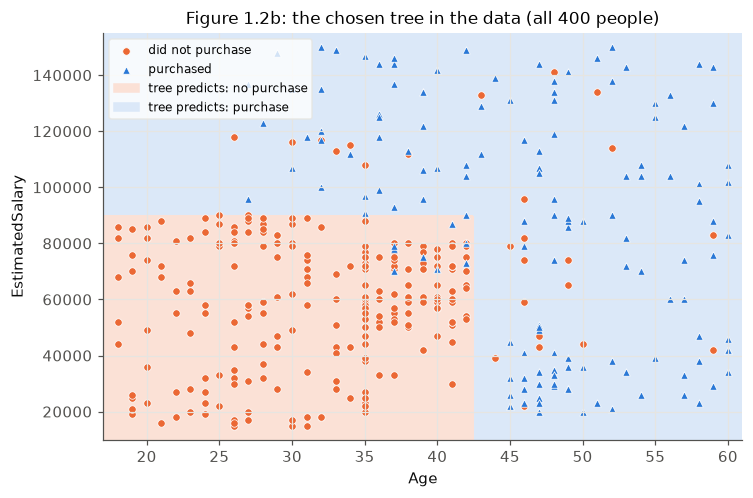

fold 1 tree splits: Age <= 44.5; EstimatedSalary <= 91500
fold 2 tree splits: Age <= 44.5; EstimatedSalary <= 89500
fold 3 tree splits: Age <= 42.5; EstimatedSalary <= 89500
fold 4 tree splits: Age <= 42.5; EstimatedSalary <= 90500
fold 5 tree splits: Age <= 42.5; EstimatedSalary <= 90500


In [7]:
# Figure 1.2b: where the tree predicts "purchase" in the Age x Salary plane (as in L8 p.34)
from matplotlib.patches import Patch
AA, SS = np.meshgrid(np.linspace(17, 61, 300), np.linspace(10_000, 155_000, 300))
genders = [0, 1] if uses_gender else [0]           # Gender only needs its own panel if the tree uses it
fig, axes = plt.subplots(1, len(genders), figsize=(7.5 * len(genders), 4.8), squeeze=False)
for ax, g in zip(axes[0], genders):
    grid = pd.DataFrame({'Gender': g, 'Age': AA.ravel(), 'EstimatedSalary': SS.ravel()})[Xa.columns]
    Z = tree_star.predict(grid).reshape(AA.shape)
    ax.contourf(AA, SS, Z, levels=[-0.5, 0.5, 1.5], colors=['#fbe1d6', '#dbe8f8'])   # same colours as plot_tree
    pts = ads if not uses_gender else ads[ads.Gender == g]
    for val, col, mk, lab in [(0, C_ORANGE, 'o', 'did not purchase'), (1, C_BLUE, '^', 'purchased')]:
        s = pts[pts.Purchased == val]
        ax.scatter(s.Age, s.EstimatedSalary, s=24, c=col, marker=mk, edgecolors='white', linewidths=0.5, label=lab)
    handles = ax.get_legend_handles_labels()[0] + [Patch(color='#fbe1d6', label='tree predicts: no purchase'),
                                                  Patch(color='#dbe8f8', label='tree predicts: purchase')]
    ax.legend(handles=handles, loc='upper left', fontsize=8, frameon=True, facecolor='white', edgecolor=C_LIGHT)
    ax.set_xlabel('Age')
    ax.set_ylabel('EstimatedSalary')
    ax.set_title('Figure 1.2b: the chosen tree in the data' + (f' (Gender = {g})' if uses_gender else ' (all 400 people)'))
plt.show()

# How stable is the structure? The same size fitted on each CV training fold (320 people each; L8 p.40).
folds_fit = cross_validate(DecisionTreeClassifier(max_leaf_nodes=k_star, random_state=7034), Xa, ya,
                           cv=cv5, return_estimator=True)['estimator']
for i, est in enumerate(folds_fit, 1):
    t = est.tree_
    print(f'fold {i} tree splits:', '; '.join(f'{Xa.columns[t.feature[n]]} <= {t.threshold[n]:g}'
                                              for n in range(t.node_count) if t.feature[n] >= 0))

**Answer:**

People over 42 mostly bought (97 of 115, about 84 in every 100), and so did people aged 42 or younger earning more than $90,000 (37 of 44, again about 84 in 100), while younger people earning $90,000 or less almost never bought (9 of 241, about 4 in 100). Gender plays no part in the rule.

*Technical note (outside the two sentences).*
- The tree is refit on all 400 people at the size chosen in 1.1, because cross-validation chooses a size, not a particular tree (L5 p.36, as in L8 p.33).
- Its honest accuracy is the 5-fold figure from 1.1, 90.75%, not the 91.5% it scores on the people it was fitted to.
- It is the same tree as L8 p.33, split by split.
- It is stable: the five trees fitted on the CV training folds all split on Age and then Salary, with age thresholds between 42.5 and 44.5 and salary thresholds between $89,500 and $91,500.

**1.3.** Fit a random forest (300 trees) and a gradient boosted model (100 rounds), both with `random_state=7034`, and report their 5-fold accuracies.

Do they beat the tree from 1.1? Report what you find **whichever way it comes out**, and explain in two or three sentences why that might be, given the size and shape of this dataset.

In [8]:
rf = RandomForestClassifier(n_estimators=300, random_state=7034)
gb = GradientBoostingClassifier(n_estimators=100, random_state=7034)
tab13 = pd.concat([tab11.loc[['unpruned', f'{k_star} leaves']],
                   pd.DataFrame([cv_detail(rf, 'random forest (300 trees)'),
                                 cv_detail(gb, 'gradient boosting (100 rounds)')]).set_index('model')])

# Head to head with the chosen tree on the same 5 folds (people correct per fold of 80)
tree_folds = tab11.loc[f'{k_star} leaves', 'folds']
tab13['vs chosen tree (people /400)'] = tab13['correct /400'] - tab11.loc[f'{k_star} leaves', 'correct /400']
tab13['folds better / equal / worse than tree'] = [
    f'{(f > tree_folds).sum()} / {(f == tree_folds).sum()} / {(f < tree_folds).sum()}' for f in tab13['folds']]
tab13['people correct per fold (of 80)'] = [' '.join(map(str, f)) for f in tab13['folds']]
pct = ['CV accuracy', 'fold min', 'fold max', 'training-fold accuracy (diagnostic)']
display(tab13.drop(columns='folds').style.format({**{c: '{:.2%}' for c in pct}, 'fold sd': '{:.3f}'})
        .set_caption(f'Table 1.3: ensembles against the {k_star}-leaf tree (same 5 folds; baseline {base_correct / N:.2%})'))

# The settings actually used (the exam fixes 300 trees / 100 rounds; everything else is the sklearn default)
rf_full = RandomForestClassifier(n_estimators=300, random_state=7034).fit(Xa, ya)
print('RF:', {k: rf.get_params()[k] for k in ['n_estimators', 'max_features', 'max_depth', 'min_samples_leaf', 'bootstrap']},
      '| features tried at each split:', rf_full.estimators_[0].max_features_,
      '| mean leaves per tree:', round(np.mean([t.get_n_leaves() for t in rf_full.estimators_]), 1))
print('GB:', {k: gb.get_params()[k] for k in ['n_estimators', 'learning_rate', 'max_depth', 'subsample']})

,CV accuracy,correct /400,fold min,fold max,fold sd,training-fold accuracy (diagnostic),vs chosen tree (people /400),folds better / equal / worse than tree,people correct per fold (of 80)
model,,,,,,,,,
unpruned,85.00%,340,83.75%,86.25%,0.013,99.81%,-23,0 / 0 / 5,67 68 69 67 69
3 leaves,90.75%,363,85.00%,95.00%,0.037,91.63%,0,0 / 5 / 0,68 72 73 74 76
random forest (300 trees),88.75%,355,85.00%,92.50%,0.032,99.81%,-8,2 / 0 / 3,69 73 71 68 74
gradient boosting (100 rounds),89.00%,356,83.75%,93.75%,0.040,97.44%,-7,1 / 2 / 2,69 72 73 67 75


RF: {'n_estimators': 300, 'max_features': 'sqrt', 'max_depth': None, 'min_samples_leaf': 1, 'bootstrap': True} | features tried at each split: 1 | mean leaves per tree: 50.2
GB: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 1.0}


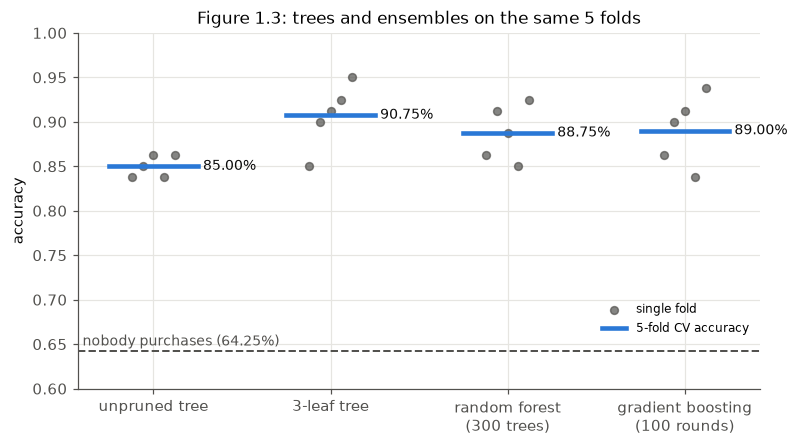

In [9]:
# Figure 1.3: the five fold scores and their mean for each model, against the baseline
models = ['unpruned', f'{k_star} leaves', 'random forest (300 trees)', 'gradient boosting (100 rounds)']
fig, ax = plt.subplots(figsize=(8, 4.2))
for j, m in enumerate(models):
    f = tab13.loc[m, 'folds'] / 80
    ax.scatter(np.full(5, j) + np.linspace(-0.12, 0.12, 5), f, s=26, color=C_GREY, alpha=0.7,
               label='single fold' if j == 0 else None, zorder=2)
    ax.plot([j - 0.25, j + 0.25], [tab13.loc[m, 'CV accuracy']] * 2, color=C_BLUE, linewidth=3,
            label='5-fold CV accuracy' if j == 0 else None, zorder=3)
    ax.text(j + 0.28, tab13.loc[m, 'CV accuracy'], f"{tab13.loc[m, 'CV accuracy']:.2%}", va='center', fontsize=9, color=C_INK)
ax.axhline(base_correct / N, color=C_GREY, linestyle='--', linewidth=1.3)
ax.text(-0.4, base_correct / N + 0.006, f'nobody purchases ({base_correct / N:.2%})', color=C_GREY, fontsize=9)
ax.set_xticks(range(len(models)), ['unpruned tree', f'{k_star}-leaf tree', 'random forest\n(300 trees)',
                                   'gradient boosting\n(100 rounds)'])
ax.set_ylabel('accuracy')
ax.set_ylim(0.6, 1.0)
ax.set_title('Figure 1.3: trees and ensembles on the same 5 folds')
ax.legend(loc='lower right', bbox_to_anchor=(1, 0.12), fontsize=8)
plt.show()

**Answer:**

**Results (Table 1.3, Figure 1.3, same five folds as 1.1):**

| model | 5-fold CV accuracy | people correct /400 |
|---|---|---|
| nobody purchases | 64.25% | 257 |
| unpruned tree | 85.00% | 340 |
| **3-leaf tree (from 1.1)** | **90.75%** | **363** |
| random forest, 300 trees | 88.75% | 355 |
| gradient boosting, 100 rounds | 89.00% | 356 |

**Neither ensemble beats the 3-leaf tree.** Both are far above the 64.25% bar and above the unpruned tree, but they get 8 (forest) and 7 (boosting) fewer people right than the 3-leaf tree. Fold by fold the verdict is mixed: the forest beats the tree in 2 folds and loses in 3; boosting beats it in 1, ties in 2 and loses in 2. The fair reading is therefore "no better than the small tree", not "worse", because the gaps are inside the tree's own fold-to-fold range of 85% to 95%.

**Why:** With 400 people and effectively two inputs that matter, the buying pattern is close to one rectangle in the Age × Salary plane (Figure 1.2b), which a 3-leaf tree already draws, so there is little left for an ensemble to fix: a forest averages away *variance* and boosting adds shallow trees to remove *bias* (L8 p.51), and the small tree has little of either. What the ensembles add instead is flexibility to chase noise in 320-person training folds (training-fold accuracy 99.8% for the forest and 97.4% for boosting, against 91.6% for the tree), and both run at untuned settings (the forest tries one of the three features at each split; boosting uses learning rate 0.1, depth 3), so on data this small and this simple the readable tree is the better choice (L8 p.54–55, p.61).

**1.4.** Split the data 70/30 (`random_state=7034`, `stratify=ya`), fit a 300-tree forest on the training set, and compute two importance rankings: `feature_importances_` (mean decrease in impurity, computed **in sample**) and `permutation_importance` on the **held-out** 30%.

Put them side by side. Do the two rankings agree on which variable matters most? Where they disagree, explain why — and say which of the two you would show to someone making a decision.

In [10]:
X_tr, X_te, y_tr, y_te = train_test_split(Xa, ya, test_size=0.3, random_state=7034, stratify=ya)
print(f'training: {len(X_tr)} people ({int(y_tr.sum())} buyers); held out: {len(X_te)} people ({int(y_te.sum())} buyers)')
rf14 = RandomForestClassifier(n_estimators=300, random_state=7034).fit(X_tr, y_tr)
print(f'Diagnostics only (the reported RF accuracy is the 5-fold figure in 1.3): training accuracy '
      f'{rf14.score(X_tr, y_tr):.3f}, held-out accuracy {rf14.score(X_te, y_te):.3f}, '
      f'held-out "nobody purchases" {(y_te == 0).mean():.3f}; mean leaves per tree '
      f'{np.mean([t.get_n_leaves() for t in rf14.estimators_]):.1f}')

mdi = pd.Series(rf14.feature_importances_, index=Xa.columns)     # mean decrease in impurity, in sample (L8 p.47, p.56)
pi_te = permutation_importance(rf14, X_te, y_te, scoring='accuracy', n_repeats=50, random_state=7034)  # held out (L8 p.57)
pi_tr = permutation_importance(rf14, X_tr, y_tr, scoring='accuracy', n_repeats=50, random_state=7034)  # diagnostic
perm = pd.Series(pi_te.importances_mean, index=Xa.columns)
splits = pd.Series([sum(int((t.tree_.feature == j).sum()) for t in rf14.estimators_) for j in range(Xa.shape[1])],
                   index=Xa.columns)
tab14 = pd.DataFrame({
    'MDI share (in-sample)': mdi,
    'MDI rank': mdi.rank(ascending=False, method='min').astype(int),
    'held-out accuracy drop (pp)': 100 * perm,
    'sd over 50 shuffles (pp)': 100 * pd.Series(pi_te.importances_std, index=Xa.columns),
    'permutation share': perm.clip(lower=0) / perm.clip(lower=0).sum(),   # negative drops set to 0 before normalising
    'permutation rank': perm.rank(ascending=False, method='min').astype(int),
    'diagnostic: drop on training rows (pp)': 100 * pd.Series(pi_tr.importances_mean, index=Xa.columns),
    'splits in the forest': splits,
    'distinct values': Xa.nunique()}).sort_values('permutation rank')
assert np.isclose(mdi.sum(), 1) and pi_te.importances.shape == (3, 50)
display(tab14.style.format({'MDI share (in-sample)': '{:.3f}', 'permutation share': '{:.3f}',
                            'held-out accuracy drop (pp)': '{:.2f}', 'sd over 50 shuffles (pp)': '{:.2f}',
                            'diagnostic: drop on training rows (pp)': '{:.2f}'})
        .set_caption('Table 1.4: two importance rankings for the same 300-tree forest'))
print(f'corr(Age, EstimatedSalary) = {Xa.Age.corr(Xa.EstimatedSalary):.3f}')

training: 280 people (100 buyers); held out: 120 people (43 buyers)


Diagnostics only (the reported RF accuracy is the 5-fold figure in 1.3): training accuracy 0.996, held-out accuracy 0.917, held-out "nobody purchases" 0.642; mean leaves per tree 38.2


,MDI share (in-sample),MDI rank,held-out accuracy drop (pp),sd over 50 shuffles (pp),permutation share,permutation rank,diagnostic: drop on training rows (pp),splits in the forest,distinct values
Age,0.470,2,25.50,3.66,0.569,1,26.96,4751,43
EstimatedSalary,0.519,1,17.13,2.95,0.382,2,28.83,5623,117
Gender,0.011,3,2.18,1.21,0.049,3,5.03,776,2


corr(Age, EstimatedSalary) = 0.155


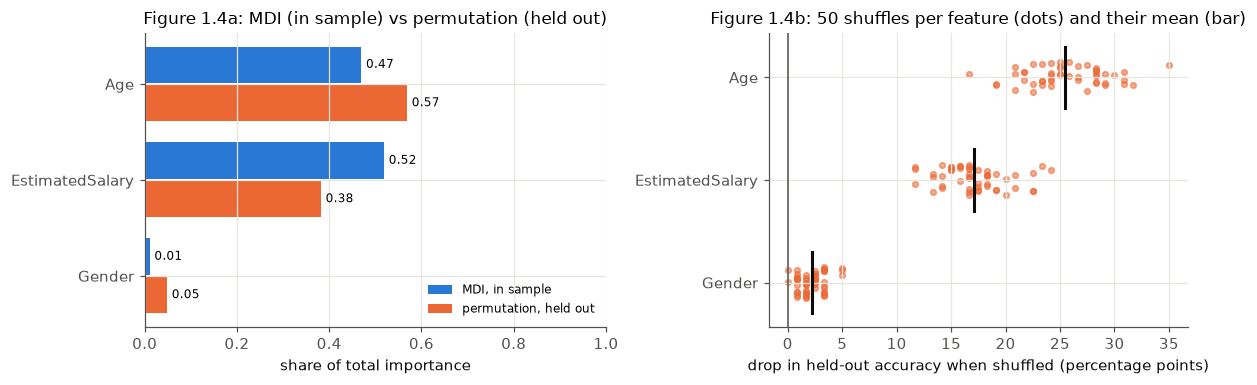

In [11]:
# Figure 1.4: the two rankings side by side (left) and the spread of the 50 held-out shuffles (right)
feats = list(tab14.index)[::-1]                      # most important (by permutation) at the top
yy = np.arange(len(feats))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={'width_ratios': [1.1, 1]})
ax1.barh(yy + 0.2, tab14.loc[feats, 'MDI share (in-sample)'], height=0.38, color=C_BLUE, label='MDI, in sample')
ax1.barh(yy - 0.2, tab14.loc[feats, 'permutation share'], height=0.38, color=C_ORANGE, label='permutation, held out')
for k, f in enumerate(feats):
    ax1.text(tab14.loc[f, 'MDI share (in-sample)'] + 0.01, k + 0.2, f"{tab14.loc[f, 'MDI share (in-sample)']:.2f}", va='center', fontsize=8)
    ax1.text(tab14.loc[f, 'permutation share'] + 0.01, k - 0.2, f"{tab14.loc[f, 'permutation share']:.2f}", va='center', fontsize=8)
ax1.set_yticks(yy, feats)
ax1.set_xlabel('share of total importance')
ax1.set_xlim(0, 1)
ax1.legend(loc='lower right', fontsize=8)
ax1.set_title('Figure 1.4a: MDI (in sample) vs permutation (held out)')
rng_jit = np.random.default_rng(7034)                  # vertical jitter only, so the dots do not sit on top of each other
for k, f in enumerate(feats):
    drops = 100 * pi_te.importances[list(Xa.columns).index(f)]
    ax2.scatter(drops, k + rng_jit.uniform(-0.15, 0.15, drops.size), s=14, color=C_ORANGE, alpha=0.55)
    ax2.plot([drops.mean()] * 2, [k - 0.3, k + 0.3], color=C_INK, linewidth=2)
ax2.set_yticks(yy, feats)
ax2.axvline(0, color=C_GREY, linewidth=1)
ax2.set_xlabel('drop in held-out accuracy when shuffled (percentage points)')
ax2.set_title('Figure 1.4b: 50 shuffles per feature (dots) and their mean (bar)')
plt.tight_layout()
plt.show()

**Answer:**

**Setup.** The data are split 70/30, stratified, with `random_state=7034`: 280 people for training (100 buyers) and 120 held out (43 buyers). The forest has 300 trees. Its held-out accuracy of 91.7% is shown only as a diagnostic; the forest's reported accuracy is the 5-fold 88.75% from 1.3.

**Side by side (Table 1.4, Figure 1.4):**

| feature | MDI share, in sample | MDI rank | held-out permutation: accuracy drop (sd over 50 shuffles) | permutation rank |
|---|---|---|---|---|
| Age | 0.470 | 2 | **25.5 pp** (3.7) | **1** |
| EstimatedSalary | **0.519** | **1** | 17.1 pp (3.0) | 2 |
| Gender | 0.011 | 3 | 2.2 pp (1.2) | 3 |

**Do they agree on the most important variable? No.** MDI puts Salary first; held-out permutation puts Age first. They agree that Gender matters least.

**Why they disagree:**
- **MDI is computed in sample** (L8 p.47, p.56). It adds up the impurity reduction of every split the forest makes on its own training rows. These trees are grown deep (about 38 leaves each, 99.6% training accuracy), so many splits fit noise, and each of those splits is credited to some variable.
- **Salary offers the most places to split.** It has 117 distinct values against 43 for Age and 2 for Gender, so the forest splits on it 5,623 times against 4,751 for Age. The noise-fitting splits pile up credit for Salary. L8 p.58 describes exactly this: MDI "rewards a column for merely offering many places to split".
- **The diagnostic column confirms the mechanism.** Permutation importance computed on the *training* rows also ranks Salary above Age (28.8 vs 27.0 pp). On people it has memorised, the forest leans on Salary. On people it has not seen, removing Age costs more.
- **Shared credit between correlated inputs** is L8 p.58's other mechanism, but it is not the main story here: Age and Salary are only weakly correlated (0.155).

**What I would show a decision maker: the held-out permutation ranking.** It measures how much accuracy on new people is lost when a variable's information is destroyed, which is the question the decision maker is actually asking (L8 p.57: it "answers the question you actually asked"). Three caveats come with it:
- It rests on 120 people. The shuffles alone move it by ±3 to 4 pp, and a different split would move it more.
- Importance has no sign (L8 p.60). The direction comes from 1.2: older people, and younger people with high salaries, are the likely buyers.
- It describes what the model uses, not a causal effect.

**1.5** (Open-Ended) Each row here is a *person*, and the rows are unrelated to each other. Suppose instead each row were a *month* of one stock's data, and you were predicting whether next month's return is positive.

Cross-validation with `shuffle=True` — which you used throughout this problem — would then be **wrong**. Explain precisely what goes wrong, what you would do instead, and which way the error would push your reported accuracy.

In [12]:
# No code is needed for 1.5: the answer below is conceptual (the exam asks for code only "if any").

**Answer:**

**What goes wrong.** Shuffled K-fold assumes the rows are exchangeable draws, like unrelated people (L5 p.28; L8 p.45). Months of one stock are not.
1. **The future leaks into training (look-ahead).** `StratifiedKFold(shuffle=True)` assigns months to folds at random. So the model that is scored on, say, 2015 has been trained on 2016–2021, information no forecaster ever has. "The random fold sees the future" (L5 p.56); "watch whether the future ends up in the training set. It usually does" (L1 p.82).
2. **Neighbouring months are near-duplicates.** Predictors built from trailing windows barely change from one month to the next (a 12-month past return shares 11 of its 12 months with the next row's), and calm and turbulent periods persist. Each test month therefore has its almost identical neighbours in the training folds, and a tree can look up their answers rather than forecast. This mechanism is our own reasoning; the course's rule is simply that "the order of data is respected" (L5 p.27) and that "CV is not valid with time-series data" (L5 p.48).
3. **The model is then tuned to the leak.** Validation looks too good for complex settings, so CV picks too big a tree. In the lecture's own experiment, random folds on time-ordered data under-regularised (23 variables instead of 15) and cost 0.036 of out-of-sample R² (L5 p.56).
4. **Two tempting fixes do not help.**
   - Dropping `shuffle` alone does not fix it: `KFold(shuffle=False)` still trains the early folds on later data.
   - Stratifying makes it slightly worse: it builds every fold with the full-period share of up months, which is itself only known at the end.

**Which way the error goes.** The reported accuracy is **biased upward**, i.e. too optimistic in expectation: every leak adds information a real forecaster would not have. The course grades this as a fatal error (L5 p.58, item 3; AI guide §4a). Monthly return signs carry little signal (L1 p.33), so an honest accuracy close to the "always up" base rate is normal. A much higher number is a prompt "to go looking for the leak" (L5 p.57).

**What to do instead: time-ordered, walk-forward evaluation** (L5 p.48–52; L6 p.30, "as it would be if the model were put to use").
- **Build predictors from information known by the end of month t−1** and lag them. Fit any scaler or imputer inside each training window only.
- **Use an expanding window.** Train on months 1…t. Choose `max_leaf_nodes` on the *following* validation block. Predict the next test block. Roll forward and pool the test predictions (a rolling window of fixed length is the alternative if the stock's behaviour drifts).
- **Keep a final test period untouched** until the model is chosen, and touch it once (L4 p.43; L8 p.55).
- **Report the accuracy next to a benchmark fixed in advance:** the majority direction ("always up") learned from the training months only, never from the test period (L6 p.57; L4 p.46).

---
# Problem 2: Training on Your Own Output (20 points)

A risk desk estimates the daily volatility of its portfolio from a library of past daily returns
and reports the one-day 1% Value-at-Risk. Under a fitted normal distribution $N(0, \hat\sigma^2)$
the 1% quantile is $-2.326\,\hat\sigma$, so the desk reports $\text{VaR} = 2.326\,\hat\sigma$: under
this model, estimating VaR *is* estimating $\hat\sigma$. In 2016 the desk decided that the library
should be refreshed every night so that it always reflects the newest model. Its pipeline manual:

> *Every night the pipeline **(1)** fits $\hat\sigma^2$ to the library with the usual unbiased sample
> variance, $\hat\sigma^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar x)^2$, and sets the mean of the
> fitted normal to zero; **(2)** draws 500 fresh scenarios from $N(0, \hat\sigma^2)$; **(3)** replaces
> the library with tonight's 500 scenarios, so the library keeps its size, because the newest model is the best model and
> yesterday's data came from a worse one; and **(4)** reports $\text{VaR} = 2.326\,\hat\sigma$.*

On the first night the library held 500 real daily returns. The pipeline then ran every night for
ten years, 2,500 refits in all, and the reported VaR fell from 2.8% of NAV to 0.24%, while the
volatility of the desk's markets had not changed. The desk was praised for de-risking. The Chief Risk Officer, who does not
believe in free lunches, wants to know what happened.

**Rules.** Work in units of the true volatility: $\sigma = 1$, so the *correct* VaR is $2.326$ on
every night and nothing about the market changes. Set `SEED` to the last four digits of your student ID; your numbers will differ from your classmates', and that is the point. A "desk" is one run of the
pipeline; every desk starts on night 1 from a library whose sample variance is exactly 1, and when a
part needs the real days themselves, take them to be 500 draws from $N(0, 1)$. Every number you
report must come from a cell in this notebook.


In [13]:
from scipy.stats import norm, kurtosis
import time

_DATA_DIR = '/classes/41210_MiF_fall2026/Data/'
import os
_DATA_DIR = _DATA_DIR if os.path.isdir(_DATA_DIR) else './'   # class server if present, else a local copy next to the notebook

SEED   = 2694          # <-- the last four digits of your student ID
N_SCEN = 500           # scenarios drawn per night
NIGHTS = 2500          # ten trading years
Z01    = norm.ppf(0.99)   # 2.326: the 1% one-day VaR of N(0, 1), in units of sigma
print(f"correct VaR, every night, in units of sigma: {Z01:.3f}")

correct VaR, every night, in units of sigma: 2.326


**2.1.** (2 points) **Commit before you compute.** Answer in the markdown cell below *before*
writing any code. The estimator in step (1) is unbiased, so each night's estimate is, on average,
equal to the previous night's. Does that mean the reported VaR should stay near 2.326 for ten
years? Say what you expect to see on night 2,500 and why, in two or three sentences. No marks depend
on being right; **2.3** asks you to reconcile your answer with what you find.


**Answer:** In levels, sample variance $s^2$ is an unbiased estimator of population variance ($E[s_{t+1}^2 \mid s_t^2] = s_t^2$), so the desk average across 1,000 independent banks should remain approximately 1.0. However, because the log function is strictly concave, **Jensen's Inequality** implies that $E[\ln s_{t+1}^2 \mid s_t^2] < \ln E[s_{t+1}^2 \mid s_t^2] = \ln s_t^2$. Therefore, over 2,500 nights of sequential refitting on synthetic draws, the **median** variance and the trajectory of an individual desk will experience a systematic negative drift (proportional to $-1/(n-1)$), leading to a collapse in estimated volatility and a severe underestimation of VaR.


**2.2.** (6 points) **One desk, then a thousand.** Simulate one desk for 2,500 nights exactly as
the manual describes: fit $\hat\sigma^2$ with `var(ddof=1)`, draw 500 scenarios from
$N(0, \hat\sigma^2)$, replace the library. Plot $\log\hat\sigma^2$ against the night and report
$\hat\sigma^2$ and the reported VaR on night 2,500.

Then run a thousand desks (a loop over nights that draws a $1000 \times 500$ matrix each night takes
seconds). For night 2,500 report the mean, median, 5th and 95th percentiles and maximum of
$\hat\sigma^2$, and the fraction of desks reporting a VaR below one-tenth of the truth. Where does
your one desk sit in that distribution? Is the story's fall from 2.8% to 0.24% typical?


one desk, night 2500: sigma2-hat = 1.405e-05, reported VaR = 0.0087 sigma (truth 2.326), i.e. 0.010% of NAV on the story's scale


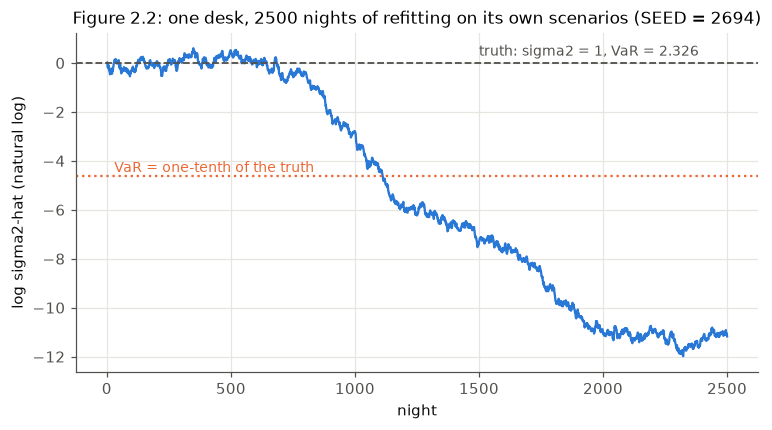

In [14]:
import scipy.stats as stats

N_DESKS = 1000
STORY_VAR_START, STORY_VAR_END = 2.8, 0.24          # % of NAV, from the story

# One master seed, named independent streams: re-running any cell reproduces its numbers,
# and adding a stream at the end never changes the others.
STREAMS = ['one_desk', 'desks_1000', 'mart_s0_1', 'mart_s0_one', 'drift_50', 'drift_500', 'drift_5000',
           'drift_50_precise', 'mixed_real', 'mixed_synth', 'dj_scen', 'kurt_null', 'dj_boot']
_SS = dict(zip(STREAMS, np.random.SeedSequence(SEED).spawn(len(STREAMS))))
def rng_for(name):
    """A fresh generator on a named stream (the same numbers every time the cell is run)."""
    return np.random.default_rng(_SS[name])

def run_desks(n_desks, n_scen, nights, rng, s2_night1=1.0):
    """The manual's pipeline for many desks at once. Row k of the result is log sigma2-hat on night k+1.
    Night 1 fits the real library (sample variance s2_night1); every later night fits the previous night's scenarios."""
    log_s2 = np.empty((nights, n_desks))
    s2 = np.full(n_desks, float(s2_night1))
    log_s2[0] = np.log(s2)
    for k in range(1, nights):
        scen = rng.standard_normal((n_desks, n_scen)) * np.sqrt(s2)[:, None]   # (2) draw from N(0, s2): the scale is the SD
        s2 = scen.var(axis=1, ddof=1)                                          # (3) replace the library, (1) refit next night
        log_s2[k] = np.log(s2)
    return log_s2

# --- One desk, exactly as the manual reads ---
rng = rng_for('one_desk')
s2_one = np.empty(NIGHTS)
s2_one[0] = 1.0                                       # night 1: the real library has sample variance exactly 1
for k in range(1, NIGHTS):
    library = rng.normal(0.0, np.sqrt(s2_one[k - 1]), N_SCEN)   # (2) 500 scenarios from N(0, last fit); (3) they replace the library
    s2_one[k] = library.var(ddof=1)                             # (1) tonight's unbiased fit
var_one = Z01 * np.sqrt(s2_one)                                 # (4) reported VaR, in units of sigma

# the vectorised pipeline used below must reproduce this literal loop
assert np.allclose(np.log(s2_one), run_desks(1, N_SCEN, NIGHTS, rng_for('one_desk'))[:, 0], rtol=0, atol=1e-10)
print(f'one desk, night {NIGHTS}: sigma2-hat = {s2_one[-1]:.4g}, reported VaR = {var_one[-1]:.4f} sigma '
      f'(truth {Z01:.3f}), i.e. {STORY_VAR_START * np.sqrt(s2_one[-1]):.3f}% of NAV on the story\'s scale')

fig, ax = plt.subplots(figsize=(8, 4))
nights = np.arange(1, NIGHTS + 1)
ax.plot(nights, np.log(s2_one), color=C_BLUE, linewidth=1.5)
ax.axhline(0, color=C_GREY, linestyle='--', linewidth=1.2)
ax.text(1500, 0.3, 'truth: sigma2 = 1, VaR = 2.326', color=C_GREY, fontsize=9)
ax.axhline(np.log(0.01), color=C_ORANGE, linestyle=':', linewidth=1.5)
ax.text(30, np.log(0.01) + 0.15, 'VaR = one-tenth of the truth', color=C_ORANGE, fontsize=9)
ax.set_xlabel('night')
ax.set_ylabel('log sigma2-hat (natural log)')
ax.set_title(f'Figure 2.2: one desk, {NIGHTS} nights of refitting on its own scenarios (SEED = {SEED})')
plt.show()

In [15]:
t0 = time.perf_counter()
logS2 = run_desks(N_DESKS, N_SCEN, NIGHTS, rng_for('desks_1000'))     # (2500, 1000): every desk, every night
print(f'1,000 desks x {NIGHTS} nights simulated in {time.perf_counter() - t0:.1f} s')
assert logS2.shape == (NIGHTS, N_DESKS) and np.all(logS2[0] == 0) and np.isfinite(logS2).all()

S2_T = np.exp(logS2[-1])                                               # sigma2-hat on night 2,500, one per desk
low = (S2_T < 0.01).astype(float)                                       # VaR < truth/10  <=>  sigma-hat < 0.1
q5, q50, q95 = np.percentile(S2_T, [5, 50, 95])
tab22 = pd.DataFrame({'sigma2-hat': [S2_T.mean(), q50, q5, q95, S2_T.max()]},
                     index=['mean', 'median', '5th percentile', '95th percentile', 'maximum'])
tab22['reported VaR (sigma units)'] = Z01 * np.sqrt(tab22['sigma2-hat'])
tab22['VaR, % of NAV on the story scale'] = STORY_VAR_START * np.sqrt(tab22['sigma2-hat'])
display(tab22.style.format('{:.4g}').set_caption(f'Table 2.2: night {NIGHTS} across {N_DESKS} desks'))
print(f'desks reporting VaR below one-tenth of the truth: {low.mean():.1%} '
      f'(Monte-Carlo SE {low.std(ddof=1) / np.sqrt(N_DESKS):.1%})')

pct_one = (S2_T < s2_one[-1]).mean()
story_s2 = (STORY_VAR_END / STORY_VAR_START) ** 2                        # VaR is proportional to sigma-hat
band = [(0.235 / 2.85) ** 2, (0.245 / 2.75) ** 2]                        # the story's numbers, allowing for rounding
print(f'the one desk (sigma2-hat {s2_one[-1]:.4g}) sits at percentile {pct_one:.1%} of the 1,000 desks')
print(f"the story's fall 2.8% -> 0.24% means sigma2-hat = {story_s2:.4f}: percentile {(S2_T < story_s2).mean():.1%} "
      f"(rounding band {(S2_T < band[0]).mean():.1%} to {(S2_T < band[1]).mean():.1%}); "
      f'the median desk reports {STORY_VAR_START * np.sqrt(q50):.3f}% of NAV')

1,000 desks x 2500 nights simulated in 27.0 s


,sigma2-hat,reported VaR (sigma units),"VaR, % of NAV on the story scale"
mean,2.344,3.561,4.286
median,0.005851,0.1779,0.2142
5th percentile,2.885e-05,0.0125,0.01504
95th percentile,1.225,2.575,3.099
maximum,1566,92.05,110.8


desks reporting VaR below one-tenth of the truth: 57.8% (Monte-Carlo SE 1.6%)
the one desk (sigma2-hat 1.405e-05) sits at percentile 3.2% of the 1,000 desks
the story's fall 2.8% -> 0.24% means sigma2-hat = 0.0073: percentile 52.7% (rounding band 51.5% to 53.3%); the median desk reports 0.214% of NAV


**Answer:** (`SEED = 2694`. Night 1 fits the real library, whose sample variance is exactly 1, so night 2,500 is 2,499 draw-and-refit steps later.)

**One desk (Figure 2.2).**
- Its $\log\hat\sigma^2$ wanders near 0 for the first few hundred nights, then slides down.
- On night 2,500, $\hat\sigma^2$ = **1.405 × 10⁻⁵**, so the reported VaR is **0.0087σ** against a true 2.326σ.
- On the story's scale that is 0.010% of NAV instead of 2.8%.

**A thousand desks, night 2,500 (Table 2.2):**

| $\hat\sigma^2$ | mean | median | 5th pct | 95th pct | max |
|---|---|---|---|---|---|
| value | 2.344 | 0.00585 | 0.000029 | 1.225 | 1,566 |
| reported VaR (σ units) | 3.56 | 0.178 | 0.0125 | 2.58 | 92.1 |

**57.8%** of the desks (Monte-Carlo SE 1.6%) report a VaR below one-tenth of the truth.

**Where the one desk sits.** Its $\hat\sigma^2$ is at the **3.2nd percentile**: an unlucky desk far in the left tail, not a typical one.

**Is the story typical? Yes.**
- The fall from 2.8% to 0.24% of NAV corresponds to $\hat\sigma^2 = (0.24/2.8)^2 = 0.0073$.
- That sits at the **52.7th percentile** of the 1,000 desks (51.5% to 53.3% allowing for rounding in the story's numbers).
- The median desk reports 0.214% of NAV.
- The desk in the story is essentially the median outcome of this pipeline, not bad luck. The same drop happens with an unchanged market and a correct estimator at every step.

**2.3.** (6 points) **Unbiased every night, wrong in the end.** Verify in a cell that
$E[\hat\sigma^2_{t+1} \mid \hat\sigma^2_t] = \hat\sigma^2_t$: start many desks at the same
$\hat\sigma^2_t$, take one step of the pipeline, and average. So the mathematically expected value
of $\hat\sigma^2$ on night 2,500 is exactly 1. Then measure the *average nightly change in
$\log\hat\sigma^2$* for $n = 50$, $500$ and $5{,}000$ scenarios per night (a few hundred desks and a
few hundred nights are enough) and propose the formula relating it to $n$; it is simple. Plot the
histogram of $\log\hat\sigma^2$ across your thousand desks on night 2,500.

In one paragraph, reconcile three numbers that are all correct: the expectation is exactly 1, your
median is far below 1, and your thousand-desk mean is neither (what share of the sum of your
thousand estimates is held by the ten largest?). Why does "unbiased at every step" not protect a
pipeline that trains on its own output?


In [16]:
# E[sigma2_{t+1} | sigma2_t] = sigma2_t: start many desks at the same sigma2_t, take one step, average.
# Reporting rule fixed before running: "consistent with 1" if the 95% CI of the mean ratio contains 1.
# Even when the property holds exactly, each CI misses 1 about 5% of the time.
def one_step(s0, n_scen, m, rng, chunk=10_000):
    """m desks all starting at sigma2 = s0; one pipeline step; returns the m new fits."""
    out = np.empty(m)
    for i in range(0, m, chunk):
        c = min(chunk, m - i)
        out[i:i + c] = (rng.standard_normal((c, n_scen)) * np.sqrt(s0)).var(axis=1, ddof=1)
    return out

M = 200_000
rows = []
for stream, s0, label in [('mart_s0_1', 1.0, 'sigma2_t = 1 (night 1)'),
                          ('mart_s0_one', s2_one[-1], f'sigma2_t = {s2_one[-1]:.4g} (the one desk, night {NIGHTS})')]:
    ratio = one_step(s0, N_SCEN, M, rng_for(stream)) / s0
    se = ratio.std(ddof=1) / np.sqrt(M)
    tc = stats.t.ppf(0.975, M - 1)
    lr = np.log(ratio)
    rows.append({'start': label, 'mean of sigma2_{t+1}/sigma2_t': ratio.mean(), 'SE': se,
                 '95% CI low': ratio.mean() - tc * se, '95% CI high': ratio.mean() + tc * se,
                 'CI contains 1': (ratio.mean() - tc * se <= 1 <= ratio.mean() + tc * se),
                 't vs 1': (ratio.mean() - 1) / se, 'two-sided p': 2 * stats.t.sf(abs(ratio.mean() - 1) / se, M - 1),
                 'median ratio': np.median(ratio), 'share of desks that go down': (ratio < 1).mean(),
                 'mean log ratio': lr.mean(), 'SE of mean log ratio': lr.std(ddof=1) / np.sqrt(M)})
tab23a = pd.DataFrame(rows).set_index('start')
display(tab23a.style.format({**{c: '{:.5f}' for c in tab23a.columns if c != 'CI contains 1'}, 't vs 1': '{:.2f}', 'two-sided p': '{:.4f}'})
        .set_caption(f'Table 2.3a: one step of the pipeline from a fixed sigma2_t ({M:,} desks each, n = {N_SCEN})'))
p_min = tab23a['two-sided p'].min()
print(f'If the one-step property holds exactly, the chance that at least one of two independent starts '
      f'gives p <= {p_min:.4f} is {1 - (1 - p_min) ** 2:.1%}. The draws were not repeated to change this.')

,mean of sigma2_{t+1}/sigma2_t,SE,95% CI low,95% CI high,CI contains 1,t vs 1,two-sided p,median ratio,share of desks that go down,mean log ratio,SE of mean log ratio
start,,,,,,,,,,,
sigma2_t = 1 (night 1),0.99963,0.00014,0.99935,0.99991,False,-2.62,0.0088,0.99830,0.51078,-0.00238,0.00014
"sigma2_t = 1.405e-05 (the one desk, night 2500)",1.00009,0.00014,0.99981,1.00036,True,0.60,0.5454,0.99883,0.50744,-0.00192,0.00014


If the one-step property holds exactly, the chance that at least one of two independent starts gives p <= 0.0088 is 1.7%. The draws were not repeated to change this.


In [17]:
# Average nightly change in log sigma2-hat for n = 50, 500, 5,000 scenarios per night.
# Reporting rule fixed before running: the formula is judged on how n x drift behaves across the three n.
DRIFT_DESIGN = {50: (500, 500), 500: (500, 500), 5000: (500, 500)}     # n: (desks, nights of change)
rows, t0 = [], time.perf_counter()
for n, (D, Tn) in DRIFT_DESIGN.items():
    L = run_desks(D, n, Tn + 1, rng_for(f'drift_{n}'))                 # row 0 is log 1 = 0
    per_desk = (L[-1] - L[0]) / Tn                                      # each desk's average nightly change
    inc_sd = np.diff(L, axis=0).std(ddof=1)
    rows.append({'n': n, 'desks': D, 'nights': Tn, 'mean nightly change in log sigma2': per_desk.mean(),
                 'SE': per_desk.std(ddof=1) / np.sqrt(D), 'sd of one night\'s change': inc_sd})
# a longer, larger run at n = 50, where the candidates -1/n and -1/(n-1) differ the most
L = run_desks(2000, 50, 2001, rng_for('drift_50_precise'))
per_desk = (L[-1] - L[0]) / 2000
rows.append({'n': 50, 'desks': 2000, 'nights': 2000, 'mean nightly change in log sigma2': per_desk.mean(),
             'SE': per_desk.std(ddof=1) / np.sqrt(2000), 'sd of one night\'s change': np.diff(L, axis=0).std(ddof=1)})
# cross-check at n = 500 from the 2.2 run (1,000 desks x 2,499 nights of change)
per_desk = (logS2[-1] - logS2[0]) / (NIGHTS - 1)
rows.append({'n': 500, 'desks': N_DESKS, 'nights': NIGHTS - 1, 'mean nightly change in log sigma2': per_desk.mean(),
             'SE': per_desk.std(ddof=1) / np.sqrt(N_DESKS), 'sd of one night\'s change': np.diff(logS2, axis=0).std(ddof=1)})
tab23b = pd.DataFrame(rows, index=['n = 50', 'n = 500', 'n = 5,000', 'n = 50 (precise run)', 'n = 500 (the 2.2 run)'])
tab23b['n x change'] = tab23b['n'] * tab23b['mean nightly change in log sigma2']
tab23b['n x SE'] = tab23b['n'] * tab23b['SE']
tab23b['t vs -1/n'] = (tab23b['mean nightly change in log sigma2'] + 1 / tab23b['n']) / tab23b['SE']
tab23b['t vs -1/(n-1)'] = (tab23b['mean nightly change in log sigma2'] + 1 / (tab23b['n'] - 1)) / tab23b['SE']
tab23b['t vs 0'] = tab23b['mean nightly change in log sigma2'] / tab23b['SE']
print(f'drift runs done in {time.perf_counter() - t0:.1f} s')
display(tab23b.style.format({'mean nightly change in log sigma2': '{:.6f}', 'SE': '{:.6f}',
                             "sd of one night's change": '{:.4f}', 'n x change': '{:.3f}', 'n x SE': '{:.3f}',
                             't vs -1/n': '{:.2f}', 't vs -1/(n-1)': '{:.2f}', 't vs 0': '{:.1f}'})
        .set_caption('Table 2.3b: average nightly change in log sigma2-hat, by scenarios per night'))

drift runs done in 30.7 s


,n,desks,nights,mean nightly change in log sigma2,SE,sd of one night's change,n x change,n x SE,t vs -1/n,t vs -1/(n-1),t vs 0
n = 50,50,500,500,-0.019788,0.000436,0.2040,-0.989,0.022,0.49,1.42,-45.4
n = 500,500,500,500,-0.002003,0.000132,0.0634,-1.002,0.066,-0.02,0.01,-15.1
"n = 5,000",5000,500,500,-0.000173,0.000040,0.0200,-0.866,0.202,0.67,0.67,-4.3
n = 50 (precise run),50,2000,2000,-0.020500,0.000103,0.2041,-1.025,0.005,-4.87,-0.90,-199.5
n = 500 (the 2.2 run),500,1000,2499,-0.002059,0.000042,0.0634,-1.029,0.021,-1.41,-1.31,-49.4


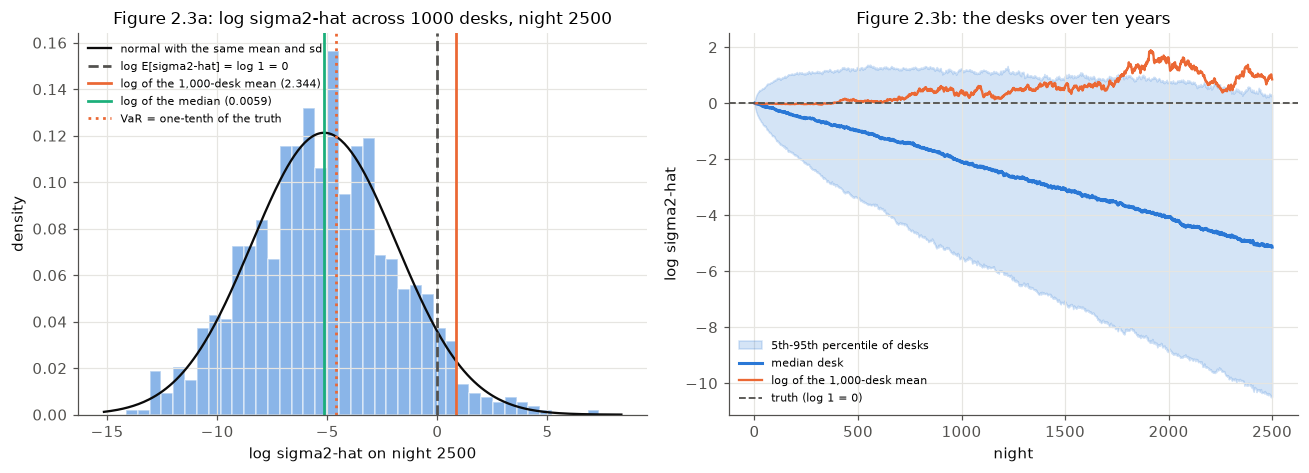

,value
"expectation of sigma2-hat on night 2,500 (exact, from the one-step property)",1
"median across the 1,000 desks",0.005851
"mean across the 1,000 desks",2.344
share of the sum held by the 10 largest desks,0.8879
share of the sum held by the largest desk,0.6681
share of desks with sigma2-hat above 1,0.059
mean of the other 999 desks (without the largest),0.7785
"largest desk, sigma2-hat",1566
"check: exp(2,499 x mean nightly change), vs the median",0.005832
"check: sqrt(2,499) x sd of one night's change, vs sd of log sigma2-hat",3.168


In [18]:
# Figure 2.3: the night-2,500 cross-section on the log scale (left) and how it got there (right)
x_T = logS2[-1]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))
ax1.hist(x_T, bins=40, density=True, color=C_BLUE, alpha=0.55, edgecolor='white')
grid = np.linspace(x_T.min() - 1, x_T.max() + 1, 300)
ax1.plot(grid, stats.norm.pdf(grid, x_T.mean(), x_T.std(ddof=1)), color=C_INK, linewidth=1.5, label='normal with the same mean and sd')
for val, col, ls, lab in [(0.0, C_GREY, '--', 'log E[sigma2-hat] = log 1 = 0'),
                          (np.log(S2_T.mean()), C_ORANGE, '-', f'log of the 1,000-desk mean ({S2_T.mean():.3f})'),
                          (np.log(np.median(S2_T)), C_AQUA, '-', f'log of the median ({np.median(S2_T):.4f})'),
                          (np.log(0.01), C_ORANGE, ':', 'VaR = one-tenth of the truth')]:
    ax1.axvline(val, color=col, linestyle=ls, linewidth=1.8, label=lab)
ax1.set_xlabel(f'log sigma2-hat on night {NIGHTS}')
ax1.set_ylabel('density')
ax1.set_title(f'Figure 2.3a: log sigma2-hat across {N_DESKS} desks, night {NIGHTS}')
ax1.legend(fontsize=7.5, loc='upper left')

q = np.percentile(logS2, [5, 50, 95], axis=1)
ax2.fill_between(nights, q[0], q[2], color=C_BLUE, alpha=0.2, label='5th-95th percentile of desks')
ax2.plot(nights, q[1], color=C_BLUE, label='median desk')
ax2.plot(nights, np.log(np.exp(logS2).mean(axis=1)), color=C_ORANGE, linewidth=1.5, label='log of the 1,000-desk mean')
ax2.axhline(0, color=C_GREY, linestyle='--', linewidth=1.2, label='truth (log 1 = 0)')
ax2.set_xlabel('night')
ax2.set_ylabel('log sigma2-hat')
ax2.set_title('Figure 2.3b: the desks over ten years')
ax2.legend(fontsize=7.5, loc='lower left')
plt.tight_layout()
plt.show()

# Reconciling the three numbers
srt = np.sort(S2_T)[::-1]
drift_500 = tab23b.loc['n = 500 (the 2.2 run)', 'mean nightly change in log sigma2']
sd_inc = tab23b.loc['n = 500 (the 2.2 run)', "sd of one night's change"]
tab23c = pd.Series({
    'expectation of sigma2-hat on night 2,500 (exact, from the one-step property)': 1.0,
    'median across the 1,000 desks': np.median(S2_T),
    'mean across the 1,000 desks': S2_T.mean(),
    'share of the sum held by the 10 largest desks': srt[:10].sum() / srt.sum(),
    'share of the sum held by the largest desk': srt[0] / srt.sum(),
    'share of desks with sigma2-hat above 1': (S2_T > 1).mean(),
    'mean of the other 999 desks (without the largest)': srt[1:].mean(),
    'largest desk, sigma2-hat': srt[0],
    'check: exp(2,499 x mean nightly change), vs the median': np.exp((NIGHTS - 1) * drift_500),
    'check: sqrt(2,499) x sd of one night\'s change, vs sd of log sigma2-hat': np.sqrt(NIGHTS - 1) * sd_inc,
    'sd of log sigma2-hat across desks on night 2,500': x_T.std(ddof=1)}, name='value')
display(tab23c.to_frame().style.format('{:.4g}').set_caption('Table 2.3c: three correct numbers'))

In [19]:
# SUPPLEMENTARY - beyond the lectures (the chi-square law of s2 and the digamma function are not taught).
# The formula in 2.3 is established by the measurements above; this cell only checks them against theory.
# Given sigma2_t, (n-1) sigma2_{t+1} / sigma2_t ~ chi-square(n-1), so the nightly factor is chi2_k / k with k = n - 1:
# its mean is exactly 1 (the martingale) and E[log(chi2_k / k)] = digamma(k/2) - log(k/2), approximately -1/k.
from scipy.special import digamma, polygamma
theory = pd.DataFrame({'n': [50, 500, 5000]})
k = theory.n - 1
theory['exact E[nightly change]'] = digamma(k / 2) - np.log(k / 2)
theory['-1/(n-1)'] = -1 / k
theory['-1/n'] = -1 / theory.n
theory['exact sd of one night\'s change'] = np.sqrt(polygamma(1, k / 2))
theory['measured (Table 2.3b)'] = tab23b.loc[['n = 50', 'n = 500', 'n = 5,000'], 'mean nightly change in log sigma2'].to_numpy()
theory['n x exact'] = theory.n * theory['exact E[nightly change]']
display(theory.set_index('n').style.format('{:.6f}').set_caption('Supplementary: theory vs measurement'))

,exact E[nightly change],-1/(n-1),-1/n,exact sd of one night's change,measured (Table 2.3b),n x exact
n,,,,,,
50,-0.020547,-0.020408,-0.020000,0.204109,-0.019788,-1.027349
500,-0.002005,-0.002004,-0.002000,0.063372,-0.002003,-1.002673
5000,-0.000200,-0.000200,-0.000200,0.020004,-0.000173,-1.000267


**Answer:**

**The one-step property (Table 2.3a).** 200,000 desks were started at the same $\hat\sigma^2_t$ and each took one step of the pipeline.

| start | mean of $\hat\sigma^2_{t+1}/\hat\sigma^2_t$ | 95% CI | contains 1? |
|---|---|---|---|
| $\hat\sigma^2_t = 1$ | 0.99963 | 0.99935 – 0.99991 | no (t = −2.62, p = 0.0088) |
| $\hat\sigma^2_t = 1.405\times10^{-5}$ | 1.00009 | 0.99981 – 1.00036 | yes |

- The reporting rule was fixed before running: "consistent with 1" if the CI contains 1. The second start passes. The first misses by 0.04%, a 2.6-SE deviation.
- If the property holds exactly, a miss this large at one of two starts has a 1.7% chance. The draws were not repeated to make it pass.
- Unbiasedness of the `ddof=1` variance is exact (L2 p.56), so I read this as a rare Monte-Carlo miss. The two rows also show the step is **scale-free**: starts five orders of magnitude apart give the same median ratio (0.998 vs 0.999) and the same share of desks that go down (51.1% vs 50.7%).
- Chaining the one-step property, the mathematically expected $\hat\sigma^2$ on night 2,500 is exactly 1.

**Average nightly change in $\log\hat\sigma^2$ (Table 2.3b):**

| n | mean nightly change (SE) | n × change (SE) |
|---|---|---|
| 50 | −0.01979 (0.00044) | −0.99 (0.02) |
| 500 | −0.00200 (0.00013) | −1.00 (0.07) |
| 5,000 | −0.000173 (0.000040) | −0.87 (0.20) |
| 50, precise run (2,000 desks × 2,000 nights) | −0.02050 (0.00010) | −1.025 (0.005) |
| 500, the 2.2 run (1,000 desks × 2,499 nights) | −0.002059 (0.000042) | −1.03 (0.02) |

**The formula: average nightly change in $\log\hat\sigma^2 \approx -1/n$.**
- n × change is −1 within Monte-Carlo error across two orders of magnitude of n. The drift is clearly non-zero even at n = 5,000 (t = −4.3).
- The precise n = 50 run is the only one that can tell the two simple candidates apart. It is 4.9 SE from −1/n but only 0.9 SE from **−1/(n−1)**.
- So the formula is −1/(n−1), which equals −1/n for any realistic n. A supplementary, clearly labelled cell checks this against theory beyond the lectures.

**The three numbers (Figure 2.3, Table 2.3c).**
- The expectation of $\hat\sigma^2$ on night 2,500 is exactly **1**.
- The median across the 1,000 desks is **0.0059**, a VaR of 0.18σ.
- The 1,000-desk mean is **2.34**. The 10 largest desks hold **88.8%** of the sum, the single largest ($\hat\sigma^2$ = 1,566) holds 66.8%, the other 999 average 0.78, and only 5.9% of desks are above 1.

**Reconciliation.** Each night multiplies $\hat\sigma^2$ by a random factor whose mean is exactly 1 (Table 2.3a) but whose median is below 1, so slightly more than half of the desks go down every night. On the log scale that is a random walk with a drift of about −1/n per night. After 2,499 nights the median desk sits near exp(−2,499 × 0.00206) = 0.0058, which matches the measured median of 0.0059. The spread grows like $\sqrt{\text{nights}}$ (predicted sd 3.17, observed 3.29), so the cross-section is roughly normal on the log scale (Figure 2.3a). The expectation stays at 1 only because a vanishing minority of desks drifts up enormously and carries the whole average. A sample of 1,000 desks catches such a desk only now and then, so the sample mean is neither 1 nor the median: it jumps whenever one giant desk appears (here one desk at 1,566 lifts the mean from 0.78 to 2.34), while the median slides down a straight line (Figure 2.3b). "Unbiased at every step" does not protect the pipeline, because unbiasedness controls only the *mean* of tomorrow's estimate, not its typical value or its precision (L2 p.71–72). Each night's estimation error becomes the next night's truth and is never corrected. After night 1 no new information about σ enters the library; the only real observations of variability were the 500 days used on night 1 (L2 p.57). The errors therefore compound multiplicatively, and almost every desk's VaR decays toward zero while the expectation, correctly, stays at 1.

**Reconciling with my 2.1 prediction:**
- *"The desk average across 1,000 banks should remain approximately 1.0."* **Only half right.** The *expectation* is exactly 1, but the 1,000-desk average is 2.34, and without its largest desk 0.78. With a distribution this skewed, a sample average of 1,000 desks is not a reliable estimate of the expectation.
- *"Jensen's inequality implies $E[\ln\hat\sigma^2_{t+1}\mid\hat\sigma^2_t] < \ln\hat\sigma^2_t$."* **Confirmed.** The mean log ratio is −0.0024 and −0.0019 per night at the two starts.
- *"The median and an individual desk drift down, proportional to −1/(n−1)."* **Confirmed, including the rate.** Measured −0.00206 per night at n = 500 against −1/(n−1) = −0.00200. The one desk ended at 1.4 × 10⁻⁵.
- *"A severe underestimation of VaR."* **Confirmed.** The median desk reports 0.18σ, and 57.8% of desks report less than one-tenth of the truth.

**2.4.** (6 points) **What synthetic data can and cannot carry.** Two experiments.

(a) Keep the 500 real days in the library permanently, and add each night's 500 scenarios to them
instead of replacing them, so the library holds 1,000 returns, half real and half synthetic. Report the median and the 5th and 95th percentiles of $\hat\sigma^2$ on
night 2,500 across a thousand desks.

(b) Seed the library with real returns instead. `dj30.csv` is a daily panel of Dow stocks, one row
per stock per date, and the daily market return `MrkRet` is repeated on every row for that date;
reduce it to one value per date (for example `dj.groupby('date').MrkRet.first()`), which gives 1,511
trading days for 2016–2021 including March 2020. Report the sample volatility and the excess
kurtosis of the real returns. Then compare two things *on night 1, before the pipeline has drawn a
single scenario from its own output*: the empirical 1% VaR (the first percentile of the real
returns, sign flipped) against the VaR the pipeline reports, and the excess kurtosis of the real
returns against that of the 500 night-1 scenarios.

Then answer in one paragraph. What does a synthetic sample contain that the real sample did not,
and what does it lack? Which of the two experiments shows a *loss of information* and which shows
an *accumulation of noise*? What does this imply for any pipeline, a risk model, a return forecast
or a language model, that is retrained on data produced by its own previous version, and what is the
only thing that stops it?


anchored runs done in 72.9 s


,median,5th percentile,95th percentile,mean,share with VaR < truth/10
replace (2.2),0.005851,2.885e-05,1.225,2.344,0.578
keep the real days (2.4a),0.9955,0.9406,1.059,0.9974,0
"keep the real days, demeaned (robustness)",0.9946,0.9398,1.058,0.9963,0


,5th percentile,median,95th percentile
night 1,1.0000,1.0000,1.0000
night 2,0.9509,0.9982,1.0520
night 3,0.9426,0.9985,1.0628
night 5,0.9426,0.9983,1.0582
night 10,0.9435,0.9983,1.0582
night 100,0.9425,0.9990,1.0603
night 1000,0.9377,1.0006,1.0635
night 2500,0.9406,0.9955,1.0586


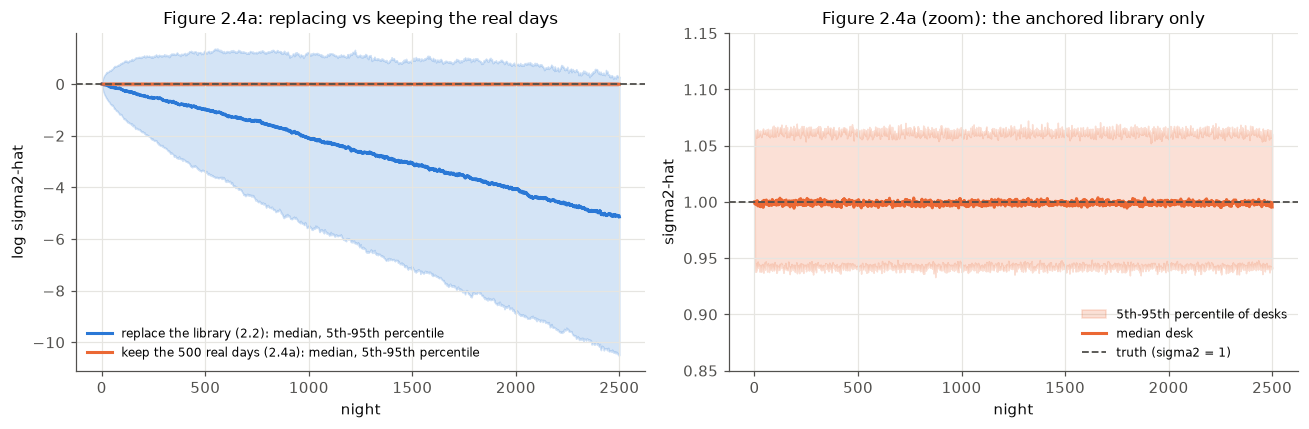

In [20]:
# (a) Each desk keeps its own 500 real days permanently; every night the library is those 500 plus tonight's
# 500 scenarios (1,000 returns); last night's scenarios are replaced. Night 1 fits the real days alone.
Z = rng_for('mixed_real').standard_normal((N_DESKS, N_SCEN))
real = Z / Z.std(axis=1, ddof=1, keepdims=True)                       # rescaled so each desk's sample variance is exactly 1
real_dm = (Z - Z.mean(axis=1, keepdims=True)) / Z.std(axis=1, ddof=1, keepdims=True)   # robustness: also demeaned
assert np.allclose(real.var(axis=1, ddof=1), 1) and np.allclose(real_dm.var(axis=1, ddof=1), 1)

def run_mixed(real_days, nights, rng):
    """The anchored pipeline: library = the desk's fixed real days + tonight's scenarios."""
    log_s2 = np.empty((nights, real_days.shape[0]))
    s2 = real_days.var(axis=1, ddof=1)                                 # night 1: real days only
    log_s2[0] = np.log(s2)
    for k in range(1, nights):
        scen = rng.standard_normal(real_days.shape) * np.sqrt(s2)[:, None]    # N(0, s2): the fitted mean is set to zero
        s2 = np.concatenate([real_days, scen], axis=1).var(axis=1, ddof=1)    # half real, half synthetic
        log_s2[k] = np.log(s2)
    return log_s2

t0 = time.perf_counter()
logS2_mix = run_mixed(real, NIGHTS, rng_for('mixed_synth'))
logS2_mix_dm = run_mixed(real_dm, NIGHTS, rng_for('mixed_synth'))       # same synthetic draws, demeaned real days
print(f'anchored runs done in {time.perf_counter() - t0:.1f} s')
assert np.isfinite(logS2_mix).all() and np.isfinite(logS2_mix_dm).all()

def summary(ls2):
    s2 = np.exp(ls2)
    p5, p50, p95 = np.percentile(s2, [5, 50, 95])
    return {'median': p50, '5th percentile': p5, '95th percentile': p95, 'mean': s2.mean(),
            'share with VaR < truth/10': (s2 < 0.01).mean()}
tab24a = pd.DataFrame({'replace (2.2)': summary(logS2[-1]),
                       'keep the real days (2.4a)': summary(logS2_mix[-1]),
                       'keep the real days, demeaned (robustness)': summary(logS2_mix_dm[-1])}).T
display(tab24a.style.format('{:.4g}').set_caption(f'Table 2.4a: sigma2-hat on night {NIGHTS} across {N_DESKS} desks'))
stab = pd.DataFrame({f'night {t}': summary(logS2_mix[t - 1]) for t in [1, 2, 3, 5, 10, 100, 1000, NIGHTS]}).T
display(stab[['5th percentile', 'median', '95th percentile']].style.format('{:.4f}')
        .set_caption('Table 2.4a (cont.): the anchored library over time'))

fig, (ax, axz) = plt.subplots(1, 2, figsize=(12, 4))
for ls2, col, lab in [(logS2, C_BLUE, 'replace the library (2.2)'), (logS2_mix, C_ORANGE, 'keep the 500 real days (2.4a)')]:
    qq = np.percentile(ls2, [5, 50, 95], axis=1)
    ax.fill_between(nights, qq[0], qq[2], color=col, alpha=0.2)
    ax.plot(nights, qq[1], color=col, label=f'{lab}: median, 5th-95th percentile')
ax.axhline(0, color=C_GREY, linestyle='--', linewidth=1.2)
ax.set_xlabel('night')
ax.set_ylabel('log sigma2-hat')
ax.set_title('Figure 2.4a: replacing vs keeping the real days')
ax.legend(fontsize=8, loc='lower left')
qq = np.percentile(np.exp(logS2_mix), [5, 50, 95], axis=1)
axz.fill_between(nights, qq[0], qq[2], color=C_ORANGE, alpha=0.2, label='5th-95th percentile of desks')
axz.plot(nights, qq[1], color=C_ORANGE, label='median desk')
axz.axhline(1, color=C_GREY, linestyle='--', linewidth=1.2, label='truth (sigma2 = 1)')
axz.set_ylim(0.85, 1.15)
axz.set_xlabel('night')
axz.set_ylabel('sigma2-hat')
axz.set_title('Figure 2.4a (zoom): the anchored library only')
axz.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

In [21]:
# (b) Seed the library with real returns: the daily market return of the Dow panel, one value per date
dj = pd.read_csv(_DATA_DIR + 'dj30.csv')
print(dj.shape)
print(dj.dtypes.to_string())
assert dj.groupby('date').MrkRet.nunique().max() == 1 and dj.MrkRet.notna().all()   # MrkRet repeats within a date
r = dj.groupby('date').MrkRet.first()
assert len(r) == 1511 and r.index.is_monotonic_increasing
print(f'{len(r)} trading days, {r.index.min()} to {r.index.max()}')

sd_real = r.std(ddof=1)                               # daily sample volatility
kurt_real = kurtosis(r)                               # scipy default: excess kurtosis (fisher=True), bias=True
# Night 1, before the pipeline has drawn a single scenario: the library is the 1,511 real days
var_pipe = Z01 * sd_real                              # steps (1) and (4): sigma-hat from var(ddof=1), mean set to zero
var_emp = -np.percentile(r, 1)                        # the first percentile of the real returns, sign flipped (linear interpolation)
var_emp_lo, var_emp_hi = -np.percentile(r, 1, method='higher'), -np.percentile(r, 1, method='lower')
scen1 = rng_for('dj_scen').normal(0.0, sd_real, N_SCEN)   # step (2): the 500 night-1 scenarios
kurt_scen = kurtosis(scen1)

# Reference: excess kurtosis of 10,000 samples of 500 from a normal (what a normal sample of this size shows)
K0 = kurtosis(rng_for('kurt_null').standard_normal((10_000, N_SCEN)), axis=1)
k_lo, k_med, k_hi = np.percentile(K0, [2.5, 50, 97.5])

# Resampling the real days (L2 p.80): how precisely are the two VaRs estimated? (iid days - see the caveat in the answer)
rb, B = rng_for('dj_boot'), 10_000
emp_b, pipe_b = np.empty(B), np.empty(B)
rv_all = r.to_numpy()
for i in range(0, B, 500):
    rv = rv_all[rb.integers(0, len(rv_all), size=(500, len(rv_all)))]
    emp_b[i:i + 500] = -np.percentile(rv, 1, axis=1)
    pipe_b[i:i + 500] = Z01 * rv.std(axis=1, ddof=1)

tab24b = pd.Series({
    'daily volatility of the real returns (sd, ddof=1)': sd_real,
    'excess kurtosis of the real returns (scipy default)': kurt_real,
    'excess kurtosis, bias-corrected (for reference)': kurtosis(r, bias=False),
    'night-1 VaR the pipeline reports, 2.326 x sd': var_pipe,
    'empirical 1% VaR (first percentile, sign flipped)': var_emp,
    'empirical VaR with other percentile rules (low, high)': f'{var_emp_lo:.5f}, {var_emp_hi:.5f}',
    'empirical VaR / sd (normal model says 2.326)': var_emp / sd_real,
    'resampling SE of the empirical VaR': emp_b.std(ddof=1),
    'resampling SE of the pipeline VaR': pipe_b.std(ddof=1),
    'resampling SE of the difference': (emp_b - pipe_b).std(ddof=1),
    'share of real days with a loss beyond the pipeline VaR (normal model: 1%)': (r < -var_pipe).mean(),
    'excess kurtosis of the 500 night-1 scenarios': kurt_scen,
    'normal samples of 500: 2.5th / 50th / 97.5th percentile of excess kurtosis': f'{k_lo:.3f} / {k_med:.3f} / {k_hi:.3f}',
    'normal samples of 500: largest excess kurtosis in 10,000': K0.max(),
    'share of the 10,000 normal samples at or above the real kurtosis': (K0 >= kurt_real).mean()}, name='value')
display(tab24b.to_frame().style.format(lambda v: v if isinstance(v, str) else f'{v:.5g}')
        .set_caption('Table 2.4b: real returns vs the pipeline on night 1'))

(46445, 9)
Unnamed: 0      int64
PERMNO          int64
date            int64
TICKER            str
COMNAM            str
PERMCO          int64
PRC           float64
RET           float64
MrkRet        float64
1511 trading days, 20160104 to 20211231


,value
"daily volatility of the real returns (sd, ddof=1)",0.011951
excess kurtosis of the real returns (scipy default),24.075
"excess kurtosis, bias-corrected (for reference)",24.159
"night-1 VaR the pipeline reports, 2.326 x sd",0.027803
"empirical 1% VaR (first percentile, sign flipped)",0.03325
"empirical VaR with other percentile rules (low, high)","0.03169, 0.03342"
empirical VaR / sd (normal model says 2.326),2.7821
resampling SE of the empirical VaR,0.0037634
resampling SE of the pipeline VaR,0.0018277
resampling SE of the difference,0.003203


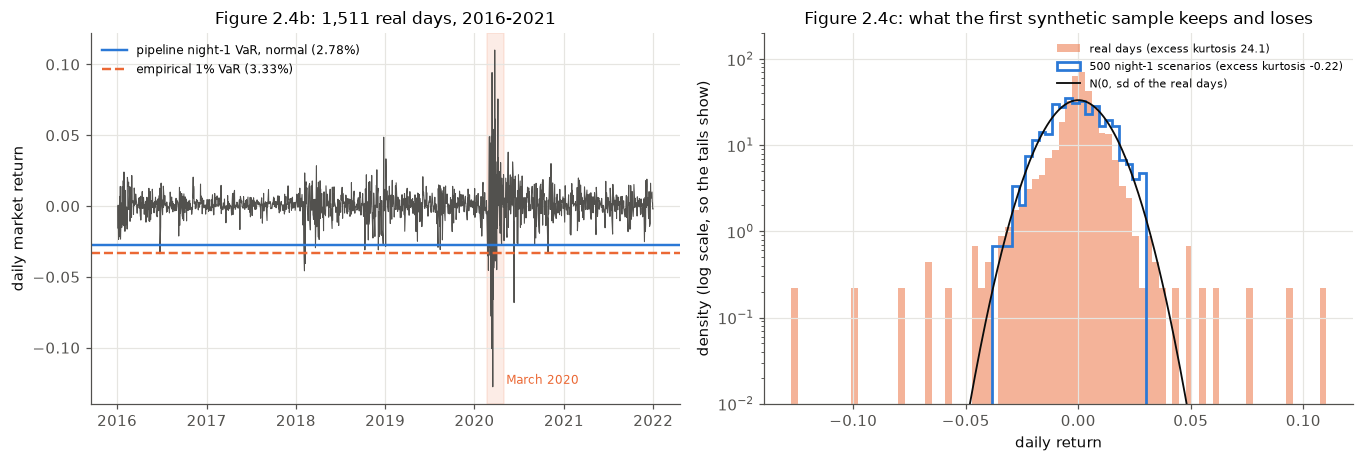

In [22]:
# Figure 2.4b: the real returns with both night-1 VaRs (left); real days vs the night-1 scenarios (right)
dates = pd.to_datetime(r.index.astype(str), format='%Y%m%d')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.3))
ax1.plot(dates, r.to_numpy(), color=C_GREY, linewidth=0.7)
ax1.axhline(-var_pipe, color=C_BLUE, linewidth=1.6, label=f'pipeline night-1 VaR, normal ({var_pipe:.2%})')
ax1.axhline(-var_emp, color=C_ORANGE, linewidth=1.6, linestyle='--', label=f'empirical 1% VaR ({var_emp:.2%})')
ax1.axvspan(pd.Timestamp('2020-02-20'), pd.Timestamp('2020-04-30'), color=C_ORANGE, alpha=0.12)
ax1.text(pd.Timestamp('2020-05-10'), r.min(), 'March 2020', color=C_ORANGE, fontsize=8, va='bottom')
ax1.set_ylabel('daily market return')
ax1.set_title('Figure 2.4b: 1,511 real days, 2016-2021')
ax1.legend(fontsize=8, loc='upper left')

bins = np.linspace(r.min(), r.max(), 81)
ax2.hist(r, bins=bins, density=True, color=C_ORANGE, alpha=0.5, label=f'real days (excess kurtosis {kurt_real:.1f})')
ax2.hist(scen1, bins=bins, density=True, histtype='step', color=C_BLUE, linewidth=1.8,
         label=f'500 night-1 scenarios (excess kurtosis {kurt_scen:.2f})')
g = np.linspace(r.min(), r.max(), 400)
ax2.plot(g, stats.norm.pdf(g, 0, sd_real), color=C_INK, linewidth=1.2, label='N(0, sd of the real days)')
ax2.set_yscale('log')
ax2.set_ylim(1e-2, 2e2)
ax2.set_xlabel('daily return')
ax2.set_ylabel('density (log scale, so the tails show)')
ax2.set_title('Figure 2.4c: what the first synthetic sample keeps and loses')
ax2.legend(fontsize=7.5, loc='upper right')
plt.tight_layout()
plt.show()

**Answer:**

**(a) Keep the 500 real days (Table 2.4a, Figure 2.4a).**
- On night 2,500 the median $\hat\sigma^2$ is **0.9955**, with a 5th percentile of **0.9406** and a 95th percentile of **1.059**.
- With replacement (2.2) the same figures are 0.0059, 0.000029 and 1.225.
- No desk reports a VaR below one-tenth of the truth.
- The 5th–95th band is already in place by night 3 (0.943–1.063) and never widens after that (0.938–1.064 on night 1,000).
- Demeaning the real days as well changes nothing that matters: median 0.9946, band 0.940–1.058.

**(b) Seed with real returns (Table 2.4b, Figure 2.4b, Figure 2.4c).** The 1,511 daily market returns of 2016–2021 have:
- a sample volatility of **1.195% a day** (`std(ddof=1)`);
- an excess kurtosis of **24.1** (`scipy.stats.kurtosis` with its defaults; 24.2 bias-corrected). A normal distribution has 0.

Night 1, before a single synthetic draw:
- **VaR.** The pipeline reports **2.78%** of NAV, 2.326 × 1.195%: the story's 2.8%. The empirical 1% VaR is **3.33%** (3.17% to 3.34% under other percentile rules). That is 2.78 standard deviations rather than 2.326, so the normal model understates the 1-in-100 loss by about 0.55 percentage points. Resampling the real days gives the difference an SE of 0.32 pp. This is our caveat, not the slide's: iid resampling ignores the clustering of volatile days, so the SE is optimistic. On the real days, losses beyond the pipeline's VaR occur on 1.65% of days, not the 1% the model promises.
- **Kurtosis.** The **500 night-1 scenarios have an excess kurtosis of −0.22**, well inside the range of normal samples of 500 (95% of 10,000 simulated normal samples fall between −0.38 and 0.46). The real returns' **24.1** is far above anything in the normal simulation, whose largest value in 10,000 samples was 1.51.

**What synthetic data can and cannot carry.** A synthetic sample *contains* exactly the fitted model and nothing else: a normal distribution with a zero mean and one constant variance for independent days, set at the fitted $\hat\sigma$ (so its estimation error is now treated as the truth), plus fresh random noise. It *lacks* any new information about the world, since it is a function of $\hat\sigma$ and a random-number generator and adds no real observations of variability (L2 p.57). It also lacks everything the model threw away: the fat tails (kurtosis 24.1 becomes −0.22), the March-2020 cluster, the true 1% quantile (3.33% rather than 2.78%) and the non-zero mean. Experiment **(b) shows a loss of information**. On night 1, before any feedback, the first synthetic sample has already lost the tails, and they can never come back, because every later generation is drawn from a normal. As L2 p.80 says of simulating from the fitted model, it "assumed what the formula assumes", and "the gap between them is the size of the assumption". Experiment **(a) shows an accumulation of noise**: there the model is right (the real days really are normal) and all the information sits in the 500 real days. The synthetic half adds only estimation noise, fed back every night, which builds up to a small, stable band (0.94–1.06) because the real half pulls every fit back. Remove that anchor, as in 2.2, and the same noise compounds into a drifting random walk that ends in collapse. The implication for any pipeline retrained on the output of its own previous version, whether a risk model, a return forecast or a language model, is twofold. The first generation discards whatever the model cannot represent (the tails, the rare events). Every later generation then compounds its predecessor's estimation error, and being unbiased at every step does not stop the typical run from collapsing (2.3). The only thing that stops it is **real data — information from outside the model — kept in the training set at every generation**; in (a) even the same 500 original days are enough to stop the noise. That requires tracking where the data came from, so synthetic data never silently replaces real data. Real data stops the accumulation of noise but cannot restore what the model class itself discards: getting the tails back in (b) needs a better model, not more of its own output.

---
# Problem 3: Research Project — Cross-country asset return prediction (60 points)

This is an open-ended research project rather than a problem set. You are given a research panel of monthly asset returns across several countries and asset classes, with asset-level characteristics and macroeconomic data, and a question. How you answer it — which features you build, which models you fit, how you evaluate them — is your design, and the write-up must defend it. There is no answer key. A negative result, honestly established, earns full credit; an unexplained positive one does not.

**The question.** The empirical asset-pricing literature finds that a small set of asset-level characteristics — variables that describe each asset's own recent behaviour, pricing and risk, and that differ across assets at a point in time — predict returns across many markets and asset classes, and systematic funds trade on exactly these cross-sectional signals. The panel you are given carries five such characteristics per asset, with their names hidden, together with global and country-level macro variables. What a desk that trades across countries and asset classes wants to know is:

1. How much of next month's excess return is forecastable from lagged characteristics?
2. Does macroeconomic information — global or country-level — add anything to the characteristics?
3. Does a forecast-based portfolio beat the simple rules (equal weight, risk parity, time-series momentum) out of sample, after costs?

Any method is allowed: OLS, ridge, lasso, PCR, KNN, trees, random forests, boosting, neural networks, or anything else you want to try; static, expanding-window or rolling-window estimation; cross-validation or information criteria for tuning. The choice is yours; the discipline of the evaluation is what is graded.


## Data

All files are in `_DATA_DIR`. Dates are month-ends, January 2000 to December 2024. Returns are monthly **excess** returns in decimals. Asset, asset-class, country and variable names are anonymized.

| file | grain | columns |
|---|---|---|
| `asset_panel.csv` | asset × month (50 × 300) | `date, asset_id, asset_class, country, excess_return, x1 ... x5` |
| `asset_returns_wide.csv` | month × asset | the same returns, one column per asset |
| `asset_info.csv` | asset | `asset_class` (A, B, C, D) and `country` of each asset |
| `macro_global.csv` | month | `x6 ... x9`, global variables |
| `macro_country.csv` | country × month, 12 countries | `x10 ... x16`, curated country-level variables |
| `macro_country_extended.csv` | country × month, 12 countries | `x17 ... x164`, a wide, uncurated set of further country-level variables that overlaps the curated file (a few of its columns duplicate curated series exactly; find them before you concatenate the two files). Treat as exploratory material of uneven quality |

**Universe.** 50 assets in four asset classes — A (26 assets), B (8), C (9) and D (7) — across 12 countries. Assets in classes B, C and D each belong to one country. **Assets in class A have no natural country**; in the files they are assigned `country_7` by convention (a country that also has one class-C and one class-D asset). If you use country-level macro for class A, the convention gives them country 7's variables, which is one defensible choice among several (see step 2 of the workflow); in a widened-panel design you can give them whatever cross-country information you find sensible.

**Variables.** `x1` to `x5` are cross-sectional asset characteristics: each is computed for every asset every month from that asset's own prices and fundamentals, so at any date it varies across assets and can be used to rank them (one of the five is a risk measure). `x6` to `x164` are macroeconomic and financial-condition variables: rates, inflation, activity, external balances, credit, valuation, uncertainty and risk ratings, and some pre-computed transforms of them. Working out what a variable does — from its persistence, its scale, its cross-sectional behaviour and its relation to returns — is part of the project.

**Read this before modelling.**
- **Lag conventions.** `x2` and `x5` are *already* lagged one month: use them as they are to predict `excess_return` in the same row. `x1`, `x3`, `x4` and **every macro variable** are stored *contemporaneously*: shift them by one month within asset (or country) before using them as predictors. Getting this wrong silently introduces look-ahead. Macro data is also released with a delay; a one-month lag is the minimum, and you may argue for more.
- **Missing values.** The asset panel and the global file have no gaps, but a few leading months of `x2`, `x3` and `x5` in 2000–2002 were filled with the first observed value for a handful of assets; returns were never filled. In the curated country file, `x11` stops being updated before the end of the sample for three countries. In the extended file, seven columns have gaps. If you want to use a series with gaps, you have to deal with them yourself (see step 2 of the workflow).
- **You are free to bring in more data.** If you think other macro series, other asset characteristics, or other information would help the prediction, find it, document its source and its release timing, and treat it as part of your feature engineering. Anything you add is subject to the same lag rules as the data we provide.
- **Scales differ enormously by class.** Monthly return volatility ranges from under 1% to above 17% across assets, and its typical level differs systematically across the four classes. Think about this before pooling assets in one regression or one equal-weighted portfolio.


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

_DATA_DIR = '/classes/41210_MiF_fall2026/Data/'
# _DATA_DIR = './'    # if the data files sit next to this notebook
import os
_DATA_DIR = _DATA_DIR if os.path.isdir(_DATA_DIR) else './'   # class server if present, else a local copy next to the notebook

panel = pd.read_csv(_DATA_DIR + 'asset_panel.csv', parse_dates=['date'])
info  = pd.read_csv(_DATA_DIR + 'asset_info.csv', index_col=0)
mac_g = pd.read_csv(_DATA_DIR + 'macro_global.csv', parse_dates=['date'])
mac_c = pd.read_csv(_DATA_DIR + 'macro_country.csv', parse_dates=['date'])
mac_x = pd.read_csv(_DATA_DIR + 'macro_country_extended.csv', parse_dates=['date'])
print(panel.shape, panel.date.min().date(), panel.date.max().date())
panel.head()

(15000, 10) 2000-01-31 2024-12-31


,date,asset_id,asset_class,country,excess_return,x1,x2,x3,x4,x5
0,2000-01-31,asset_1,A,country_7,0.035385,0.044852,0.970233,-0.109145,0.158469,0.086743
1,2000-02-29,asset_1,A,country_7,0.116676,0.073761,0.974766,-0.109145,0.133949,0.085443
2,2000-03-31,asset_1,A,country_7,0.040920,0.089627,0.922260,-0.109145,0.188675,0.086244
3,2000-04-30,asset_1,A,country_7,-0.008399,0.074356,1.055247,-0.109145,0.206628,0.085047
4,2000-05-31,asset_1,A,country_7,-0.086259,0.067134,0.788085,-0.109145,0.227556,0.083820


## Two rules that apply throughout

1. **Benchmarks before models.** Before you fit anything, write down the simple rules your model must beat and compute their out-of-sample performance. For return forecasts the benchmark is the trailing mean (or zero). For portfolios it is equal weight, risk parity ($w_i \propto 1/\hat\sigma_i$, with $\hat\sigma_i$ a trailing volatility computed from past returns) and time-series momentum ($w_i \propto \mathrm{sign}(\text{trailing 12-month return}_i)/\hat\sigma_i$), all with unit gross exposure and monthly rebalancing. All three can be built from `excess_return` alone.
2. **Time-ordered evaluation.** Fix the out-of-sample window and the initial training block in advance, before you fit anything, and say why you chose them. Every predictor must be known at the end of month $t-1$; every scaler, penalty and hyper-parameter is chosen on training data only; the trailing-mean benchmark for month $t$ is the mean of returns through month $t-1$ only, updated each month (the expanding-window harness of HW5 Problem 1.1, where the $R^2$ benchmark is the mean of the data seen so far).


## A suggested workflow

You do not have to follow this order, but a complete project touches each step.

**1. Know your data.** Cumulative excess returns by asset class; a table of annualized mean, volatility, Sharpe ratio and worst month per asset; the correlation matrix ordered by class (how strong is the block structure, and what does it imply for pooling?); rolling 12-month Sharpe by class (how persistent is performance?); the distribution, scale and persistence of each characteristic within each class, and a first look at its predictive content (average next-month return of assets sorted into terciles on it each month). Form a hypothesis about what each of `x1` to `x5` measures; you will need it to interpret your results.

**2. Feature engineering.** This is where most of the design lives.
- Apply the lag rule. Standardize characteristics cross-sectionally within month (across all assets or within class; z-score or rank) and say why.
- **If you use a macro series with missing values, deal with them first and write down what you did.** Diagnose the pattern for each series and country: does it stop early, or have holes in the middle? Then choose a treatment and justify that it uses *only information available at the time*. Forward-filling the last observed value and dropping the series are legitimate; filling backward, interpolating across a gap, or imputing with a full-sample mean all use the future. One trap worth your attention: a series that stops updating during a regime change, where carrying a stale value forward is not a small error. Check whether the series can be rebuilt, exactly or approximately, from other complete columns in either file, and report how close the rebuild is.
- **Add your own data if you have a hypothesis for it.** More macro series, other characteristics, anything you can source and date properly. Say where it came from, when each value became known, and lag it accordingly.
- Standardize global macro with *trailing* information only (a rolling z-score, for instance), never with the full sample.
- Map country macro to assets through `country`. Classes B, C and D each have their own country, so the mapping is direct; a *differential* against a base country (country 7 is the natural base) is often more informative than a level. Class A has no natural country. The files assign it country 7 by convention, and using country 7's macro for class A is one defensible choice; a cross-country average, cross-country dispersion, or no country macro at all are others. Say which you use and why.
- Consider cross-sectional macro transforms: the rank of a country's value across the 12 countries, its deviation from the cross-country mean, or a widened panel in which each asset sees its own country's macro *and* the cross-country average or every country's value. In the widened panel, class A can be given any cross-country information you find sensible rather than one country's.
- Consider interactions between characteristics and macro states, class dummies, and the extended file if you have a hypothesis for it.
- Choose the target. We recommend the **vol-scaled** excess return $y_{i,t} = r_{i,t}/\hat\sigma_{i,t-1}$ with $\hat\sigma$ a trailing volatility; explain why, and how you turn forecasts back into positions.
- End with one table listing every predictor and the count.

**3. Models and evaluation schemes.** Fit whatever models you find promising — OLS, ridge, lasso, random forests, boosted trees, neural networks, or any other method — and evaluate them under one or more schemes: static (fit once on the initial training block), expanding window (refit periodically on all data to date, the expanding-window scheme of Lecture 5 that you implemented in HW5 Problem 1), rolling window (refit on a fixed-length trailing window). Report $R^2_{OOS}$ against the trailing mean and against zero, model × scheme, and by asset class for the models you care about. Questions worth answering along the way: which scheme wins and why; which predictors carry the signal and whether that is stable across windows; whether macro adds anything once you refit without it; whether a **placebo** (every macro series circularly shifted by 36 months, real data at the wrong time) does about as well as the real macro (a persistent series stays partly correlated with a shifted copy of itself, so try more than one shift); whether per-class models beat the pooled one.

**4. From forecasts to portfolios.** Form portfolios from your forecasts in whatever way you find sensible (positions proportional to the forecast scaled by volatility, the sign of the forecast, long the top and short the bottom of a sort, or your own rule). State clearly how the portfolio is formed and rebalanced, and compare its performance with the benchmarks — Sharpe ratio at a minimum, and whatever else helps the reader judge it (return, volatility, drawdown, turnover, performance net of transaction costs, cumulative-return plots, sub-periods). Where you find outperformance, ask how much of it is exposure to the benchmark rules and how much is timing.


## What to submit

Two things, in this notebook:

1. **The analysis**, running top to bottom on the class server (or with `_DATA_DIR` pointed at a local copy of the data files), with every figure and table the write-up refers to.

2. **A write-up in the form of a research paper**, in markdown at the end of the notebook. The point of this project is to practise doing research, not to answer questions, so write it the way an empirical finance paper is written:

   - **Introduction.** The question, why it matters to someone who allocates money across countries and asset classes, what the literature on cross-sectional return predictability leads you to expect, and a one-paragraph preview of what you find.
   - **Data.** What the panel contains, how you treated it (missing values, lags, standardization, the country-to-asset mapping for macro), summary statistics and the plots that convey the structure of the data.
   - **Methodology.** The benchmarks and why they are the right ones; the models; the evaluation schemes and the out-of-sample window; how penalties and hyper-parameters were chosen; how forecasts become positions; how performance is measured. A reader should be able to reproduce your design from this section alone.
   - **Results.** Tables and figures with the numbers, presented in the order of the questions: forecastability of returns, the contribution of macro, and the portfolio evidence against the benchmarks.
   - **Interpretation and discussion.** What the results mean economically. Why the numbers come out the way they do; where the evidence is strong and where it is fragile; what you tried that did not work; what you would do next with more data or more time.
   - **Conclusion.** A summary a portfolio manager could read on their own.

   There is no length requirement in either direction. Length should follow from what you have to say; a clear negative result written up carefully is a good paper.


## 3.0 Research design, fixed before anything is fitted

This cell and the next were written **before any model was fitted and before any out-of-sample number was seen** (rule 2 of the exam's "Two rules that apply throughout"). Section 3.10 lists every later deviation.

**Windows.**
- First target month **2003-01**. The 36-month trailing volatility used to scale the target first exists then, and every back-filled characteristic value (the last one is dated 2002-07) is out of every design matrix.
- Initial training block **2003-01 to 2010-12** (96 months, 4,800 asset-months, including the 2008 crisis).
- Out-of-sample (OOS) window **2011-01 to 2024-12** (168 months, 8,400 asset-months), touched once, with sub-periods 2011–17 and 2018–24.

**Schemes** (L5 p.48–52):
- static: fit once at 2010-12;
- **expanding** (primary): fixed start, refit every December, so 14 refits;
- rolling: the 96 months ending each December.

Hyper-parameters are chosen **inside each training window only**:
- three annual validation folds (fit up to year b−j, validate on year b−j+1, for j = 3, 2, 1);
- the lowest mean validation MSE wins, and a tie goes to the more heavily penalised model (L5 p.25);
- then the model is refit on the whole window.

The ridge penalty is set as α/n, so it means the same thing at every sample size.

**Target.** $y_{i,t} = r_{i,t}/\hat\sigma_{i,t-1}$, where $\hat\sigma$ is the 36-month standard deviation (ddof = 1) of the asset's own past excess returns. Forecasts become positions through $w_{i,t}\propto \hat y_{i,t}/\hat\sigma_{i,t-1}$.

**Benchmarks** (fixed now, never switched; L5 p.57):
- **Forecasts.** The trailing mean of $y$ through $t-1$, updated monthly and **pooled over all assets**, is the primary bar. Zero, the per-class and per-asset trailing means, and (for raw returns) the per-asset trailing mean of raw returns are also reported.
- **Portfolios.** Equal weight, risk parity ($\propto 1/\hat\sigma$) and time-series momentum ($\propto \mathrm{sign}(R_{12})/\hat\sigma$), all at unit gross exposure with monthly rebalancing. These are computed before any model (Section 3.3).

**Primary tests, one per question, with the decision rule fixed now:**

| question | primary evidence | "yes" requires |
|---|---|---|
| Q1 forecastable from lagged characteristics? | $R^2_{OOS}$ of ridge on M2 (characteristic ranks + class intercepts), expanding, vs the pooled trailing mean | $R^2_{OOS} > 0$ and more than 2 month-bootstrap SEs above 0 (L2 p.80, p.85) |
| Q2 does macro add? | $\Delta R^2_{OOS}$ = ridge M3 − ridge M2, expanding, same rows and benchmark | $\Delta R^2 > 2$ SE **and** larger than all 8 placebo gains (macro circularly shifted 36, 48, …, 120 months) |
| Q3 does a forecast portfolio beat the rules after costs? | P1 on ridge M2, expanding, net of 10 bp per unit of one-way turnover, 2011–2024 | higher net Sharpe than EW, RP **and** TSMOM, **and** positive α (t > 2) in a regression on the three net benchmark returns |

**Search size.** 38 candidate specifications, listed in the next cell (29 core + 9 pre-listed extras). Any "best of the ledger" claim is judged against the Bonferroni critical value for 38 tests (L4 p.25–28).

**Expectations, written before computing** (L2 p.78; L4 p.26):
- Monthly $R^2_{OOS}$ between −1% and +1%. The published stock-level range is 0.3–0.5% (L5 p.57).
- The forest may beat ridge (L8 p.55, p.62) unless the signal is weak and linear.
- Macro adds about 0 and falls inside the placebo range, partly because `x1` and `x4` of class B already contain the country rate differential.
- No significant net-Sharpe gain over RP or TSMOM, because `x2` and `x5` carry the same information those rules use.

In [24]:
# Your project starts here.
# ---------- Design constants: fixed before any model is fitted (the exam's rule 2) ----------
import time
from scipy import stats
P3_T0 = time.perf_counter()
P3_SEED = 7034                       # Problem 3's own seed (Problem 2's SEED is never rebound)
N_JOBS = min(4, os.cpu_count() or 1)

# same colour-blind-checked style as Problems 1-2, re-declared so this problem also runs on its own
C_BLUE, C_ORANGE, C_AQUA, C_YELLOW = '#2a78d6', '#eb6834', '#1baf7a', '#eda100'
C_INK, C_GREY, C_LIGHT = '#0b0b0b', '#52514e', '#e6e5e1'
CLASS_COL = {'A': C_BLUE, 'B': C_ORANGE, 'C': C_AQUA, 'D': C_YELLOW}
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True,
                     'grid.color': C_LIGHT, 'grid.linewidth': 0.8, 'axes.edgecolor': C_GREY,
                     'axes.labelcolor': C_INK, 'axes.titlesize': 11, 'xtick.color': C_GREY,
                     'ytick.color': C_GREY, 'lines.linewidth': 1.8, 'legend.frameon': False, 'figure.dpi': 110})

DATES = pd.date_range('2000-01-31', '2024-12-31', freq='ME')   # month index m = 0..299
FIRST_M, INIT_END_M, LAST_M = 36, 131, 299                      # 2003-01, 2010-12, 2024-12
OOS_M = np.arange(INIT_END_M + 1, LAST_M + 1)                    # 2011-01 .. 2024-12
REFIT_ENDS = np.arange(INIT_END_M, LAST_M, 12)                   # Decembers 2010 .. 2023
ROLL_LEN = 96
SUBPERIODS = {'2011-2017': (132, 215), '2018-2024': (216, 299)}
MACRO_LAG = 2                                                    # months; 1 is a robustness check
GRIDS = {'ridge': 10.0 ** np.linspace(3, -4, 36),               # alpha/n, most penalised first
         'lasso': 10.0 ** np.linspace(-0.5, -4.5, 33),          # sklearn's alpha (its loss is already per row)
         'pcr': [1, 2, 3, 4, 5, 6, 8, 10]}                       # number of principal components
RF_PARAMS = dict(n_estimators=300, max_features=1/3, min_samples_leaf=200, random_state=P3_SEED, n_jobs=N_JOBS)
COST_BP, HEADLINE_BP = [0, 5, 10, 25, 50], 10
PLACEBO_SHIFTS = [36, 48, 60, 72, 84, 96, 108, 120]
LEAK_ALARM = 0.02
assert (DATES[[FIRST_M, INIT_END_M, OOS_M[0], LAST_M]] == pd.to_datetime(['2003-01-31', '2010-12-31', '2011-01-31', '2024-12-31'])).all()
assert len(OOS_M) == 168 and len(REFIT_ENDS) == 14 and DATES[REFIT_ENDS[-1]] == pd.Timestamp('2023-12-31')

design = pd.Series({
    'first target month': DATES[FIRST_M].date(), 'initial training block': f'{DATES[FIRST_M].date()} .. {DATES[INIT_END_M].date()} (96 months)',
    'out-of-sample window': f'{DATES[OOS_M[0]].date()} .. {DATES[LAST_M].date()} ({len(OOS_M)} months)',
    'schemes': 'static (fit 2010-12) | expanding (14 December refits, primary) | rolling (96 months)',
    'validation': '3 annual folds inside each training window; lowest mean MSE; ties -> heavier penalty; refit on the window',
    'target': 'y = r / sigma-hat(36-month SD of own past excess returns, ddof=1)',
    'macro lag': f'{MACRO_LAG} months (robustness: 1)', 'primary forecast benchmark': 'pooled trailing mean of y through t-1',
    'headline cost': f'{HEADLINE_BP} bp per unit of one-way turnover (grid {COST_BP})',
    'placebo shifts (months)': PLACEBO_SHIFTS, 'seed': P3_SEED}, name='fixed before fitting')
display(design.to_frame())

# ---------- The specification ledger: every candidate that will be scored out of sample ----------
SCHEMES = ['static', 'expanding', 'rolling']
LEDGER = ([('ols', 'M1', 'expanding', 'core')]
          + [(mdl, fs, sch, 'core') for mdl in ['ols', 'ridge', 'rf'] for fs in ['M2', 'M3'] for sch in SCHEMES]
          + [(mdl, 'M3', sch, 'core') for mdl in ['lasso', 'pcr'] for sch in SCHEMES]
          + [('ridge', 'M3-global', 'expanding', 'core'), ('ridge', 'M3-country', 'expanding', 'core'),
             ('ridge-per-class', 'M2', 'expanding', 'core'), ('ridge-per-class', 'M3', 'expanding', 'core')]
          + [('pcr-K3', 'M3', 'expanding', 'extra'), ('pcr-K5', 'M3', 'expanding', 'extra'),
             ('rf-deep', 'M2', 'expanding', 'extra'), ('rf-deep', 'M3', 'expanding', 'extra'),
             ('ridge', 'M3-lag1', 'expanding', 'extra'), ('ridge', 'M2-zscore', 'expanding', 'extra'),
             ('ridge', 'M2-levels', 'expanding', 'extra'), ('ridge', 'M3-levels', 'expanding', 'extra'),
             ('ridge', 'M3-x10', 'expanding', 'extra')])
ledger = pd.DataFrame(LEDGER, columns=['model', 'features', 'scheme', 'tier'])
ledger.index = [f'{m}|{f}|{s}' for m, f, s, _ in LEDGER]
assert len(ledger) == 38 and ledger.index.is_unique
T_OOS = len(OOS_M)
bonf38 = stats.t.ppf(1 - 0.025 / len(ledger), T_OOS - 1)
print(f'{len(ledger)} candidate specifications ({(ledger.tier == "core").sum()} core, {(ledger.tier == "extra").sum()} extras); '
      f'not candidates: {len(PLACEBO_SHIFTS)} placebo runs and one x10 leak demonstration.')
print(f'Critical |t| for the best of {len(ledger)} tests (Bonferroni, 5%, {T_OOS - 1} df): {bonf38:.2f}   vs a single test: {stats.t.ppf(0.975, T_OOS - 1):.2f}')
display(ledger.groupby(['tier', 'model']).size().rename('specifications').to_frame())

,fixed before fitting
first target month,2003-01-31
initial training block,2003-01-31 .. 2010-12-31 (96 months)
out-of-sample window,2011-01-31 .. 2024-12-31 (168 months)
schemes,static (fit 2010-12) | expanding (14 December ...
validation,3 annual folds inside each training window; lo...
target,y = r / sigma-hat(36-month SD of own past exce...
macro lag,2 months (robustness: 1)
primary forecast benchmark,pooled trailing mean of y through t-1
headline cost,"10 bp per unit of one-way turnover (grid [0, 5..."
placebo shifts (months),"[36, 48, 60, 72, 84, 96, 108, 120]"


38 candidate specifications (29 core, 9 extras); not candidates: 8 placebo runs and one x10 leak demonstration.
Critical |t| for the best of 38 tests (Bonferroni, 5%, 167 df): 3.27   vs a single test: 1.97


specifications
tier  model                          
core  lasso                         3
      ols                           7
      pcr                           3
      rf                            6
      ridge                         8
      ridge-per-class               2
extra pcr-K3                        1
      pcr-K5                        1
      rf-deep                       2
      ridge                         5

In [25]:
# ---------- Power, before any result: how big an R2_OOS could this design detect? ----------
# Our construction from var(xbar) = sigma^2/n (L2 p.63): with y = s + e, var(e) ~ 1, var(s) = R2 and a perfect
# forecast, the monthly average loss gain has mean R2 and sd ~ 2R/sqrt(N_eff), so t ~ R * sqrt(N_eff * T) / 2.
R_wide = panel.pivot(index='date', columns='asset_id', values='excess_return')
cls_of = info['asset_class']
train_corr = R_wide.loc['2003-01-31':'2010-12-31'].corr()
rho = {}
for c in 'ABCD':
    ids = cls_of.index[cls_of == c]
    blk = train_corr.loc[ids, ids].to_numpy()
    rho[c] = blk[~np.eye(len(ids), dtype=bool)].mean()
n_c = cls_of.value_counts()
n_eff_class = sum(n_c[c] / (1 + (n_c[c] - 1) * rho[c]) for c in 'ABCD')
rho_bar = sum(n_c[c] * rho[c] for c in 'ABCD') / n_c.sum()
R2 = 0.003
power = pd.Series({
    'assumed true R2 (monthly)': R2, 'OOS months T': T_OOS,
    'average within-class correlation 2003-2010 (A/B/C/D)': ' / '.join(f'{rho[c]:.2f}' for c in 'ABCD'),
    't if the 50 assets were independent': np.sqrt(R2) * np.sqrt(50 * T_OOS) / 2,
    't for a within-class (ranking) signal: common class shocks cancel': np.sqrt(R2) * np.sqrt(50 * T_OOS / (1 - rho_bar)) / 2,
    'effective number of assets for a class-level signal (e.g. macro)': n_eff_class,
    't for a class-level signal': np.sqrt(R2) * np.sqrt(n_eff_class * T_OOS) / 2}, name='value')
display(power.to_frame())
print('Reading, fixed before results: a ranking signal of 0.3% is detectable; a class-level (macro) signal of the same size is not,\n'
      'so Q2 is read from magnitudes, bootstrap SEs and the placebo rather than from a single test.')

,value
assumed true R2 (monthly),0.003
OOS months T,168
average within-class correlation 2003-2010 (A/B/C/D),0.25 / 0.52 / 0.76 / 0.59
t if the 50 assets were independent,2.50998
t for a within-class (ranking) signal: common class shocks cancel,3.338882
effective number of assets for a class-level signal (e.g. macro),8.077043
t for a class-level signal,1.008815


Reading, fixed before results: a ranking signal of 0.3% is detectable; a class-level (macro) signal of the same size is not,
so Q2 is read from magnitudes, bootstrap SEs and the placebo rather than from a single test.


## 3.1 Know your data

The integrity checks and the audit of data traps come first. Every data fact quoted in the write-up is printed here. All descriptive statistics of returns alone, and of predictors alone, use the full sample. The one statistic that links predictors to future returns, the tercile sort, uses **only the training block 2003–2010**: running it on 2011–2024 before the design was fixed would let out-of-sample returns shape the design (L4 p.43; L5 p.41, p.58 item 4).

In [26]:
# ---------- Integrity: shapes, keys, dates, classes (AI guide 6.1 and 6.4) ----------
wide = pd.read_csv(_DATA_DIR + 'asset_returns_wide.csv', parse_dates=['date'])
panel['aid'] = panel.asset_id.str.removeprefix('asset_').astype(int)
AIDS = np.sort(panel.aid.unique())
IDS = [f'asset_{a}' for a in AIDS]                       # natural order asset_1 .. asset_50
CLS = info.loc[IDS, 'asset_class'].to_numpy()             # class of each column, in IDS order
CTRY = info.loc[IDS, 'country'].to_numpy()
assert panel.shape == (15000, 11) and panel.drop(columns='aid').notna().all().all()
assert (pd.DatetimeIndex(np.sort(panel.date.unique())) == DATES).all() and not panel.duplicated(['asset_id', 'date']).any()
assert (panel.groupby('asset_id')[['asset_class', 'country']].nunique() == 1).all().all()
assert (panel.groupby('asset_id')[['asset_class', 'country']].first().loc[IDS].to_numpy() == info.loc[IDS, ['asset_class', 'country']].to_numpy()).all()
assert info.asset_class.value_counts().to_dict() == {'A': 26, 'C': 9, 'B': 8, 'D': 7}
assert (info.loc[info.asset_class == 'A', 'country'] == 'country_7').all()
R = panel.pivot(index='date', columns='asset_id', values='excess_return')[IDS]       # 300 x 50 excess returns
assert np.abs(wide.set_index('date')[IDS].to_numpy() - R.to_numpy()).max() == 0
assert mac_g.shape == (300, 5) and mac_g.notna().all().all() and (pd.DatetimeIndex(mac_g.date) == DATES).all()
for f in (mac_c, mac_x):
    assert len(f) == 3600 and not f.duplicated(['country', 'date']).any() and set(f.date) == set(DATES)
print('all integrity checks passed: 50 assets x 300 month-ends, no missing returns, files agree')
print('dtypes:', {c: str(t) for c, t in panel.dtypes.items() if c != 'aid'})
display(pd.crosstab(info.country, info.asset_class).loc[[f'country_{k}' for k in range(1, 13)]])

all integrity checks passed: 50 assets x 300 month-ends, no missing returns, files agree
dtypes: {'date': 'datetime64[us]', 'asset_id': 'str', 'asset_class': 'str', 'country': 'str', 'excess_return': 'float64', 'x1': 'float64', 'x2': 'float64', 'x3': 'float64', 'x4': 'float64', 'x5': 'float64'}


asset_class,A,B,C,D
country,,,,
country_1,0,1,0,0
country_2,0,0,1,0
country_3,0,1,1,1
country_4,0,0,1,0
country_5,0,1,1,1
country_6,0,0,1,0
country_7,26,0,1,1
country_8,0,1,1,1
country_9,0,1,1,1


In [27]:
# ---------- Trap audit 1: back-filled characteristics, frozen x1, the x5 floor ----------
XNAMES = ['x1', 'x2', 'x3', 'x4', 'x5']
X_RAW = {x: panel.pivot(index='date', columns='asset_id', values=x)[IDS] for x in XNAMES}
X_CLEAN = {x: W.copy() for x, W in X_RAW.items()}
def leading_copies(s):
    """Number of back-filled cells at the start of a series: a constant run from the first month is
    copies of the first genuine value, so all but its last cell are fills (0 if there is no run)."""
    run = 1
    while run < len(s) and s[run] == s[0]:
        run += 1
    return run - 1

fills = []
for x in ['x2', 'x3', 'x5']:                              # the notebook: leading months of x2, x3, x5 were filled
    for j, a in enumerate(IDS):
        k = leading_copies(X_RAW[x][a].to_numpy())
        if k:
            X_CLEAN[x].iloc[:k, j] = np.nan               # treat the copies as missing (a backward fill uses the future)
            fills.append({'variable': x, 'asset': a, 'class': CLS[j], 'months filled': k,
                          'last filled month': DATES[k - 1].date(), 'first genuine month': DATES[k].date()})
fill_tab = pd.DataFrame(fills)
display(fill_tab)
LAST_FILL = pd.Timestamp(max(fill_tab['last filled month']))
print(f'{len(fill_tab)} (variable, asset) pairs, {fill_tab["asset"].nunique()} assets; last filled month {LAST_FILL.date()} '
      f'-> the first target month {DATES[FIRST_M].date()} uses none of them, even through x3\'s one-month lag')

# x1 stops updating at the end of the sample for some class-B assets
frozen = []
for j, a in enumerate(IDS):
    s = X_RAW['x1'][a].to_numpy()
    run = 1
    while run < len(s) and s[-1 - run] == s[-1]:
        run += 1
    if run >= 3:
        frozen.append({'asset': a, 'class': CLS[j], 'constant stored months at the end': run,
                       'stale stored months': f'{DATES[-run + 1].date()} .. {DATES[-1].date()}'})
frozen_tab = pd.DataFrame(frozen)
display(frozen_tab)
# a stale value stored in month s is used for target s+1, and target 2025-01 does not exist
FROZEN_ROWS = [(a, DATES[m]) for a, k in zip(frozen_tab.asset, frozen_tab['constant stored months at the end'])
               for m in range(300 - k + 2, 300)]
print(f'target rows that use a stale x1: {len(FROZEN_ROWS)} (kept as stored: a desk would have seen them; excluded in one evaluation-only cut)')

# x5 is the 36-month volatility, floored at 0.004 for asset_16
SD36 = R.rolling(36, min_periods=36).std(ddof=1).shift(1)
floor = X_RAW['x5']['asset_16'] == 0.004
print(f'asset_16: x5 = 0.004 in {int(floor.sum())} months ({DATES[floor.to_numpy()][0].date()} .. {DATES[floor.to_numpy()][-1].date()}); '
      f'its own 36-month SD falls to {SD36.loc[floor, "asset_16"].min():.5f} there -> our sigma-hat is computed from returns, not from x5')

,variable,asset,class,months filled,last filled month,first genuine month
0,x2,asset_3,C,9,2000-09-30,2000-10-31
1,x2,asset_22,B,1,2000-01-31,2000-02-29
2,x3,asset_1,A,30,2002-06-30,2002-07-31
3,x3,asset_2,A,30,2002-06-30,2002-07-31
4,x3,asset_5,A,30,2002-06-30,2002-07-31
5,x3,asset_21,D,31,2002-07-31,2002-08-31
6,x3,asset_26,A,30,2002-06-30,2002-07-31
7,x5,asset_3,C,15,2001-03-31,2001-04-30


8 (variable, asset) pairs, 7 assets; last filled month 2002-07-31 -> the first target month 2003-01-31 uses none of them, even through x3's one-month lag


,asset,class,constant stored months at the end,stale stored months
0,asset_8,B,4,2024-10-31 .. 2024-12-31
1,asset_17,B,4,2024-10-31 .. 2024-12-31
2,asset_30,B,4,2024-10-31 .. 2024-12-31
3,asset_31,B,4,2024-10-31 .. 2024-12-31
4,asset_34,B,4,2024-10-31 .. 2024-12-31


target rows that use a stale x1: 10 (kept as stored: a desk would have seen them; excluded in one evaluation-only cut)
asset_16: x5 = 0.004 in 43 months (2019-09-30 .. 2023-03-31); its own 36-month SD falls to 0.00298 there -> our sigma-hat is computed from returns, not from x5


,value
x10 constant within each calendar year (share of country-years),1.000000
x10 = same-year mean of x86 within 0.001 (share),0.660000
x10 within 0.10 of the same-year mean (share),0.840000
"corr(x10, same-year mean of x86)",0.997891
"corr(x10, prior-year mean of x86)",0.838612
x10 closer to the same-year than the prior-year mean (share),0.947917


-> x10 in January already "knows" the rest of the year: a 1-month lag leaves up to 11 months of look-ahead.
   The monthly short rate x86 (extended file) is used instead, at the same 2-month lag as every macro series.


,last non-missing,missing months,interior holes,corr,RMSE,"stale forward-fill error, mean (pp)",max (pp)
country,,,,,,,
country_12,2020-10-31,50,0,0.871415,0.779061,3.742174,10.141326
country_9,2021-08-31,40,0,0.991766,0.202687,2.808315,4.759311
country_11,2024-03-31,9,0,0.971575,0.329730,0.211635,0.392163
country_10,2024-12-31,0,0,0.993990,0.418460,NaN,NaN
country_1,2024-12-31,0,0,0.995251,0.258389,NaN,NaN
country_2,2024-12-31,0,0,0.991009,0.308983,NaN,NaN
country_4,2024-12-31,0,0,0.995331,0.309014,NaN,NaN
country_3,2024-12-31,0,0,0.994061,0.217631,NaN,NaN
country_5,2024-12-31,0,0,0.994233,0.375015,NaN,NaN


pooled rebuild quality on the overlap: corr 0.988, RMSE 0.354. x11 is not added as a column: x86 - x12 is an exact combination of two included series (L3 p.40).


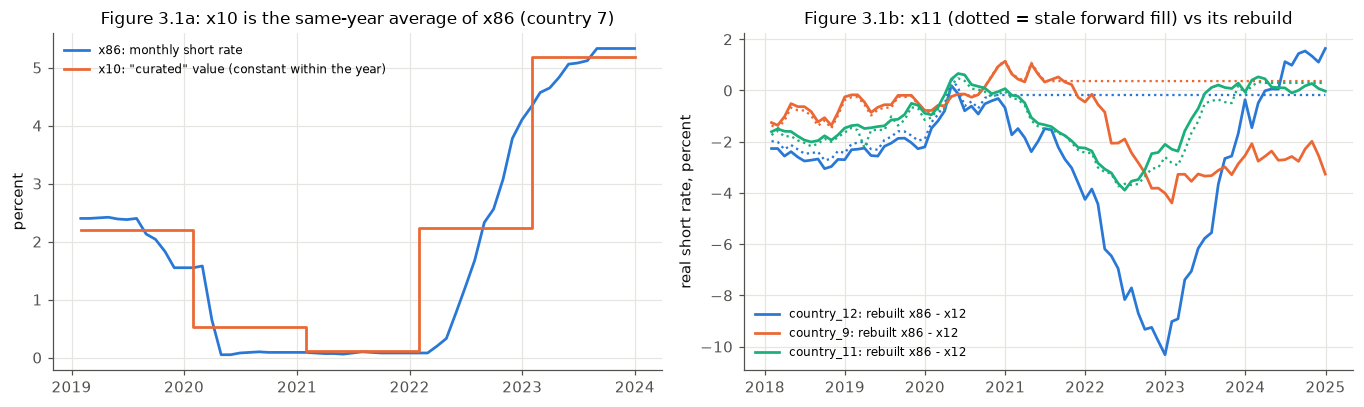

In [28]:
# ---------- Trap audit 2: x10 is a same-year average (look-ahead); x11 stops at a regime change ----------
cm = mac_c.merge(mac_x[['country', 'date', 'x86', 'x85']], on=['country', 'date'], validate='one_to_one')
cm['year'] = cm.date.dt.year
yr = cm.groupby(['country', 'year']).agg(x10=('x10', 'first'), x10_values=('x10', 'nunique'), same_year=('x86', 'mean'))
yr['prior_year'] = yr.groupby(level='country')['same_year'].shift(1)
ok = yr.dropna()
x10_tab = pd.Series({
    'x10 constant within each calendar year (share of country-years)': (yr.x10_values == 1).mean(),
    'x10 = same-year mean of x86 within 0.001 (share)': (np.abs(yr.x10 - yr.same_year) < 1e-3).mean(),
    'x10 within 0.10 of the same-year mean (share)': (np.abs(yr.x10 - yr.same_year) < 0.10).mean(),
    'corr(x10, same-year mean of x86)': ok.x10.corr(ok.same_year),
    'corr(x10, prior-year mean of x86)': ok.x10.corr(ok.prior_year),
    'x10 closer to the same-year than the prior-year mean (share)': (np.abs(ok.x10 - ok.same_year) < np.abs(ok.x10 - ok.prior_year)).mean()},
    name='value')
display(x10_tab.to_frame())
print('-> x10 in January already "knows" the rest of the year: a 1-month lag leaves up to 11 months of look-ahead.\n'
      '   The monthly short rate x86 (extended file) is used instead, at the same 2-month lag as every macro series.')

# x11: where it stops, and how well x86 - x12 rebuilds it
x11_stop = cm.groupby('country').apply(lambda d: pd.Series({
    'last non-missing': d.loc[d.x11.notna(), 'date'].max().date(), 'missing months': int(d.x11.isna().sum()),
    'interior holes': int(d.x11.isna().sum() - (d.date > d.loc[d.x11.notna(), 'date'].max()).sum())}), include_groups=False)
cm['x11_rebuild'] = cm.x86 - cm.x12
ov = cm.dropna(subset=['x11'])
rb = ov.groupby('country').apply(lambda d: pd.Series({'corr': d.x11.corr(d.x11_rebuild),
                                                      'RMSE': np.sqrt(((d.x11 - d.x11_rebuild) ** 2).mean())}), include_groups=False)
stale = []
for c in x11_stop.index[x11_stop['missing months'] > 0]:
    d = cm[cm.country == c].sort_values('date')
    after = d.x11.isna()
    err = (d.x11.ffill() - d.x11_rebuild)[after].abs()
    stale.append({'country': c, 'stale forward-fill error, mean (pp)': err.mean(), 'max (pp)': err.max()})
x11_tab = x11_stop.join(rb).join(pd.DataFrame(stale).set_index('country'))
display(x11_tab.loc[x11_stop['missing months'].sort_values(ascending=False).index])
print(f'pooled rebuild quality on the overlap: corr {ov.x11.corr(ov.x11_rebuild):.3f}, RMSE {np.sqrt(((ov.x11 - ov.x11_rebuild) ** 2).mean()):.3f}. '
      'x11 is not added as a column: x86 - x12 is an exact combination of two included series (L3 p.40).')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 3.8))
d7 = cm[(cm.country == 'country_7') & (cm.date >= '2019-01-01') & (cm.date <= '2023-12-31')]
ax1.plot(d7.date, d7.x86, color=C_BLUE, label='x86: monthly short rate')
ax1.step(d7.date, d7.x10, where='post', color=C_ORANGE, label='x10: "curated" value (constant within the year)')
ax1.set_title('Figure 3.1a: x10 is the same-year average of x86 (country 7)')
ax1.set_ylabel('percent')
ax1.legend(fontsize=8)
for c, col in zip(['country_12', 'country_9', 'country_11'], [C_BLUE, C_ORANGE, C_AQUA]):
    d = cm[(cm.country == c) & (cm.date >= '2018-01-01')].sort_values('date')
    ax2.plot(d.date, d.x11_rebuild, color=col, label=f'{c}: rebuilt x86 - x12')
    ax2.plot(d.date, d.x11.ffill(), color=col, linestyle=':', linewidth=1.5)
ax2.set_title('Figure 3.1b: x11 (dotted = stale forward fill) vs its rebuild')
ax2.set_ylabel('real short rate, percent')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [29]:
# ---------- Trap audit 3: the extended file (duplicates, hidden global series, frequencies, gaps) ----------
ext_cols = [c for c in mac_x.columns if c.startswith('x')]
cur_cols = [f'x{k}' for k in range(10, 17)]
mc, mx = mac_c.sort_values(['country', 'date']).reset_index(drop=True), mac_x.sort_values(['country', 'date']).reset_index(drop=True)
assert (mc[['country', 'date']].to_numpy() == mx[['country', 'date']].to_numpy()).all()     # rows align on keys
same = lambda a, b: bool(((a == b) | (a.isna() & b.isna())).all())
dups = [(c, e) for c in cur_cols for e in ext_cols if same(mc[c], mx[e])]
by_date = {e: mx.pivot(index='date', columns='country', values=e) for e in ext_cols}
hidden_global = [e for e in ext_cols if (by_date[e].nunique(axis=1, dropna=False) <= 1).all()]
glob_dups = [(g, e) for g in ['x6', 'x7', 'x8', 'x9'] for e in hidden_global if np.allclose(by_date[e].iloc[:, 0].to_numpy(), mac_g[g].to_numpy())]
def frequency(e):
    ch = by_date[e].diff().iloc[1:]
    months = set(ch.index[(ch.fillna(0) != 0).any(axis=1)].month)
    if not months: return 'constant'
    if months <= {1}: return 'annual (changes in January only)'
    if months <= {1, 4, 7, 10}: return 'quarterly'
    return 'monthly or irregular'
freq = pd.Series({e: frequency(e) for e in ext_cols})
gaps = [e for e in ext_cols if mx[e].isna().any()]
print(f'extended file: {len(ext_cols)} columns x{ext_cols[0][1:]}..{ext_cols[-1]}')
print('exact duplicates of curated columns (curated, extended):', dups)
print(f'{len(hidden_global)} columns identical across all 12 countries; exact copies of global series:', glob_dups)
print('frequency of the extended columns:', freq.value_counts().to_dict())
print('columns with gaps:', gaps)
print('-> the extended file is never concatenated or screened against returns; only x86 (the monthly short rate) is used.')

extended file: 148 columns x17..x164
exact duplicates of curated columns (curated, extended): [('x10', 'x73'), ('x12', 'x89'), ('x13', 'x114'), ('x14', 'x17'), ('x15', 'x92'), ('x16', 'x18')]
26 columns identical across all 12 countries; exact copies of global series: [('x6', 'x88'), ('x7', 'x104'), ('x8', 'x109'), ('x9', 'x99')]
frequency of the extended columns: {'monthly or irregular': 86, 'annual (changes in January only)': 35, 'quarterly': 26, 'constant': 1}
columns with gaps: ['x55', 'x82', 'x83', 'x113', 'x136', 'x163', 'x164']
-> the extended file is never concatenated or screened against returns; only x86 (the monthly short rate) is used.


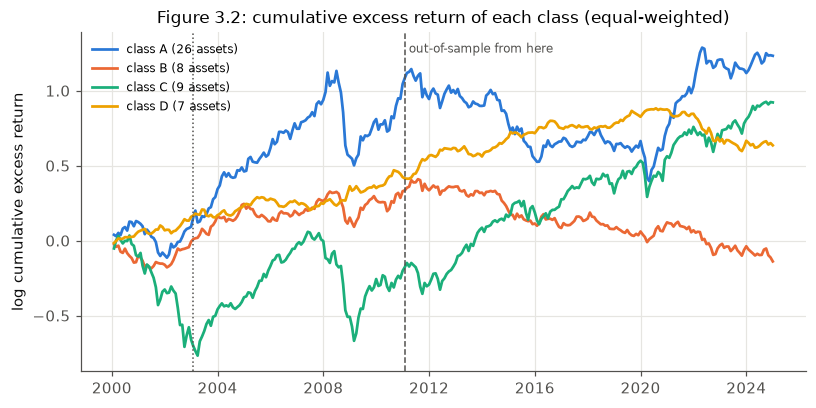

,assets,median ann. vol,min ann. vol,max ann. vol,median Sharpe,worst month
class,,,,,,
A,26,0.297,0.147,0.603,0.253,-0.547
B,8,0.097,0.085,0.122,-0.013,-0.163
C,9,0.176,0.136,0.200,0.239,-0.254
D,7,0.068,0.029,0.091,0.471,-0.121


,class,country,ann. mean,ann. vol,Sharpe (ann.),worst month,worst month date
asset_7,A,country_7,-0.050,0.301,-0.168,-0.252,2011-06
asset_47,A,country_7,-0.028,0.603,-0.046,-0.401,2001-01
asset_40,A,country_7,-0.005,0.316,-0.015,-0.236,2008-03
asset_13,A,country_7,-0.004,0.291,-0.012,-0.241,2011-06
asset_5,A,country_7,-0.001,0.202,-0.007,-0.169,2008-10
asset_18,A,country_7,-0.002,0.304,-0.007,-0.260,2002-08
asset_36,A,country_7,0.002,0.274,0.006,-0.228,2011-09
asset_14,A,country_7,0.015,0.293,0.052,-0.252,2022-06
asset_19,A,country_7,0.023,0.147,0.158,-0.211,2003-12
asset_26,A,country_7,0.049,0.269,0.182,-0.341,2008-10


monthly volatility ranges from 0.82% (asset_16) to 17.40% (asset_47)


In [30]:
# ---------- Returns: cumulative by class, per-asset table ----------
CLS_S = pd.Series(CLS, index=IDS)
class_ret = R.T.groupby(CLS_S).mean().T                   # equal-weighted class averages
fig, ax = plt.subplots(figsize=(8.5, 4))
for c in 'ABCD':
    ax.plot(class_ret.index, np.log((1 + class_ret[c]).cumprod()), color=CLASS_COL[c], label=f'class {c} ({(CLS == c).sum()} assets)')
ax.axvline(DATES[FIRST_M], color=C_GREY, linestyle=':', linewidth=1)
ax.axvline(DATES[OOS_M[0]], color=C_GREY, linestyle='--', linewidth=1)
ax.text(DATES[OOS_M[0]], ax.get_ylim()[1] * 0.95, ' out-of-sample from here', color=C_GREY, fontsize=8, va='top')
ax.set_ylabel('log cumulative excess return')
ax.set_title('Figure 3.2: cumulative excess return of each class (equal-weighted)')
ax.legend(fontsize=8, loc='upper left')
plt.show()

vol = R.std(ddof=1)
asset_tab = pd.DataFrame({'class': CLS, 'country': CTRY, 'ann. mean': 12 * R.mean(), 'ann. vol': np.sqrt(12) * vol,
                          'Sharpe (ann.)': np.sqrt(12) * R.mean() / vol, 'worst month': R.min(),
                          'worst month date': R.idxmin().dt.strftime('%Y-%m')}, index=IDS)
cls_summary = asset_tab.groupby('class').agg(assets=('country', 'size'), **{'median ann. vol': ('ann. vol', 'median'),
             'min ann. vol': ('ann. vol', 'min'), 'max ann. vol': ('ann. vol', 'max'), 'median Sharpe': ('Sharpe (ann.)', 'median'),
             'worst month': ('worst month', 'min')})
display(cls_summary.style.format('{:.3f}', subset=cls_summary.columns[1:]).set_caption('Table 3.1a: by class (monthly volatility x sqrt(12))'))
display(asset_tab.sort_values(['class', 'Sharpe (ann.)']).style.format({c: '{:.3f}' for c in ['ann. mean', 'ann. vol', 'Sharpe (ann.)', 'worst month']})
        .set_caption('Table 3.1b: every asset, 2000-2024'))
print(f'monthly volatility ranges from {vol.min():.2%} ({vol.idxmin()}) to {vol.max():.2%} ({vol.idxmax()})')

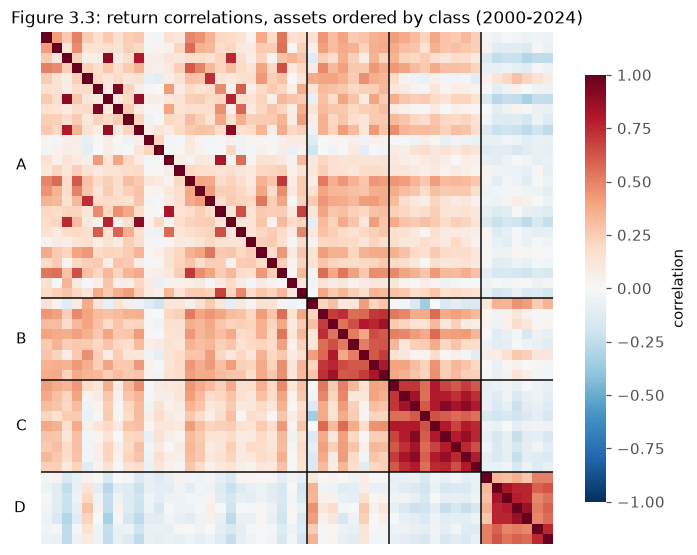

,A,B,C,D
A,0.21,0.24,0.18,-0.08
B,0.24,0.55,0.23,0.05
C,0.18,0.23,0.73,-0.10
D,-0.08,0.05,-0.10,0.58


,A,B,C,D
A,0.25,0.28,0.22,-0.09
B,0.28,0.52,0.26,0.00
C,0.22,0.26,0.76,-0.17
D,-0.09,0.00,-0.17,0.59


In [31]:
# ---------- Correlation matrix ordered by class, and its block structure ----------
order = sorted(IDS, key=lambda a: ('ABCD'.index(CLS_S[a]), int(a.split('_')[1])))
corr_full = R[order].corr()
fig, ax = plt.subplots(figsize=(7.5, 6.3))
sns.heatmap(corr_full, vmin=-1, vmax=1, center=0, cmap='RdBu_r', square=True, xticklabels=False, yticklabels=False,
            cbar_kws={'label': 'correlation', 'shrink': 0.8}, ax=ax)
edges = np.cumsum([(CLS == c).sum() for c in 'ABCD'])
for e in edges[:-1]:
    ax.axhline(e, color=C_INK, linewidth=1)
    ax.axvline(e, color=C_INK, linewidth=1)
for c, mid in zip('ABCD', edges - np.array([(CLS == c).sum() for c in 'ABCD']) / 2):
    ax.text(-1.5, mid, c, ha='right', va='center', fontsize=10)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Figure 3.3: return correlations, assets ordered by class (2000-2024)')
plt.show()

def block_table(C):
    """Mean off-diagonal correlation within and between classes."""
    out = pd.DataFrame(index=list('ABCD'), columns=list('ABCD'), dtype=float)
    for c1 in 'ABCD':
        for c2 in 'ABCD':
            b = C.loc[CLS_S.index[CLS_S == c1], CLS_S.index[CLS_S == c2]].to_numpy()
            out.loc[c1, c2] = b[~np.eye(len(b), dtype=bool)].mean() if c1 == c2 else b.mean()
    return out
display(block_table(corr_full).style.format('{:.2f}').set_caption('Table 3.2: average correlation within (diagonal) and between classes, 2000-2024'))
display(block_table(R.loc['2003-01-31':'2010-12-31'].corr()).style.format('{:.2f}').set_caption('Table 3.2 (training block 2003-2010)'))

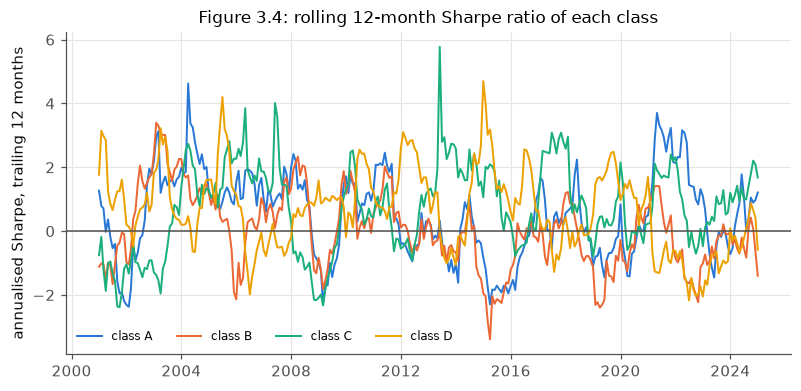

,A,B,C,D
"corr(Sharpe in year k, year k+1)",-0.06,0.14,-0.01,-0.10


In [32]:
# ---------- Rolling 12-month Sharpe by class, and how persistent performance is ----------
roll_sr = np.sqrt(12) * class_ret.rolling(12).mean() / class_ret.rolling(12).std(ddof=1)
fig, ax = plt.subplots(figsize=(8.5, 3.8))
for c in 'ABCD':
    ax.plot(roll_sr.index, roll_sr[c], color=CLASS_COL[c], linewidth=1.3, label=f'class {c}')
ax.axhline(0, color=C_GREY, linewidth=1)
ax.set_ylabel('annualised Sharpe, trailing 12 months')
ax.set_title('Figure 3.4: rolling 12-month Sharpe ratio of each class')
ax.legend(fontsize=8, ncol=4, loc='lower left')
plt.show()
yearly = class_ret.groupby(class_ret.index.year).apply(lambda d: np.sqrt(12) * d.mean() / d.std(ddof=1))
persist = pd.Series({c: yearly[c].corr(yearly[c].shift(-1)) for c in 'ABCD'}, name='corr(Sharpe in year k, year k+1)')
display(persist.to_frame().T.style.format('{:.2f}').set_caption('Table 3.3: persistence of calendar-year Sharpe ratios (24 non-overlapping pairs)'))

In [33]:
# ---------- Characteristics: scale, persistence, identities, and what each one measures ----------
LAGGED = {x: (X_CLEAN[x].shift(1) if x in ('x1', 'x3', 'x4') else X_CLEAN[x]) for x in XNAMES}   # known at the end of t-1
rows = []
for x in XNAMES:
    W = LAGGED[x].iloc[FIRST_M:]
    for c in 'ABCD':
        blk = W.loc[:, CLS == c]
        rows.append({'characteristic': x, 'class': c, 'mean': np.nanmean(blk), 'sd': np.nanstd(blk, ddof=1),
                     'p1': np.nanpercentile(blk, 1), 'p99': np.nanpercentile(blk, 99),
                     'AC(1) median': np.median([blk[a].autocorr(1) for a in blk]),
                     'AC(12) median': np.median([blk[a].autocorr(12) for a in blk]),
                     'cross-sectional sd (median month)': blk.std(axis=1, ddof=1).median()})
char_tab = pd.DataFrame(rows).set_index(['characteristic', 'class'])
display(char_tab.style.format('{:.3g}').set_caption('Table 3.4: forecast-aligned characteristics by class, 2003-2024'))

# identities: x2 is the compounded past 12-month return, x5 the past 36-month volatility (both already lagged)
R12 = np.expm1(np.log1p(R).rolling(12, min_periods=12).sum()).shift(1)
share_x2 = (np.abs(X_RAW['x2'] - R12).iloc[12:] < 1e-5).to_numpy().mean()
share_x5 = (np.abs(X_RAW['x5'] - SD36).iloc[FIRST_M:] < 1e-5).to_numpy().mean()
print(f'x2 = prod(1 + r[t-12..t-1]) - 1 within 1e-5 in {share_x2:.2%} of asset-months from 2001-01; '
      f'x5 = sd(r[t-36..t-1]) within 1e-5 in {share_x5:.2%} from 2003-01')
assert share_x2 > 0.99 and share_x5 > 0.99

# what the others track (predictor vs PAST returns and macro only, never the target)
R60 = np.log1p(R).rolling(60, min_periods=60).sum().shift(1)
def ts_corr(A, B, c):
    return np.nanmean([pd.concat([A[a], B[a]], axis=1).dropna().corr().iloc[0, 1] for a in np.array(IDS)[CLS == c]])
hyp = pd.DataFrame({c: {'x1 vs own 12m past return': ts_corr(LAGGED['x1'], R12, c),
                        'x3 vs own 60m past log return': ts_corr(LAGGED['x3'], R60, c),
                        'x4 vs own 12m past return': ts_corr(LAGGED['x4'], R12, c),
                        'x5 vs own 36m past vol': ts_corr(LAGGED['x5'], SD36, c)} for c in 'ABCD'})
rate_diff = cm.pivot(index='date', columns='country', values='x86')
rd = rate_diff.sub(rate_diff['country_7'], axis=0)
b_ids = np.array(IDS)[CLS == 'B']
x1_b = np.nanmean([X_RAW['x1'][a].corr(rd[info.loc[a, 'country']]) for a in b_ids])
x4_b = np.nanmean([X_RAW['x4'][a].corr(rd[info.loc[a, 'country']].diff(12)) for a in b_ids])
display(hyp.style.format('{:.2f}').set_caption('Table 3.5: average within-asset correlation with past returns, by class'))
print(f'class B: corr(x1, short-rate differential vs country 7) = {x1_b:.2f}; corr(x4, its 12-month change) = {x4_b:.2f}')
print('Hypotheses: x1 carry (rate differential / yield), x2 12-month momentum, x3 value / 5-year reversal,\n'
      '            x4 12-month change in the carry fundamental, x5 36-month volatility (the risk measure).')

x2 = prod(1 + r[t-12..t-1]) - 1 within 1e-5 in 99.63% of asset-months from 2001-01; x5 = sd(r[t-36..t-1]) within 1e-5 in 99.67% from 2003-01


,A,B,C,D
x1 vs own 12m past return,0.28,0.37,-0.03,0.39
x3 vs own 60m past log return,-0.93,-0.98,-0.45,-0.97
x4 vs own 12m past return,0.27,0.16,-0.60,-0.15
x5 vs own 36m past vol,1.00,1.00,1.00,1.00


class B: corr(x1, short-rate differential vs country 7) = 0.93; corr(x4, its 12-month change) = 1.00
Hypotheses: x1 carry (rate differential / yield), x2 12-month momentum, x3 value / 5-year reversal,
            x4 12-month change in the carry fundamental, x5 36-month volatility (the risk measure).


In [34]:
# ---------- A first look at predictive content: tercile sorts, TRAINING BLOCK ONLY (2003-2010) ----------
Y = R / SD36                                              # the vol-scaled target, defined from 2003-01
sort_months = range(FIRST_M, INIT_END_M + 1)
assert DATES[max(sort_months)] <= pd.Timestamp('2010-12-31')        # no out-of-sample return is used here
rows, terc_rows = [], {}
for x in XNAMES:
    spreads = {c: [] for c in 'ABCD'}
    levels_x = []
    for m in sort_months:
        for c in 'ABCD':
            cols = np.flatnonzero(CLS == c)
            v = LAGGED[x].iloc[m, cols].to_numpy()
            yy = Y.iloc[m, cols].to_numpy()
            k = len(cols) // 3
            o = np.argsort(v, kind='stable')               # ties broken by asset order
            spreads[c].append(yy[o[-k:]].mean() - yy[o[:k]].mean())
            levels_x.append([yy[o[:k]].mean(), yy[o[k:-k]].mean(), yy[o[-k:]].mean()])
    terc_rows[x] = dict(zip(['bottom', 'middle', 'top'], np.mean(levels_x, axis=0)))
    sp = pd.DataFrame(spreads)
    sp['all classes'] = sp.mean(axis=1)
    for col in sp:
        s = sp[col]
        rows.append({'characteristic': x, 'class': col, 'top minus bottom tercile, mean y': s.mean(),
                     't': s.mean() / (s.std(ddof=1) / np.sqrt(len(s)))})
sorts = pd.DataFrame(rows).pivot(index='characteristic', columns='class', values=['top minus bottom tercile, mean y', 't'])
display(sorts.style.format('{:.2f}').set_caption(f'Table 3.6: tercile spreads of next-month vol-scaled return, 2003-2010 ({len(sort_months)} months)'))
display(pd.DataFrame(terc_rows).T.style.format('{:.3f}')
        .set_caption('Table 3.6b: average next-month y in each within-class tercile, 2003-2010 (mean over classes and months)'))
print(f'critical |t|: {stats.t.ppf(0.975, len(sort_months) - 1):.2f} for one test, '
      f'{stats.t.ppf(1 - 0.025 / 25, len(sort_months) - 1):.2f} for the best of these 25 (Bonferroni; L4 p.27-28). '
      'No characteristic is dropped or re-signed because of this table.')

,bottom,middle,top
x1,0.096,0.139,0.158
x2,0.141,0.136,0.121
x3,0.079,0.169,0.132
x4,0.091,0.141,0.166
x5,0.160,0.134,0.109


critical |t|: 1.99 for one test, 3.18 for the best of these 25 (Bonferroni; L4 p.27-28). No characteristic is dropped or re-signed because of this table.


## 3.2 Feature engineering

One function, `build_features`, turns the raw files into every predictor for every (month, asset). A value in the row for target month $t$ uses only information available at the end of month $t-1$. Because the whole construction is a single function of the raw files, three things run through the same code:
- the causality test (rebuild from data truncated at 2010-12; nothing up to 2010-12 may change);
- the placebo (macro circularly shifted in time);
- the `x10` variants.

| block | construction | why |
|---|---|---|
| lags | `x2`, `x5` as stored (already lagged); `x1`, `x3`, `x4` shifted 1 month within asset; every macro series shifted **2 months** (1 month minimum plus release delay; 1 month as robustness) | the exam's Data section; merge on publication date, not period end (L5 p.58 item 2) |
| characteristics `u1..u5` | rank within asset class and month, scaled to [−0.5, 0.5] | Units differ by up to 3 orders of magnitude across classes. Ranks are bounded, so no single extreme value can dominate a least-squares fit (L3 p.12–18 shows how far one point can move one). They have no parameters fitted over time, so they cannot leak (L5 p.58). Within-class z-score as robustness (our choice). |
| levels `l1..l5` (secondary) | each asset's own lagged characteristic as a trailing 60-month z-score | Ranks can only compare assets within a month. This gives the characteristics a time-series channel, so macro is not the only source of timing. |
| global macro | log `x6`; trailing 60-month z-score (at least 24 months), then lag; **one slope per class** | "trailing information only" (the exam's suggested workflow); interactions (L3 p.53–54) |
| country macro | `x86` (extended; replaces the look-ahead `x10`), `x12`, `x13`, log `x14`, log `x15`, `x16`: each as the **differential vs country 7**, then a **trailing 60-month z-score per country**, then lag. Enters × class for B, C, D. **Class A gets none.** | Differential vs the natural base (the exam's suggested workflow). The trailing z-score removes static country gaps, so a fixed asset premium cannot pose as macro. Class A has no natural country (the exam's Data section). |
| class intercepts | left **unpenalised**: linear models are fit on within-class demeaned data | ridge penalises slopes, not the intercept (L5 p.12); class intercepts (L3 p.50) |

In [35]:
CHARS = ['u1', 'u2', 'u3', 'u4', 'u5']
LEVELS = ['l1', 'l2', 'l3', 'l4', 'l5']
G_SER = ['x6', 'x7', 'x8', 'x9']
C_SER = [('x86', 'extended', False), ('x12', 'curated', False), ('x13', 'curated', False),
         ('x14', 'curated', True), ('x15', 'curated', True), ('x16', 'curated', False)]   # (series, file, take logs)
COUNTRIES = [f'country_{k}' for k in range(1, 13)]
C_IDX = np.array([COUNTRIES.index(c) for c in CTRY])                  # each asset's country column

def trailing_z(W, window=60, min_periods=24):
    """z-score of each value against the trailing window that ends at it (past and present only)."""
    sd = W.rolling(window, min_periods=min_periods).std(ddof=1)
    return (W - W.rolling(window, min_periods=min_periods).mean()) / sd.where(sd > 1e-12)

def build_features(pan, mg, mc, mx, macro_lag=MACRO_LAG, char_std='rank', short_rate='x86', sr_lag=None, shift=0):
    """Every predictor for every (month, asset), known at the end of month t-1, from the raw files only.
    shift > 0 circularly shifts every raw macro series by `shift` months first (the placebo)."""
    dates = pd.DatetimeIndex(np.sort(pan.date.unique()))
    T, N = len(dates), len(IDS)
    Rw = pan.pivot(index='date', columns='asset_id', values='excess_return')[IDS]
    sig = Rw.rolling(36, min_periods=36).std(ddof=1).shift(1)          # sigma-hat_{t-1} from r_{t-36..t-1}
    lagged = {}
    for x in XNAMES:
        W = pan.pivot(index='date', columns='asset_id', values=x)[IDS].copy()
        if x in ('x2', 'x3', 'x5'):                                     # back-filled leading cells -> missing
            for j in range(N):
                k = leading_copies(W.iloc[:, j].to_numpy())
                if k:
                    W.iloc[:k, j] = np.nan
        lagged[x] = W.shift(1) if x in ('x1', 'x3', 'x4') else W       # x2 and x5 are stored already lagged
    feats = {}
    for x, name in zip(XNAMES, CHARS):                                  # within-class, within-month standardisation
        out = pd.DataFrame(np.nan, index=dates, columns=IDS)
        for c in 'ABCD':
            cols = [a for a, k in zip(IDS, CLS) if k == c]
            B = lagged[x][cols]
            if char_std == 'rank':
                out[cols] = (B.rank(axis=1, method='average') - 1) / (len(cols) - 1) - 0.5
            else:
                out[cols] = B.sub(B.mean(axis=1), axis=0).div(B.std(axis=1, ddof=1), axis=0).clip(-3, 3)
        feats[name] = out.to_numpy()
    for x, name in zip(XNAMES, LEVELS):                                 # own-history levels (0 until 24 months exist)
        feats[name] = trailing_z(lagged[x]).fillna(0).clip(-5, 5).to_numpy()

    roll = (lambda A: np.roll(A, shift, axis=0)) if shift else (lambda A: A)
    G = mg.set_index('date')[G_SER].copy()
    G['x6'] = np.log(G['x6'])
    G = pd.DataFrame(roll(G.to_numpy()), index=G.index, columns=G_SER)
    GZ = trailing_z(G).shift(macro_lag)
    CZ = {}
    for ser, src, take_log in C_SER:
        name, lag = ser, macro_lag
        if ser == 'x86' and short_rate == 'x10':                        # curated-file variant (and its leak demo)
            ser, src, lag = 'x10', 'curated', sr_lag
        P = (mx if src == 'extended' else mc).pivot(index='date', columns='country', values=ser)[COUNTRIES]
        P = np.log(P) if take_log else P
        P = pd.DataFrame(roll(P.to_numpy()), index=P.index, columns=COUNTRIES)
        D = P.sub(P['country_7'], axis=0)                               # differential vs country 7
        Z = trailing_z(D)
        Z['country_7'] = 0.0                                            # country 7 has no differential
        CZ[name] = Z.shift(lag)

    F = pd.DataFrame({'date': np.repeat(dates, N), 'm': np.repeat(np.arange(T), N), 'asset_id': np.tile(IDS, T),
                      'cls': np.tile(CLS, T), 'country': np.tile(CTRY, T),
                      'r': Rw.to_numpy().ravel(), 'sig': sig.to_numpy().ravel()})
    F['y'] = F.r / F.sig
    for name, A in feats.items():
        F[name] = A.ravel()
    for c in 'BCD':
        F['d' + c] = (F.cls == c).astype(float)
    for k in G_SER:
        F['g_' + k] = np.repeat(GZ[k].to_numpy(), N)
        for c in 'ABCD':
            F[f'g_{k}_{c}'] = F['g_' + k] * (F.cls == c)
    for k, _, _ in C_SER:
        F['c_' + k] = CZ[k].to_numpy()[:, C_IDX].ravel()
        F.loc[F.cls == 'A', 'c_' + k] = 0.0                             # class A: no country macro
        for c in 'BCD':
            F[f'c_{k}_{c}'] = F['c_' + k] * (F.cls == c)
    F = F[F.m >= FIRST_M].reset_index(drop=True)
    if short_rate == 'x10' and sr_lag and sr_lag > 12:
        # x10 at a 14-month lag first has a 24-month trailing z for target 2003-02; the 50 rows of 2003-01 get 0,
        # the neutral value (a fixed constant, not an estimate), in this sensitivity variant only
        xcols = [c for c in F if c.startswith('c_x86')]
        F[xcols] = F[xcols].fillna(0.0)
    return F, {'lagged': lagged, 'GZ': GZ, 'CZ': CZ, 'G': G}

GLOB = [f'g_{k}_{c}' for k in G_SER for c in 'ABCD']
CTRY_INT = [f'c_{k}_{c}' for k, _, _ in C_SER for c in 'BCD']
FSETS = {'M1': [], 'M2': CHARS, 'M3': CHARS + GLOB + CTRY_INT, 'M3-global': CHARS + GLOB, 'M3-country': CHARS + CTRY_INT,
         'M2-levels': CHARS + LEVELS, 'M3-levels': CHARS + GLOB + CTRY_INT + LEVELS}
RF_SETS = {'M2': CHARS + ['dB', 'dC', 'dD'],
           'M3': CHARS + ['dB', 'dC', 'dD'] + ['g_' + k for k in G_SER] + ['c_' + k for k, _, _ in C_SER]}

In [36]:
t0 = time.perf_counter()
F, AUX = build_features(panel, mac_g, mac_c, mac_x)
print(f'feature frame: {F.shape[0]:,} rows ({F.m.nunique()} target months x {F.asset_id.nunique()} assets), built in {time.perf_counter() - t0:.1f} s')
model_cols = sorted(set(sum(FSETS.values(), []) + sum(RF_SETS.values(), [])))
assert len(F) == 264 * 50 and F[model_cols + ['y', 'sig']].notna().all().all(), 'a predictor is missing somewhere'
assert (F.groupby(['m', 'cls'])[CHARS].sum().abs() < 1e-12).all().all()          # ranks sum to zero in every class-month
assert F.loc[F.cls == 'A', [c for c in F if c.startswith('c_')]].eq(0).all().all()

# Table 3.7: every predictor and the count (the exam's suggested workflow)
pred_tab = pd.DataFrame([
    ['characteristics', 'u1..u5', 'x1 (lag 1), x2 (as stored), x3 (lag 1), x4 (lag 1), x5 (as stored) -> rank within class and month', 'all', 5],
    ['class intercepts', 'A (reference), dB, dC, dD', 'asset_info; unpenalised', 'all', 3],
    ['global macro x class', 'g_x6..g_x9 x {A,B,C,D}', 'log x6, x7, x8, x9 -> trailing 60m z -> lag 2', 'all', len(GLOB)],
    ['country macro x class', '{x86, x12, x13, log x14, log x15, x16} x {B,C,D}', 'minus country 7 -> trailing 60m z per country -> lag 2', 'B, C, D', len(CTRY_INT)],
    ['levels (secondary only)', 'l1..l5', "each asset's own lagged characteristic -> trailing 60m z", 'all', 5],
    ['target', 'y', 'excess return / 36m SD of own past excess returns', 'all', 1]],
    columns=['block', 'columns', 'source -> transform -> lag', 'classes', 'count']).set_index('block')
display(pred_tab.style.set_caption('Table 3.7: predictors'))
display(pd.Series({k: len(v) + 3 for k, v in FSETS.items()}, name='columns incl. the 3 class intercepts').to_frame().T)
print('Not used: x10/x73 (same-year average: look-ahead), stored x11 (gaps; its rebuild x86 - x12 is spanned),'
      ' every other extended column (duplicates, hidden global copies, annual/quarterly series whose publication timing is unknown, gaps).')

feature frame: 13,200 rows (264 target months x 50 assets), built in 0.2 s


,columns,source -> transform -> lag,classes,count
block,,,,
characteristics,u1..u5,"x1 (lag 1), x2 (as stored), x3 (lag 1), x4 (lag 1), x5 (as stored) -> rank within class and month",all,5
class intercepts,"A (reference), dB, dC, dD",asset_info; unpenalised,all,3
global macro x class,"g_x6..g_x9 x {A,B,C,D}","log x6, x7, x8, x9 -> trailing 60m z -> lag 2",all,16
country macro x class,"{x86, x12, x13, log x14, log x15, x16} x {B,C,D}",minus country 7 -> trailing 60m z per country -> lag 2,"B, C, D",18
levels (secondary only),l1..l5,each asset's own lagged characteristic -> trailing 60m z,all,5
target,y,excess return / 36m SD of own past excess returns,all,1


,M1,M2,M3,M3-global,M3-country,M2-levels,M3-levels
columns incl. the 3 class intercepts,3,8,42,24,26,13,47


Not used: x10/x73 (same-year average: look-ahead), stored x11 (gaps; its rebuild x86 - x12 is spanned), every other extended column (duplicates, hidden global copies, annual/quarterly series whose publication timing is unknown, gaps).


In [37]:
# ---------- Checks that the features only use the past ----------
# (1) Lag spot checks at 20 random (asset, month) pairs, against the raw files
rng_chk = np.random.default_rng(P3_SEED)
G_raw = mac_g.set_index('date')[G_SER].assign(x6=lambda d: np.log(d.x6))
D86 = cm.pivot(index='date', columns='country', values='x86')[COUNTRIES]
D86 = D86.sub(D86['country_7'], axis=0)
for _ in range(20):
    i = rng_chk.integers(len(F))
    m, a = F.m[i], F.asset_id[i]
    j = IDS.index(a)
    assert AUX['lagged']['x1'].iloc[m, j] == X_RAW['x1'].iloc[m - 1, j]          # x1 from month t-1
    assert AUX['lagged']['x2'].iloc[m, j] == X_RAW['x2'].iloc[m, j]              # x2 as stored (pre-lagged)
    assert np.isclose(F.g_x6[i], trailing_z(G_raw)['x6'].iloc[m - 2])            # global macro from month t-2
    if F.cls[i] != 'A' and F.country[i] != 'country_7':
        assert np.isclose(F.c_x86[i], trailing_z(D86)[F.country[i]].iloc[m - 2])  # country macro from month t-2
    assert np.isclose(F.sig[i], R.iloc[m - 36:m, j].std(ddof=1))                 # sigma-hat from r_{t-36..t-1}
print('20 lag spot checks passed')

# (2) Causality test: rebuild from raw data truncated at 2010-12; no feature up to 2010-12 may change
cut = pd.Timestamp('2010-12-31')
F_cut, _ = build_features(panel[panel.date <= cut], mac_g[mac_g.date <= cut], mac_c[mac_c.date <= cut], mac_x[mac_x.date <= cut])
chk = model_cols + ['y', 'sig'] + LEVELS
same_rows = F[F.date <= cut].reset_index(drop=True)
assert len(F_cut) == len(same_rows) and np.allclose(F_cut[chk].to_numpy(), same_rows[chk].to_numpy(), rtol=0, atol=1e-12)
print(f'causality test passed: all {len(chk)} feature columns for the {len(F_cut):,} rows up to {cut.date()} are identical '
      'when every later observation is deleted')

20 lag spot checks passed


causality test passed: all 64 feature columns for the 4,800 rows up to 2010-12-31 are identical when every later observation is deleted


## 3.3 Benchmarks first

Rule 1 of the exam's "Two rules that apply throughout" says to compute the simple rules before fitting anything. This section does that: it contains no model code, and its numbers are printed before any model exists in the notebook.

**Forecast benchmarks** for the target $y$ in month $t$. Every one uses data through $t-1$ only and is updated monthly (the expanding harness of HW5 Problem 1.1):
- the **pooled trailing mean** over all assets, the primary benchmark;
- the per-class trailing mean and the per-asset trailing mean;
- zero.

For raw returns, the literal benchmark of that rule is the per-asset trailing mean of the excess return.

$$R^2_{OOS}=1-\frac{\sum (y-\hat y)^2}{\sum (y-\bar y^{\,bench})^2}\qquad\text{(L5 p.55–57; never `r2_score`, which uses the test mean: AI guide §4d)}$$

**Portfolio benchmarks**, all at unit gross exposure and rebalanced monthly [EXAM-DEFINED, rule 1]:
- EW: $w_i = 1/50$;
- RP: $w_i\propto 1/\hat\sigma_{i,t-1}$;
- TSMOM: $w_i\propto \mathrm{sign}(R_{12,i,t-1})/\hat\sigma_{i,t-1}$, where $R_{12}$ is the compounded return over $t-12..t-1$.

$\hat\sigma$ is the same 36-month volatility used for the target.

**Performance measures.** The lectures define none of these, so the formulas are stated here:
- Sharpe ratio: $\sqrt{12}\,\text{mean}/\text{sd}$ of monthly excess returns;
- maximum drawdown of cumulative wealth $\prod(1+r)$;
- turnover: $\sum_i |w_{i,t}-w^{\text{drift}}_{i,t}|$, the traded notional (buys plus sells) against the weights after last month's drift. The cost is charged per unit of this sum. Where "one-way turnover" is defined as half of it, our 10 bp equals 20 bp per unit of one-way turnover, so the costs here are conservative;
- net return = gross − c × turnover.

The first OOS month's initial build is excluded from turnover for every strategy.

In [38]:
# ---------- Forecast benchmarks (data through t-1 only) ----------
mon = F.groupby('m').y.agg(['sum', 'count'])
b_pool = (mon['sum'].cumsum() / mon['count'].cumsum()).shift(1)                       # pooled trailing mean, one value per month
cls_mon = F.groupby(['cls', 'm']).y.agg(['sum', 'count'])
b_cls = (cls_mon.groupby(level='cls').cumsum().pipe(lambda d: d['sum'] / d['count'])
         .groupby(level='cls').shift(1))                                            # per-class trailing mean
F['b_pool'] = F.m.map(b_pool)
F = F.merge(b_cls.rename('b_class').reset_index(), on=['cls', 'm'], how='left', validate='many_to_one')
F['b_asset'] = F.groupby('asset_id').y.transform(lambda v: v.expanding().mean().shift(1))
R_mean_raw = R.expanding().mean().shift(1)                                          # raw returns: per-asset trailing mean, from 2000-01
F['rb_asset'] = R_mean_raw.to_numpy()[F.m.to_numpy(), [IDS.index(a) for a in F.asset_id]]
# unit test of the primary benchmark against a brute-force mean
assert np.isclose(b_pool[OOS_M[0]], F.loc[(F.m >= FIRST_M) & (F.m < OOS_M[0]), 'y'].mean())
assert np.isclose(F.loc[(F.m == 150) & (F.asset_id == 'asset_9'), 'b_asset'].iloc[0],
                  F.loc[(F.m < 150) & (F.asset_id == 'asset_9'), 'y'].mean())

OOS = F[F.m >= OOS_M[0]].reset_index(drop=True)                                     # the 8,400 out-of-sample rows
assert len(OOS) == 8400 and OOS[['b_pool', 'b_class', 'b_asset', 'rb_asset']].notna().all().all()

def r2_oos(y, yhat, bench):
    """Out-of-sample R2 against a benchmark fixed before each forecast month (L5 p.55-57)."""
    y, yhat, bench = map(np.asarray, (y, yhat, bench))
    assert y.shape == yhat.shape == bench.shape and np.isfinite(yhat).all() and np.isfinite(bench).all()
    return 1 - ((y - yhat) ** 2).sum() / ((y - bench) ** 2).sum()

# How hard is each benchmark to beat? Each forecast scored against the others, before any model exists
cands = {'pooled trailing mean': OOS.b_pool, 'per-class trailing mean': OOS.b_class,
         'per-asset trailing mean': OOS.b_asset, 'zero': np.zeros(len(OOS))}
bench_tab = pd.DataFrame({f'vs {bn}': {fn: r2_oos(OOS.y, f, b) for fn, f in cands.items()}
                          for bn, b in [('pooled trailing mean', OOS.b_pool), ('zero', np.zeros(len(OOS)))]})
for c in 'ABCD':
    k = OOS.cls == c
    bench_tab[f'class {c}: vs pooled'] = [r2_oos(OOS.y[k], np.asarray(f)[k], OOS.b_pool[k]) for f in cands.values()]
display(bench_tab.style.format('{:.2%}').set_caption('Table 3.8: the benchmarks scored against each other, y, 2011-2024 (R2_OOS)'))
print(f'mean of y: training block {F.loc[F.m <= INIT_END_M, "y"].mean():.4f}, OOS {OOS.y.mean():.4f}; sd of y (OOS) {OOS.y.std(ddof=1):.3f}')

,vs pooled trailing mean,vs zero,class A: vs pooled,class B: vs pooled,class C: vs pooled,class D: vs pooled
pooled trailing mean,0.00%,-0.32%,0.00%,0.00%,0.00%,0.00%
per-class trailing mean,0.17%,-0.15%,0.05%,1.98%,-0.01%,-0.98%
per-asset trailing mean,-0.27%,-0.60%,-0.64%,1.79%,-0.21%,-1.10%
zero,0.32%,0.00%,0.66%,3.06%,-2.02%,-0.98%


mean of y: training block 0.1371, OOS 0.0362; sd of y (OOS) 1.043


In [39]:
# ---------- Portfolio machinery and the three benchmark portfolios (built from excess_return alone) ----------
SIG_W = SD36                                            # sigma-hat_{t-1}, the same as in the target (date x asset)
R12_W = R12                                             # compounded return over t-12..t-1

def unit_gross(W):
    """Scale each month's weights so that the sum of |w| is 1 (a month with no signal holds cash)."""
    g = W.abs().sum(axis=1)
    return W.div(g.where(g > 1e-12), axis=0).fillna(0.0)

def port_ret(W):
    return (W * R.loc[W.index, W.columns]).sum(axis=1)

def turnover(W):
    """One-way traded notional: this month's weights against last month's weights after they drifted."""
    Rs = R.loc[W.index, W.columns]
    Rp = (W * Rs).sum(axis=1)
    drift = (W.shift(1) * (1 + Rs.shift(1))).div(1 + Rp.shift(1), axis=0)
    return (W - drift.fillna(0.0)).abs().sum(axis=1)

def perf(ret, to, months, cost_bp=0.0):
    """Performance over a set of months; the first month's build is excluded from turnover and costs."""
    idx = DATES[months]
    tt = to.loc[idx].copy()
    tt.iloc[0] = 0.0
    r = ret.loc[idx] - cost_bp / 1e4 * tt
    wealth = (1 + r).cumprod()
    return {'ann. mean': 12 * r.mean(), 'ann. vol': np.sqrt(12) * r.std(ddof=1), 'Sharpe': np.sqrt(12) * r.mean() / r.std(ddof=1),
            'max drawdown': (1 - wealth / wealth.cummax()).max(), 'worst month': r.min(), 'turnover / month': tt.iloc[1:].mean()}

def weights_from_forecast(YH, rule='P1'):
    """Positions from forecasts of y (date x asset): P1 ~ yhat / sigma; P3 ~ (yhat - class mean) / sigma."""
    if rule == 'P1':
        return unit_gross(YH / SIG_W.loc[YH.index, YH.columns])
    if rule == 'P3':
        dev = YH - YH.T.groupby(CLS_S[YH.columns]).transform('mean').T
        return unit_gross(dev / SIG_W.loc[YH.index, YH.columns])
    raise ValueError(rule)

bench_idx = DATES[FIRST_M:]
W_EW = pd.DataFrame(1.0 / len(IDS), index=bench_idx, columns=IDS)
W_RP = unit_gross(1.0 / SIG_W.loc[bench_idx])
W_TS = unit_gross(np.sign(R12_W.loc[bench_idx]) / SIG_W.loc[bench_idx])
BENCH_W = {'EW': W_EW, 'RP': W_RP, 'TSMOM': W_TS}
for W in BENCH_W.values():
    assert np.allclose(W.abs().sum(axis=1), 1)
# identity: P1 with a constant forecast is exactly risk parity
assert np.allclose(weights_from_forecast(pd.DataFrame(1.0, index=bench_idx, columns=IDS)), W_RP, atol=1e-12)
# causality: weights up to 2010-12 are unchanged when every later return is deleted
Rc = R.loc[:'2010-12-31']
W_RP_cut = unit_gross(1.0 / Rc.rolling(36, min_periods=36).std(ddof=1).shift(1).loc[DATES[FIRST_M]:])
W_TS_cut = unit_gross(np.sign(np.expm1(np.log1p(Rc).rolling(12, min_periods=12).sum()).shift(1)).loc[DATES[FIRST_M]:]
                      / Rc.rolling(36, min_periods=36).std(ddof=1).shift(1).loc[DATES[FIRST_M]:])
assert np.allclose(W_RP_cut, W_RP.loc[:'2010-12-31']) and np.allclose(W_TS_cut, W_TS.loc[:'2010-12-31'])
BENCH_RET = {k: port_ret(W) for k, W in BENCH_W.items()}
BENCH_TO = {k: turnover(W) for k, W in BENCH_W.items()}

rows = {}
for k in BENCH_W:
    rows[(k, 'OOS 2011-2024, gross')] = perf(BENCH_RET[k], BENCH_TO[k], OOS_M)
    rows[(k, f'OOS 2011-2024, net {HEADLINE_BP} bp')] = perf(BENCH_RET[k], BENCH_TO[k], OOS_M, HEADLINE_BP)
    rows[(k, 'context 2003-2010, gross')] = perf(BENCH_RET[k], BENCH_TO[k], np.arange(FIRST_M, INIT_END_M + 1))
bench_perf = pd.DataFrame(rows).T
display(bench_perf.style.format({c: '{:.3f}' for c in bench_perf.columns}).set_caption('Table 3.9: the three benchmark portfolios'))
share = pd.DataFrame({k: W.loc[DATES[OOS_M]].abs().T.groupby(CLS_S).sum().T.mean() for k, W in BENCH_W.items()}).T
share['largest single weight'] = [W.loc[DATES[OOS_M]].abs().max().max() for W in BENCH_W.values()]
share['asset_16 average weight'] = [W.loc[DATES[OOS_M], 'asset_16'].abs().mean() for W in BENCH_W.values()]
display(share.style.format('{:.3f}').set_caption('Table 3.9b: where the benchmark portfolios put their gross exposure, 2011-2024'))

,A,B,C,D,largest single weight,asset_16 average weight
EW,0.520,0.160,0.180,0.140,0.020,0.020
RP,0.258,0.215,0.154,0.373,0.244,0.133
TSMOM,0.258,0.215,0.154,0.373,0.244,0.133


## 3.4 Models and the evaluation harness

**One splitter, and it only moves forward in time.**
- `window(scheme, b)` gives the training months for a model refit in December of year $b$.
- `inner_folds` cuts that window into three annual train/validation pairs.
- Test months always come after every training month; this is asserted in every fold (L5 p.48–52).
- No shuffled split, `KFold`, `TimeSeriesSplit` or `*CV` estimator appears anywhere in Problem 3 (AI guide §4a; L5 p.58–59).

**Linear models** (OLS, ridge, lasso, PCR) are fit in the same way:
1. Demean $y$ and $X$ within asset class on the *fit rows*, so the class intercepts are unpenalised. This equals ridge with unpenalised class dummies, checked below.
2. Standardise with a `StandardScaler` fitted on the fit rows only (AI guide §4b; L5 p.23, p.47).
3. Compute the whole coefficient path over the tuning grid:
   - ridge: closed form, L5 p.12;
   - lasso: `lasso_path`, as L5 p.47 recommends;
   - PCR: principal components of the fit rows (PCA, L1 p.45–74), then OLS on the first K. The lectures teach PCA and OLS; combining them into a regression on the components is our construction.

**Tuning.** The winning grid value has the lowest mean MSE over the three validation folds; a tie goes to the heavier penalty (L5 p.25, p.35). The model is then refit on the whole window. The test months play no part in the choice (L5 p.52).

**Random forest.** 300 trees, a third of the inputs tried at each split (L8 p.43), minimum leaf 200 observations, untuned (L8 p.44–45, p.55). **The leaf of 200 departs from L8 p.44, where the forest's trees are grown deep.** It is our choice for a signal this weak. The deep version (leaf 5) is an extra that tests the choice.

**Uncertainty.** The 168 OOS months are resampled with replacement; each month keeps its whole cross-section, because all assets share a month's shocks. The standard error of $R^2_{OOS}$ is the SD across 10,000 resamples, and results are reported as estimate ± 2 SE (L2 p.80, p.85). The lectures bootstrap single observations; resampling whole months is our construction. The same resampled months are used for every model, so differences between models are paired.

In [40]:
from sklearn.linear_model import lasso_path
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

CODE = {'A': 0, 'B': 1, 'C': 2, 'D': 3}
F['k'] = F.cls.map(CODE).astype(int)

def window(scheme, b):
    """Training months [a, b] for a model refit at month b."""
    if scheme == 'static':
        return FIRST_M, INIT_END_M
    if scheme == 'expanding':
        return FIRST_M, b
    if scheme == 'rolling':
        return b - ROLL_LEN + 1, b
    raise ValueError(scheme)

def inner_folds(a, b):
    """Three annual validation folds inside [a, b]: fit on a..b-12j, validate on the next 12 months (j = 3, 2, 1)."""
    return [((a, b - 12 * j), (b - 12 * j + 1, b - 12 * j + 12)) for j in (3, 2, 1)]

class LinearFE:
    """Linear model with unpenalised class intercepts. On the fit rows: demean y and X within class, standardise,
    then compute the coefficient path over `grid` (ridge: alpha/n; lasso: sklearn alpha; pcr: number of components)."""
    def __init__(self, kind, grid):
        self.kind, self.grid = kind, list(grid)

    def fit(self, X, y, k):
        self.xm = np.vstack([X[k == c].mean(0) if (k == c).any() else np.full(X.shape[1], np.nan) for c in range(4)])
        self.ym = np.array([y[k == c].mean() if (k == c).any() else np.nan for c in range(4)])
        yd = y - self.ym[k]
        if X.shape[1] == 0:                                     # M1: class means only
            self.coefs = np.zeros((0, len(self.grid)))
            return self
        Xd = X - self.xm[k]
        self.sc = StandardScaler().fit(Xd)                       # fitted on the fit rows only
        assert self.sc.n_samples_seen_ == len(Xd)
        Xs, n = self.sc.transform(Xd), len(yd)
        if self.kind == 'ols':
            self.coefs = np.linalg.lstsq(Xs, yd, rcond=None)[0][:, None]
        elif self.kind == 'ridge':                               # b = (X'X + alpha I)^-1 X'y via the SVD (L5 p.12)
            U, s, Vt = np.linalg.svd(Xs, full_matrices=False)
            g = np.asarray(self.grid) * n
            self.coefs = Vt.T @ ((s * (U.T @ yd))[:, None] / (s[:, None] ** 2 + g[None, :]))
        elif self.kind == 'lasso':
            _, self.coefs, _, n_iter = lasso_path(Xs, yd, alphas=self.grid, max_iter=10_000, return_n_iter=True)
            assert max(n_iter) < 10_000, 'lasso did not converge'
        elif self.kind == 'pcr':                                  # PCA of the fit rows (L1), OLS on the first K scores
            U, s, Vt = np.linalg.svd(Xs, full_matrices=False)
            keep = s > 1e-10 * s[0]
            gam = np.where(keep, (U.T @ yd) / np.where(keep, s, 1), 0.0)
            self.coefs = np.column_stack([Vt[:K].T @ gam[:K] for K in self.grid])
        else:
            raise ValueError(self.kind)
        return self

    def predict(self, X, k):
        """Forecasts for every grid value: an (n_rows, n_grid) array."""
        base = self.ym[k][:, None]
        if X.shape[1] == 0:
            return np.repeat(base, len(self.grid), axis=1)
        return base + self.sc.transform(X - self.xm[k]) @ self.coefs

def run_linear(kind, cols, scheme, frame=None, rows=None, fixed=None, grid=None):
    """Out-of-sample forecasts for one linear specification. Returns yhat on the frame's OOS rows and a refit log."""
    fr = F if frame is None else frame
    if rows is not None:
        fr = fr[rows]
    X, y, k, m = fr[cols].to_numpy(), fr.y.to_numpy(), fr.k.to_numpy(), fr.m.to_numpy()
    grid = [fixed] if fixed is not None else ([None] if kind == 'ols' else list(GRIDS[kind] if grid is None else grid))
    ends = [INIT_END_M] if scheme == 'static' else REFIT_ENDS
    pred, log = np.full(len(fr), np.nan), []
    for b in ends:
        a, b = window(scheme, b)
        j = 0
        if len(grid) > 1:
            mse = np.zeros(len(grid))
            for (f0, f1), (v0, v1) in inner_folds(a, b):
                fit, val = (m >= f0) & (m <= f1), (m >= v0) & (m <= v1)
                assert m[fit].max() < m[val].min() and m[fit].min() >= a and m[val].max() <= b
                mdl = LinearFE(kind, grid).fit(X[fit], y[fit], k[fit])
                mse += ((y[val][:, None] - mdl.predict(X[val], k[val])) ** 2).mean(0) / 3
            j = int(np.argmin(mse))                              # most-penalised first, so a tie goes to the heavier penalty
        win = (m >= a) & (m <= b)
        test = (m > b) & (m <= (LAST_M if scheme == 'static' else b + 12))
        assert m[win].max() < m[test].min()
        mdl = LinearFE(kind, [grid[j]]).fit(X[win], y[win], k[win])
        pred[test] = mdl.predict(X[test], k[test])[:, 0]
        fit_in = mdl.predict(X[win], k[win])[:, 0]
        log.append({'refit': DATES[b].date(), 'train months': b - a + 1, 'choice': grid[j], 'grid index': j,
                    'at grid edge': len(grid) > 1 and j in (0, len(grid) - 1),
                    'IS R2': 1 - ((y[win] - fit_in) ** 2).sum() / ((y[win] - y[win].mean()) ** 2).sum(),
                    'coef': dict(zip(cols, mdl.coefs[:, 0])) if len(cols) else {}})
    oos = m >= OOS_M[0]
    assert np.isfinite(pred[oos]).all()
    return pred[oos], pd.DataFrame(log)

def run_rf(cols, scheme, params, importance=False):
    """Random-forest forecasts on the same windows (untuned). Optionally OOS permutation importance per test year."""
    X, y, m = F[cols].to_numpy(), F.y.to_numpy(), F.m.to_numpy()
    ends = [INIT_END_M] if scheme == 'static' else REFIT_ENDS
    pred, log, imp = np.full(len(F), np.nan), [], []
    for b in ends:
        a, b = window(scheme, b)
        win = (m >= a) & (m <= b)
        test = (m > b) & (m <= (LAST_M if scheme == 'static' else b + 12))
        assert m[win].max() < m[test].min()
        rf = RandomForestRegressor(**params).fit(X[win], y[win])
        pred[test] = rf.predict(X[test])
        log.append({'refit': DATES[b].date(), 'train months': b - a + 1,
                    'IS R2': 1 - ((y[win] - rf.predict(X[win])) ** 2).sum() / ((y[win] - y[win].mean()) ** 2).sum(),
                    'mean leaves per tree': np.mean([t.get_n_leaves() for t in rf.estimators_])})
        if importance:                                           # L8 p.57: on held-out rows, repeated shuffles
            pi = permutation_importance(rf, X[test], y[test], scoring='neg_mean_squared_error', n_repeats=10,
                                        random_state=P3_SEED, n_jobs=1)
            imp.append(pd.Series(pi.importances_mean, index=cols, name=DATES[b + 1].year))
    oos = m >= OOS_M[0]
    return pred[oos], pd.DataFrame(log), (pd.DataFrame(imp) if importance else None)

# ---------- The month bootstrap: the same resampled months for every model (paired comparisons) ----------
BOOT_B = 10_000
BOOT_IDX = np.random.default_rng(P3_SEED).integers(0, T_OOS, size=(BOOT_B, T_OOS))
OOS_MONTH_POS = OOS.m.to_numpy() - OOS_M[0]                     # 0..167 for every OOS row

def month_sums(v):
    return np.bincount(OOS_MONTH_POS, weights=v, minlength=T_OOS)

def r2_boot(yhat, bench, rows=None):
    """R2_OOS against `bench` and its month-bootstrap SE (optionally on a subset of OOS rows)."""
    w = np.ones(len(OOS)) if rows is None else np.asarray(rows, float)
    e_m, e_b = month_sums(w * (OOS.y - yhat) ** 2), month_sums(w * (OOS.y - bench) ** 2)
    r2 = 1 - e_m.sum() / e_b.sum()
    r2_b = 1 - e_m[BOOT_IDX].sum(1) / e_b[BOOT_IDX].sum(1)
    return r2, r2_b.std(ddof=1)

def delta_boot(yhat1, yhat2, bench, rows=None):
    """R2(model 1) - R2(model 2) against the same benchmark, with its paired month-bootstrap SE."""
    w = np.ones(len(OOS)) if rows is None else np.asarray(rows, float)
    e1, e2, eb = (month_sums(w * (OOS.y - v) ** 2) for v in (yhat1, yhat2, bench))
    d = (e2.sum() - e1.sum()) / eb.sum()
    d_b = (e2[BOOT_IDX].sum(1) - e1[BOOT_IDX].sum(1)) / eb[BOOT_IDX].sum(1)
    return d, d_b.std(ddof=1)

In [41]:
# ---------- Unit tests of the harness, on real training rows (no OOS data involved) ----------
tr = F.m <= INIT_END_M
Xt, yt, kt = F.loc[tr, FSETS['M3']].to_numpy(), F.loc[tr, 'y'].to_numpy(), F.loc[tr, 'k'].to_numpy()
# (1) OLS with demeaning == OLS with class dummies (Frisch-Waugh): identical fitted values
fe = LinearFE('ols', [None]).fit(Xt, yt, kt)
D = np.column_stack([np.eye(4)[kt], Xt])
assert np.allclose(fe.predict(Xt, kt)[:, 0], D @ np.linalg.lstsq(D, yt, rcond=None)[0])
# (2) the ridge path == sklearn Ridge(alpha = a * n) on the same demeaned, standardised data
rp = LinearFE('ridge', GRIDS['ridge']).fit(Xt, yt, kt)
Xs = rp.sc.transform(Xt - rp.xm[kt])
for j in (0, 17, 35):
    sk = Ridge(alpha=GRIDS['ridge'][j] * len(yt), fit_intercept=False).fit(Xs, yt - rp.ym[kt])
    assert np.allclose(sk.coef_, rp.coefs[:, j], atol=1e-8)
# (3) the PCR path == sklearn PCA(K) followed by OLS on the scores
pc = LinearFE('pcr', GRIDS['pcr']).fit(Xt, yt, kt)
for j, K in enumerate(GRIDS['pcr']):
    Z = PCA(n_components=K).fit(Xs)
    lr = LinearRegression(fit_intercept=False).fit(Z.transform(Xs), yt - pc.ym[kt])
    assert np.allclose(lr.predict(Z.transform(Xs)) + pc.ym[kt], pc.predict(Xt, kt)[:, j], atol=1e-8)
# (4) the lasso path converges and its most-penalised end is the class-means model
la = LinearFE('lasso', GRIDS['lasso']).fit(Xt, yt, kt)
assert np.allclose(la.coefs[:, 0], 0), 'the top of the lasso grid should select nothing'
# (5) the scorer: a forecast equal to the benchmark scores 0, a perfect forecast scores 1
assert np.isclose(r2_oos(OOS.y, OOS.b_pool, OOS.b_pool), 0) and np.isclose(r2_oos(OOS.y, OOS.y, OOS.b_pool), 1)
# (6) the splitter: every validation fold lies inside the training window and after its own fit rows
#     (that the test months follow the window is asserted at every refit inside run_linear and run_rf)
for sch in SCHEMES:
    for b in ([INIT_END_M] if sch == 'static' else REFIT_ENDS):
        a, bb = window(sch, b)
        f = inner_folds(a, bb)
        assert all(f0 >= a and f1 < v0 and v1 <= bb for (f0, f1), (v0, v1) in f)
print('harness unit tests passed: demeaning = class dummies; ridge and PCR paths match sklearn; lasso converges; '
      'scorer and splitter behave')

harness unit tests passed: demeaning = class dummies; ridge and PCR paths match sklearn; lasso converges; scorer and splitter behave


## 3.5 Running the ledger

All 38 pre-listed specifications run through the harness above, plus one diagnostic: the `x10` leak demonstration, which is never a candidate. The design was fixed in Section 3.0 and is not edited below.

In [42]:
t0 = time.perf_counter()
def variant(**kw):
    """The same feature build with one option changed; rows must line up with the base frame."""
    Fv, _ = build_features(panel, mac_g, mac_c, mac_x, **kw)
    assert (Fv[['m', 'asset_id']].to_numpy() == F[['m', 'asset_id']].to_numpy()).all() and np.allclose(Fv.y, F.y)
    assert Fv[model_cols].notna().all().all(), f'missing predictor in variant {kw}'
    Fv['k'] = F.k.to_numpy()
    return Fv
FRAMES = {'lag1': variant(macro_lag=1), 'zscore': variant(char_std='z'),
          'x10': variant(short_rate='x10', sr_lag=14), 'x10-leak': variant(short_rate='x10', sr_lag=1)}
VARIANT_OF = {'M3-lag1': ('lag1', 'M3'), 'M2-zscore': ('zscore', 'M2'), 'M3-x10': ('x10', 'M3'), 'M3-x10-leak': ('x10-leak', 'M3')}

def class_cols(fs, c):
    """The columns that can be non-zero for class c (other classes' macro interactions are zero by construction)."""
    return [col for col in FSETS[fs] if col in CHARS or col in LEVELS or col.endswith('_' + c)]

IMPORTANCE = {}
def run_spec(model, feats, scheme):
    """Dispatch one ledger row to its runner. Returns forecasts for the 8,400 OOS rows and the refit log."""
    frame, fs = (FRAMES[VARIANT_OF[feats][0]], VARIANT_OF[feats][1]) if feats in VARIANT_OF else (None, feats)
    if model in ('ols', 'ridge', 'lasso', 'pcr'):
        return run_linear(model, FSETS[fs], scheme, frame=frame)
    if model in ('pcr-K3', 'pcr-K5'):
        return run_linear('pcr', FSETS[fs], scheme, fixed=int(model[-1]))
    if model in ('rf', 'rf-deep'):
        params = dict(RF_PARAMS, min_samples_leaf=200 if model == 'rf' else 5)
        yh, log, imp = run_rf(RF_SETS[fs], scheme, params, importance=(model == 'rf' and scheme == 'expanding'))
        if imp is not None:
            IMPORTANCE[f'rf|{fs}|expanding'] = imp
        return yh, log
    if model == 'ridge-per-class':
        yh, logs = np.full(len(OOS), np.nan), []
        for c in 'ABCD':
            p, lg = run_linear('ridge', class_cols(fs, c), scheme, rows=(F.cls == c).to_numpy())
            yh[(OOS.cls == c).to_numpy()] = p
            logs.append(lg.assign(cls=c))
        return yh, pd.concat(logs, ignore_index=True)
    raise ValueError(model)

RES, LOGS, RUNTIME = {}, {}, {}
for name, row in ledger.iterrows():
    t1 = time.perf_counter()
    RES[name], LOGS[name] = run_spec(row.model, row.features, row.scheme)
    RUNTIME[name] = time.perf_counter() - t1
    assert RES[name].shape == (len(OOS),) and np.isfinite(RES[name]).all()
LEAK_YH, LEAK_LOG = run_spec('ridge', 'M3-x10-leak', 'expanding')
print(f'{len(RES)} specifications + 1 diagnostic run in {time.perf_counter() - t0:.0f} s '
      f'(slowest: {max(RUNTIME, key=RUNTIME.get)}, {max(RUNTIME.values()):.0f} s)')

38 specifications + 1 diagnostic run in 519 s (slowest: rf|M3|expanding, 300 s)


In [43]:
# ---------- Q1 and the model x scheme table ----------
ZERO = np.zeros(len(OOS))
rows = []
for name, row in ledger.iterrows():
    yh = RES[name]
    r2p, sep = r2_boot(yh, OOS.b_pool.to_numpy())
    r2z, sez = r2_boot(yh, ZERO)
    rows.append({'model': row.model, 'features': row.features, 'scheme': row.scheme, 'tier': row.tier,
                 'R2 vs pooled mean': r2p, 'SE': sep, 'R2 vs zero': r2z, 'SE (zero)': sez,
                 'R2 vs per-class mean': r2_oos(OOS.y, yh, OOS.b_class), 'R2 vs per-asset mean': r2_oos(OOS.y, yh, OOS.b_asset),
                 'mean IS R2': LOGS[name]['IS R2'].mean()})
res_tab = pd.DataFrame(rows, index=ledger.index)
core = res_tab[res_tab.tier == 'core']
for bn in ['R2 vs pooled mean', 'R2 vs zero']:
    piv = core.pivot_table(index=['model', 'features'], columns='scheme', values=bn, sort=False)[SCHEMES]
    display(piv.style.format('{:.2%}', na_rep='').set_caption(f'Table 3.10: {bn}, core specifications, 2011-2024 (8,400 asset-months)'))
display(res_tab.drop(columns=['model', 'features', 'scheme']).style.format({c: '{:.2%}' for c in res_tab.columns[4:]})
        .set_caption('Table 3.10b: every specification, with month-bootstrap SEs and in-sample R2'))
print(f'largest R2_OOS vs the pooled mean: {res_tab["R2 vs pooled mean"].max():.2%} ({res_tab["R2 vs pooled mean"].idxmax()}); '
      f'vs zero: {res_tab["R2 vs zero"].max():.2%} ({res_tab["R2 vs zero"].idxmax()})')
alarm = res_tab[['R2 vs pooled mean', 'R2 vs zero']].max().max() > LEAK_ALARM     # a suspiciously HIGH R2 (L5 p.57)
print('LEAK ALARM (an R2_OOS above 2% would mean: audit before interpreting):', 'TRIGGERED' if alarm else 'not triggered')
print(f"in-sample R2 exceeds R2_OOS for {(res_tab['mean IS R2'] > res_tab['R2 vs pooled mean']).sum()} of {len(res_tab)} specifications (AI guide 6.4)")

# Q1, pre-registered: ridge on characteristic ranks, expanding window, against the pooled trailing mean
P = 'ridge|M2|expanding'
q1, q1_se = r2_boot(RES[P], OOS.b_pool.to_numpy())
m1, m1_se = r2_boot(RES['ols|M1|expanding'], OOS.b_pool.to_numpy())
d_char, d_char_se = delta_boot(RES[P], RES['ols|M1|expanding'], OOS.b_pool.to_numpy())
q1_verdict = q1 > 0 and q1 - 2 * q1_se > 0
print(f'\nQ1 primary: R2_OOS(ridge|M2|expanding) = {q1:.3%} (SE {q1_se:.3%}); vs zero {r2_boot(RES[P], ZERO)[0]:.3%}')
print(f'   of which class intercepts alone (M1): {m1:.3%} (SE {m1_se:.3%}); characteristics beyond class means: {d_char:.3%} (SE {d_char_se:.3%})')
print(f'   pre-registered rule (R2 > 0 and more than 2 SE above 0): {"YES" if q1_verdict else "NO"}')
q1_mde, q1_mde80 = 2 * q1_se, (2 + stats.norm.ppf(0.8)) * q1_se
print(f'   power of this statistic (added after the result): the rule needs R2_OOS > 2 SE = {q1_mde:.2%}; a true R2_OOS of '
      f'{q1_mde80:.2%} would pass it with 80% probability.\n   The Section 3.0 calculation assumed a pure within-class signal; the '
      'Q1 statistic also carries the class-intercept errors, which load on common class shocks.')

# the per-asset trailing mean of y (the literal per-series harness of HW5) is a much noisier benchmark than the pooled mean
BA = OOS.b_asset.to_numpy()
pa = pd.DataFrame({n: dict(zip(['R2 vs per-asset mean', 'SE'], r2_boot(RES[n], BA))) for n in ['ols|M1|expanding', P, 'ridge|M3|expanding']}).T
pa['R2 / SE'] = pa['R2 vs per-asset mean'] / pa['SE']
display(pa.style.format({'R2 vs per-asset mean': '{:.3%}', 'SE': '{:.3%}', 'R2 / SE': '{:.2f}'})
        .set_caption('Table 3.10c: against the per-asset trailing mean of y (2011-2024)'))
n_pa = int((res_tab['R2 vs per-asset mean'] > 0).sum())
print(f'specifications with R2_OOS > 0 against the per-asset mean: {n_pa} of {len(res_tab)}; '
      f'the per-asset mean itself scores {r2_oos(OOS.y, OOS.b_asset, OOS.b_pool):.2%} against the pooled mean')

,tier,R2 vs pooled mean,SE,R2 vs zero,SE (zero),R2 vs per-class mean,R2 vs per-asset mean,mean IS R2
ols|M1|expanding,core,0.09%,0.24%,-0.23%,0.56%,-0.09%,0.36%,0.23%
ols|M2|static,core,-0.97%,0.32%,-1.30%,0.82%,-1.15%,-0.70%,0.29%
ols|M2|expanding,core,-0.01%,0.25%,-0.34%,0.58%,-0.19%,0.26%,0.36%
ols|M2|rolling,core,0.04%,0.53%,-0.28%,0.53%,-0.14%,0.31%,0.95%
ols|M3|static,core,-20.44%,3.32%,-20.83%,3.38%,-20.65%,-20.11%,7.67%
ols|M3|expanding,core,-4.71%,2.00%,-5.05%,1.95%,-4.90%,-4.43%,4.66%
ols|M3|rolling,core,-5.30%,1.81%,-5.64%,1.93%,-5.49%,-5.01%,6.17%
ridge|M2|static,core,-0.68%,0.29%,-1.01%,0.80%,-0.86%,-0.41%,0.06%
ridge|M2|expanding,core,0.04%,0.24%,-0.28%,0.57%,-0.13%,0.32%,0.24%
ridge|M2|rolling,core,0.10%,0.52%,-0.22%,0.52%,-0.07%,0.37%,0.86%


largest R2_OOS vs the pooled mean: 0.21% (rf|M2|rolling); vs zero: -0.11% (rf|M2|rolling)
LEAK ALARM (an R2_OOS above 2% would mean: audit before interpreting): not triggered
in-sample R2 exceeds R2_OOS for 38 of 38 specifications (AI guide 6.4)

Q1 primary: R2_OOS(ridge|M2|expanding) = 0.042% (SE 0.241%); vs zero -0.279%
   of which class intercepts alone (M1): 0.087% (SE 0.236%); characteristics beyond class means: -0.045% (SE 0.027%)
   pre-registered rule (R2 > 0 and more than 2 SE above 0): NO
   power of this statistic (added after the result): the rule needs R2_OOS > 2 SE = 0.48%; a true R2_OOS of 0.68% would pass it with 80% probability.
   The Section 3.0 calculation assumed a pure within-class signal; the Q1 statistic also carries the class-intercept errors, which load on common class shocks.


,R2 vs per-asset mean,SE,R2 / SE
ols|M1|expanding,0.360%,0.165%,2.18
ridge|M2|expanding,0.316%,0.164%,1.92
ridge|M3|expanding,0.193%,0.179%,1.08


specifications with R2_OOS > 0 against the per-asset mean: 17 of 38; the per-asset mean itself scores -0.27% against the pooled mean


In [44]:
# ---------- By class, by sub-period, and in raw-return units ----------
KEY = ['ols|M1|expanding', 'ols|M2|expanding', 'ridge|M2|expanding', 'rf|M2|expanding', 'ridge|M3|expanding',
       'lasso|M3|expanding', 'pcr|M3|expanding', 'rf|M3|expanding']
by_cls = pd.DataFrame({c: {n: r2_oos(OOS.y[OOS.cls == c], RES[n][OOS.cls == c], OOS.b_pool[OOS.cls == c]) for n in KEY} for c in 'ABCD'})
by_cls['all'] = [res_tab.loc[n, 'R2 vs pooled mean'] for n in KEY]
display(by_cls.style.format('{:.2%}').set_caption('Table 3.11: R2_OOS vs the pooled trailing mean, by asset class (2011-2024)'))
sub = {}
for lab, (s0, s1) in SUBPERIODS.items():
    rows_sp = ((OOS.m >= s0) & (OOS.m <= s1)).to_numpy()
    sub[lab] = {n: r2_boot(RES[n], OOS.b_pool.to_numpy(), rows_sp)[0] for n in KEY}
    sub[lab + ' (vs zero)'] = {n: r2_boot(RES[n], ZERO, rows_sp)[0] for n in KEY}
display(pd.DataFrame(sub).style.format('{:.2%}').set_caption('Table 3.12: R2_OOS by sub-period'))
# scheme differences on the same months (paired): static or rolling minus expanding
sch_rows = {}
for mdl, fs in [('ols', 'M2'), ('ols', 'M3'), ('ridge', 'M2'), ('ridge', 'M3'), ('rf', 'M2'), ('rf', 'M3'), ('lasso', 'M3'), ('pcr', 'M3')]:
    for s_ in ['static', 'rolling']:
        d, se = delta_boot(RES[f'{mdl}|{fs}|{s_}'], RES[f'{mdl}|{fs}|expanding'], OOS.b_pool.to_numpy())
        sch_rows[(f'{mdl} {fs}', f'{s_} - expanding')] = {'difference in R2_OOS': d, 'paired SE': se, 'difference / SE': d / se}
sch_tab = pd.DataFrame(sch_rows).T
display(sch_tab.style.format({'difference in R2_OOS': '{:.3%}', 'paired SE': '{:.3%}', 'difference / SE': '{:.2f}'})
        .set_caption('Table 3.12b: scheme differences, paired month bootstrap (vs the pooled trailing mean)'))
# raw excess returns: forecast r-hat = y-hat * sigma-hat, against the literal per-asset trailing mean of returns and zero
raw = {}
for n in KEY:
    rh = RES[n] * OOS.sig.to_numpy()
    raw[n] = {**{f'class {c}: vs asset mean': r2_oos(OOS.r[OOS.cls == c], rh[OOS.cls == c], OOS.rb_asset[OOS.cls == c]) for c in 'ABCD'},
              **{f'class {c}: vs zero': r2_oos(OOS.r[OOS.cls == c], rh[OOS.cls == c], ZERO[OOS.cls == c]) for c in 'ABCD'}}
display(pd.DataFrame(raw).T.style.format('{:.2%}').set_caption('Table 3.13: R2_OOS in raw excess-return units, by class'))

,A,B,C,D,all
ols|M1|expanding,-0.01%,1.92%,0.05%,-1.37%,0.09%
ols|M2|expanding,-0.13%,1.61%,0.04%,-1.29%,-0.01%
ridge|M2|expanding,-0.06%,1.81%,0.05%,-1.37%,0.04%
rf|M2|expanding,-0.24%,1.35%,-0.10%,-0.65%,-0.04%
ridge|M3|expanding,0.00%,1.74%,-0.88%,-1.29%,-0.08%
lasso|M3|expanding,-0.09%,1.63%,-0.92%,-1.14%,-0.13%
pcr|M3|expanding,-0.01%,1.92%,-0.59%,-2.38%,-0.17%
rf|M3|expanding,-1.33%,-1.57%,-0.40%,-3.08%,-1.47%


,2011-2017,2011-2017 (vs zero),2018-2024,2018-2024 (vs zero)
ols|M1|expanding,0.32%,-0.26%,-0.08%,-0.22%
ols|M2|expanding,0.20%,-0.37%,-0.18%,-0.31%
ridge|M2|expanding,0.32%,-0.26%,-0.16%,-0.29%
rf|M2|expanding,0.07%,-0.50%,-0.13%,-0.26%
ridge|M3|expanding,0.32%,-0.26%,-0.38%,-0.51%
lasso|M3|expanding,0.35%,-0.22%,-0.49%,-0.62%
pcr|M3|expanding,-0.19%,-0.77%,-0.15%,-0.28%
rf|M3|expanding,-1.47%,-2.06%,-1.47%,-1.60%


,class A: vs asset mean,class B: vs asset mean,class C: vs asset mean,class D: vs asset mean,class A: vs zero,class B: vs zero,class C: vs zero,class D: vs zero
ols|M1|expanding,0.11%,0.15%,1.55%,-0.12%,-0.75%,-1.16%,2.48%,-0.59%
ols|M2|expanding,0.16%,0.21%,1.43%,0.20%,-0.70%,-1.11%,2.36%,-0.27%
ridge|M2|expanding,0.06%,0.17%,1.59%,0.04%,-0.81%,-1.14%,2.52%,-0.43%
rf|M2|expanding,-0.08%,-0.23%,1.13%,0.60%,-0.94%,-1.55%,2.07%,0.13%
ridge|M3|expanding,0.11%,-0.01%,0.92%,-0.03%,-0.75%,-1.33%,1.86%,-0.51%
lasso|M3|expanding,-0.04%,-0.15%,0.98%,0.11%,-0.90%,-1.47%,1.91%,-0.36%
pcr|M3|expanding,0.11%,0.07%,0.86%,-1.16%,-0.75%,-1.25%,1.79%,-1.64%
rf|M3|expanding,-1.79%,-3.25%,-0.34%,-0.87%,-2.67%,-4.61%,0.60%,-1.35%


,refits,share of refits at a grid edge,median choice,min choice,max choice
ridge|M2|static,1,1,1e+03,1e+03,1e+03
ridge|M2|expanding,14,0.643,1e+03,0.0631,1e+03
ridge|M2|rolling,14,0.357,2.05,0.0001,1e+03
ridge|M3|static,1,1,1e+03,1e+03,1e+03
ridge|M3|expanding,14,0.929,1e+03,1,1e+03
ridge|M3|rolling,14,0.429,24.9,1.58,1e+03
lasso|M3|static,1,1,0.316,0.316,0.316
lasso|M3|expanding,14,0.571,0.316,0.0178,0.316
lasso|M3|rolling,14,0.5,0.208,0.0237,0.316
pcr|M3|static,1,1,1,1,1


grid edges: ridge alpha/n in [1e-4, 1e3]; lasso alpha in [3e-5, 0.32]; PCR K in [1, 10]. The top edge of ridge/lasso is the class-means model ("no signal"); the bottom edge is close to OLS.


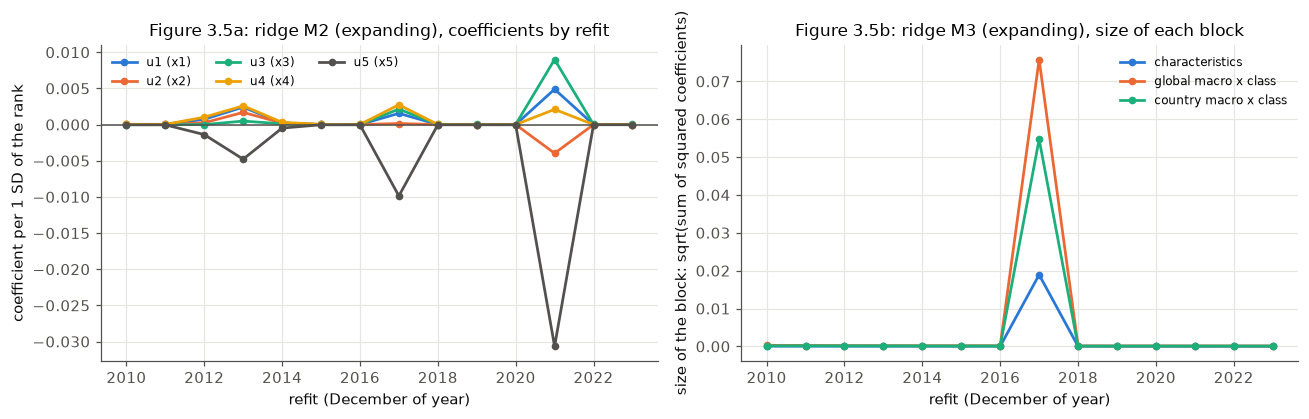

,mean coefficient,share of refits with the same sign as the mean
u1,0.001,1.000
u2,-0.000,0.429
u3,0.001,0.786
u4,0.001,1.000
u5,-0.003,1.000


lasso M3 (expanding): share of refits in which each block has at least one selected variable: {'characteristics': 0.14, 'global macro x class': 0.43, 'country macro x class': 0.21}
lasso M3 (expanding): variables selected in at least half the refits: []
PCR M3: components chosen per refit (expanding): [1, 1, 1, 3, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1]


In [45]:
# ---------- Tuning choices, edges, and which predictors carry the signal ----------
tuned = [n for n in ledger.index if ledger.loc[n, 'model'] in ('ridge', 'lasso', 'pcr', 'ridge-per-class')]
tune_tab = pd.DataFrame({n: {'refits': len(LOGS[n]), 'share of refits at a grid edge': LOGS[n]['at grid edge'].mean(),
                             'median choice': np.median(LOGS[n]['choice'].astype(float)),
                             'min choice': LOGS[n]['choice'].astype(float).min(), 'max choice': LOGS[n]['choice'].astype(float).max()}
                         for n in tuned}).T
display(tune_tab.style.format('{:.3g}').set_caption('Table 3.14: chosen penalty (ridge: alpha/n; lasso: alpha) or number of components (PCR)'))
print('grid edges: ridge alpha/n in [1e-4, 1e3]; lasso alpha in [3e-5, 0.32]; PCR K in [1, 10]. '
      'The top edge of ridge/lasso is the class-means model ("no signal"); the bottom edge is close to OLS.')

coef = pd.DataFrame([r['coef'] for _, r in LOGS['ridge|M2|expanding'].iterrows()],
                    index=[d.year for d in LOGS['ridge|M2|expanding']['refit']])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8))
for cn, col in zip(CHARS, [C_BLUE, C_ORANGE, C_AQUA, C_YELLOW, C_GREY]):
    ax1.plot(coef.index, coef[cn], marker='o', markersize=4, color=col, label=f'{cn} ({XNAMES[CHARS.index(cn)]})')
ax1.axhline(0, color=C_GREY, linewidth=1)
ax1.set_xlabel('refit (December of year)')
ax1.set_ylabel('coefficient per 1 SD of the rank')
ax1.set_title('Figure 3.5a: ridge M2 (expanding), coefficients by refit')
ax1.legend(fontsize=8, ncol=3)
coef3 = pd.DataFrame([r['coef'] for _, r in LOGS['ridge|M3|expanding'].iterrows()],
                     index=[d.year for d in LOGS['ridge|M3|expanding']['refit']])
blocks = {'characteristics': CHARS, 'global macro x class': GLOB, 'country macro x class': CTRY_INT}
for (bn, cols), col in zip(blocks.items(), [C_BLUE, C_ORANGE, C_AQUA]):
    ax2.plot(coef3.index, np.sqrt((coef3[cols] ** 2).sum(axis=1)), marker='o', markersize=4, color=col, label=bn)
ax2.set_xlabel('refit (December of year)')
ax2.set_ylabel('size of the block: sqrt(sum of squared coefficients)')
ax2.set_title('Figure 3.5b: ridge M3 (expanding), size of each block')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()
stab = pd.DataFrame({'mean coefficient': coef.mean(), 'share of refits with the same sign as the mean': (np.sign(coef) == np.sign(coef.mean())).mean()})
display(stab.style.format('{:.3f}').set_caption('Table 3.15: stability of the ridge M2 coefficients across the 14 refits'))
sel = pd.DataFrame([r['coef'] for _, r in LOGS['lasso|M3|expanding'].iterrows()]).ne(0).mean()
print('lasso M3 (expanding): share of refits in which each block has at least one selected variable:',
      {bn: round(float(pd.DataFrame([r['coef'] for _, r in LOGS['lasso|M3|expanding'].iterrows()])[cols].ne(0).any(axis=1).mean()), 2)
       for bn, cols in blocks.items()})
print('lasso M3 (expanding): variables selected in at least half the refits:', list(sel[sel >= 0.5].index))
print('PCR M3: components chosen per refit (expanding):', list(LOGS['pcr|M3|expanding']['choice']))

In [46]:
# ---------- The forest: out-of-sample permutation importance, year by year (L8 p.56-58) ----------
imp_rows = {}
for key, imp in IMPORTANCE.items():
    mse_b = pd.Series({DATES[b + 1].year: ((OOS.y - OOS.b_pool)[(OOS.m > b) & (OOS.m <= b + 12)] ** 2).mean() for b in REFIT_ENDS})
    pts = imp.div(mse_b, axis=0)                      # increase in MSE when shuffled, in R2_OOS points
    imp_rows[key] = pts
    display(pd.DataFrame({'mean over the 14 test years': pts.mean(), 'years with a positive importance': (pts > 0).sum()})
            .sort_values('mean over the 14 test years', ascending=False).style.format({'mean over the 14 test years': '{:.3%}'})
            .set_caption(f'Table 3.16: {key}: loss of R2_OOS when one input is shuffled in its test year'))

,mean over the 14 test years,years with a positive importance
dB,0.108%,9
u5,0.076%,9
dC,0.063%,8
u3,-0.007%,6
u2,-0.018%,5
u4,-0.025%,7
dD,-0.028%,8
u1,-0.028%,5


,mean over the 14 test years,years with a positive importance
g_x7,0.167%,5
dC,0.115%,9
g_x8,0.058%,7
dB,0.051%,11
g_x6,0.050%,4
u5,0.034%,11
c_x12,0.020%,8
c_x86,0.008%,7
u4,0.006%,8
dD,0.004%,8


In [47]:
# ---------- Per-class models vs the pooled model ----------
pc = {}
for fs in ['M2', 'M3']:
    for n in [f'ridge|{fs}|expanding', f'ridge-per-class|{fs}|expanding']:
        pc[n] = {**{f'class {c}': r2_oos(OOS.y[OOS.cls == c], RES[n][OOS.cls == c], OOS.b_pool[OOS.cls == c]) for c in 'ABCD'},
                 'all': res_tab.loc[n, 'R2 vs pooled mean']}
    d, se = delta_boot(RES[f'ridge-per-class|{fs}|expanding'], RES[f'ridge|{fs}|expanding'], OOS.b_pool.to_numpy())
    print(f'{fs}: per-class minus pooled R2_OOS = {d:.3%} (SE {se:.3%})')
display(pd.DataFrame(pc).T.style.format('{:.2%}').set_caption('Table 3.17: pooled vs per-class ridge (expanding), R2_OOS vs the pooled mean'))
first_rows = F[F.m <= INIT_END_M].groupby('cls').size()
print('training rows per class at the first refit (2010-12):', first_rows.to_dict(),
      '| slopes per class in M3: A', len(class_cols('M3', 'A')), '| B, C, D', len(class_cols('M3', 'B')))

M2: per-class minus pooled R2_OOS = 0.001% (SE 0.034%)
M3: per-class minus pooled R2_OOS = -1.086% (SE 0.386%)


,class A,class B,class C,class D,all
ridge|M2|expanding,-0.06%,1.81%,0.05%,-1.37%,0.04%
ridge-per-class|M2|expanding,-0.07%,1.94%,-0.00%,-1.39%,0.04%
ridge|M3|expanding,0.00%,1.74%,-0.88%,-1.29%,-0.08%
ridge-per-class|M3|expanding,-1.04%,-0.26%,-0.71%,-3.04%,-1.17%


training rows per class at the first refit (2010-12): {'A': 2496, 'B': 768, 'C': 864, 'D': 672} | slopes per class in M3: A 9 | B, C, D 15


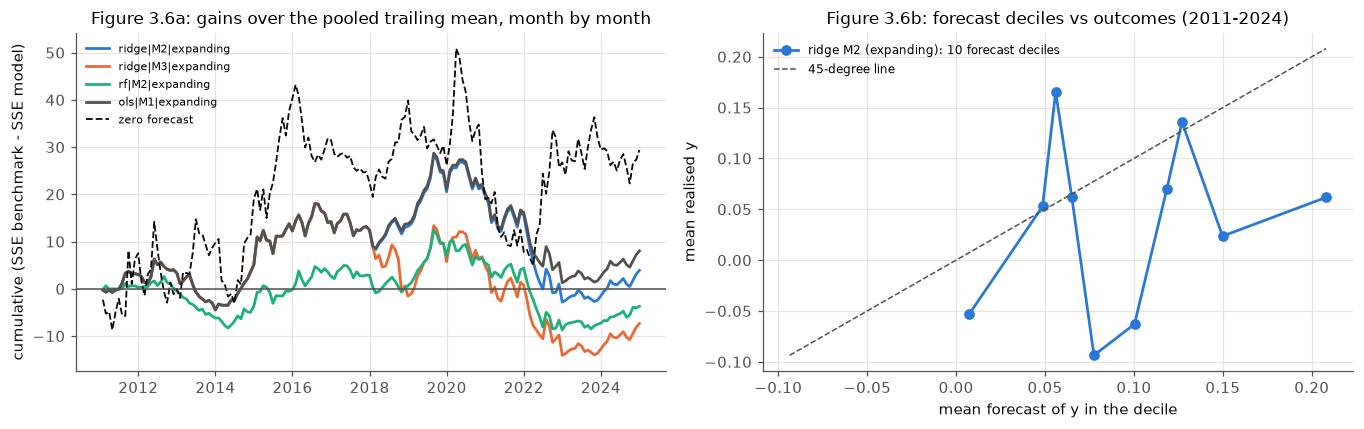

sd of the ridge M2 forecasts 0.055 vs sd of y 1.043; corr(forecast, outcome) = 0.020


In [48]:
# ---------- When do the gains accrue, and are the forecasts calibrated? ----------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4))
odates = DATES[OOS_M]
for n, col in [('ridge|M2|expanding', C_BLUE), ('ridge|M3|expanding', C_ORANGE), ('rf|M2|expanding', C_AQUA), ('ols|M1|expanding', C_GREY)]:
    gain = month_sums((OOS.y - OOS.b_pool) ** 2 - (OOS.y - RES[n]) ** 2)
    ax1.plot(odates, np.cumsum(gain), color=col, label=n)
gain0 = month_sums((OOS.y - OOS.b_pool) ** 2 - (OOS.y - ZERO) ** 2)
ax1.plot(odates, np.cumsum(gain0), color=C_INK, linestyle='--', linewidth=1.2, label='zero forecast')
ax1.axhline(0, color=C_GREY, linewidth=1)
ax1.set_ylabel('cumulative (SSE benchmark - SSE model)')
ax1.set_title('Figure 3.6a: gains over the pooled trailing mean, month by month')
ax1.legend(fontsize=7.5)
yh = RES['ridge|M2|expanding']
dec = pd.qcut(yh, 10, labels=False)
cal = pd.DataFrame({'forecast': yh, 'realised': OOS.y}).groupby(dec).mean()
ax2.plot(cal.forecast, cal.realised, 'o-', color=C_BLUE, label='ridge M2 (expanding): 10 forecast deciles')
lim = [min(cal.min()), max(cal.max())]
ax2.plot(lim, lim, color=C_GREY, linestyle='--', linewidth=1, label='45-degree line')
ax2.set_xlabel('mean forecast of y in the decile')
ax2.set_ylabel('mean realised y')
ax2.set_title('Figure 3.6b: forecast deciles vs outcomes (2011-2024)')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f'sd of the ridge M2 forecasts {yh.std(ddof=1):.3f} vs sd of y {OOS.y.std(ddof=1):.3f}; '
      f'corr(forecast, outcome) = {np.corrcoef(yh, OOS.y)[0, 1]:.3f}')

## 3.6 Does macro add? Placebo and robustness

**Macro vs no macro.** Each model is refit without macro, on the same rows, windows, folds and benchmark, so every comparison is paired. This is the "refit without it" test of the exam's suggested workflow.

**Placebo** [EXAM-DEFINED, suggested workflow].
- Every raw macro series is circularly shifted by $s$ months, then the identical pipeline runs: logs, differentials, trailing z-scores, lags, tuning.
- The data are real, but at the wrong time.
- A persistent series stays partly correlated with its shifted copy, so eight shifts are used, $s = 36, 48, \dots, 120$.
- The shift wraps around: the last $s$ months of each series move to the start of the sample. A target month uses raw macro months $t-61..t-2$ (a 60-month trailing z-score, then the 2-month lag), so every target month up to $s+60$ carries some wrapped values from the end of the sample. That covers 61–96 training months at the first fit and, for $s \ge 72$, the first out-of-sample years as well. The counts are printed below and checked by rebuilding the features.
- These wrapped values are later macro placed at the wrong date. They are no better aligned with the returns next to them than any other placebo value, which is the point of a placebo. But the placebo inputs are not strictly past data.

**Macro is credited only if** its gain over the no-macro model is more than 2 bootstrap SEs above zero **and** larger than every placebo gain (null logic of L4 p.26–28).

In [49]:
# ---------- Macro vs no macro: same model, same rows, same benchmark ----------
BP = OOS.b_pool.to_numpy()
pairs = ([(f'{mdl}|M3|{sch}', f'{mdl}|M2|{sch}') for mdl in ['ols', 'ridge', 'rf'] for sch in SCHEMES]
         + [('ridge|M3-global|expanding', 'ridge|M2|expanding'), ('ridge|M3-country|expanding', 'ridge|M2|expanding'),
            ('ridge-per-class|M3|expanding', 'ridge-per-class|M2|expanding'), ('ridge|M3-levels|expanding', 'ridge|M2-levels|expanding'),
            ('rf-deep|M3|expanding', 'rf-deep|M2|expanding')])
mac = pd.DataFrame([dict(zip(['with macro', 'without macro'], p)) | dict(zip(['gain in R2_OOS from macro', 'SE'], delta_boot(RES[p[0]], RES[p[1]], BP)))
                    for p in pairs])
mac['gain / SE'] = mac['gain in R2_OOS from macro'] / mac['SE']
display(mac.style.format({'gain in R2_OOS from macro': '{:.3%}', 'SE': '{:.3%}', 'gain / SE': '{:.2f}'})
        .set_caption('Table 3.18: what macro adds to each model (R2_OOS vs the pooled trailing mean, 2011-2024)'))
q2_gain, q2_se = delta_boot(RES['ridge|M3|expanding'], RES['ridge|M2|expanding'], BP)
print(f'Q2 primary: ridge M3 - ridge M2 (expanding) = {q2_gain:.3%} (SE {q2_se:.3%})')

# global macro is one number per month (a class-level signal); country macro also varies across countries within a month
xs_share = {}
for c in 'BCD':
    sub_c = F[F.cls == c]
    xs_share[f'class {c}'] = {k: (sub_c['c_' + k] - sub_c.groupby('m')['c_' + k].transform('mean')).var() / sub_c['c_' + k].var()
                              for k, _, _ in C_SER}
xs_share = pd.DataFrame(xs_share)
display(xs_share.style.format('{:.0%}').set_caption('Table 3.18b: share of the variance of each country-macro input that lies across countries within a month'))

,with macro,without macro,gain in R2_OOS from macro,SE,gain / SE
0,ols|M3|static,ols|M2|static,-19.467%,3.301%,-5.90
1,ols|M3|expanding,ols|M2|expanding,-4.698%,1.918%,-2.45
2,ols|M3|rolling,ols|M2|rolling,-5.340%,1.679%,-3.18
3,ridge|M3|static,ridge|M2|static,-0.006%,0.003%,-2.05
4,ridge|M3|expanding,ridge|M2|expanding,-0.123%,0.085%,-1.44
5,ridge|M3|rolling,ridge|M2|rolling,-0.208%,0.194%,-1.07
6,rf|M3|static,rf|M2|static,-2.961%,1.465%,-2.02
7,rf|M3|expanding,rf|M2|expanding,-1.428%,1.394%,-1.02
8,rf|M3|rolling,rf|M2|rolling,-0.952%,0.730%,-1.31
9,ridge|M3-global|expanding,ridge|M2|expanding,-0.414%,0.301%,-1.38


Q2 primary: ridge M3 - ridge M2 (expanding) = -0.123% (SE 0.085%)


,class B,class C,class D
x86,20%,26%,30%
x12,34%,46%,42%
x13,34%,36%,44%
x14,51%,62%,56%
x15,79%,80%,79%
x16,30%,44%,40%


,gain vs ridge M2,SE
shift (months),,
36,-0.327%,0.256%
48,0.125%,0.138%
60,0.070%,0.217%
72,-0.563%,0.263%
84,-0.300%,0.536%
96,-0.242%,0.215%
108,-0.027%,0.115%
120,-0.202%,0.272%


8 placebo runs in 11 s; real macro gain -0.123% ranks 4 of 9 (1 = best)
pre-registered rule (gain > 2 SE and above every placebo): NO


,first-fit training months (2003-2010) with wrapped macro,OOS target months with wrapped macro,last affected target month
shift (months),,,
36,61,0,2008-01
48,73,0,2009-01
60,85,0,2010-01
72,96,1,2011-01
84,96,13,2012-01
96,96,25,2013-01
108,96,37,2014-01
120,96,49,2015-01


checked by rebuilding: the last target month affected is m = s + 60 for s = 36 and s = 120


,36,48,60,72,84,96,108,120
global x6,-0.24,-0.35,-0.36,-0.08,0.01,-0.10,0.04,0.23
global x7,-0.18,-0.35,-0.21,-0.27,0.01,-0.14,-0.13,0.13
global x8,-0.17,-0.22,-0.46,0.03,0.51,0.25,-0.01,0.18
global x9,0.26,0.15,-0.06,-0.19,-0.22,-0.29,-0.35,-0.25
country x86,-0.22,-0.30,-0.24,-0.09,-0.12,-0.09,0.02,0.22
country x12,-0.20,-0.12,-0.05,-0.01,0.06,0.01,-0.05,0.08
country x13,0.10,-0.20,-0.18,-0.01,0.16,0.07,-0.08,0.11
country x14,-0.04,-0.15,-0.11,-0.08,0.01,0.11,0.18,0.12
country x15,-0.02,-0.04,-0.01,-0.01,0.01,0.02,0.04,-0.00
country x16,0.08,0.02,-0.13,-0.16,-0.21,-0.30,-0.35,-0.30


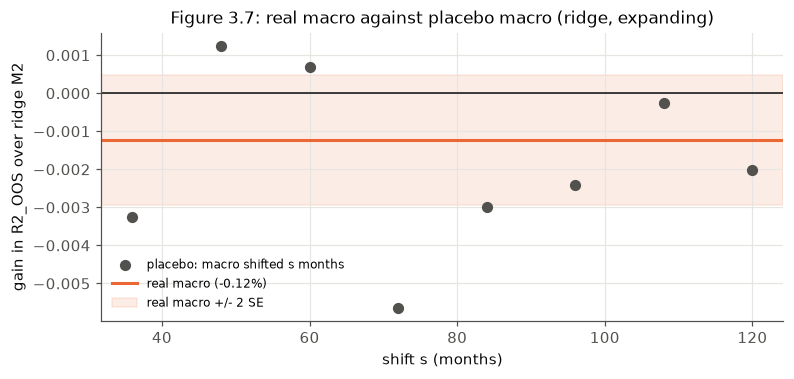

In [50]:
# ---------- Placebo: every macro series circularly shifted by s months (real data at the wrong time) ----------
t0 = time.perf_counter()
placebo = {}
for s in PLACEBO_SHIFTS:
    yh_s, _ = run_linear('ridge', FSETS['M3'], 'expanding', frame=variant(shift=s))
    placebo[s] = delta_boot(yh_s, RES['ridge|M2|expanding'], BP)
plac = pd.DataFrame(placebo, index=['gain vs ridge M2', 'SE']).T
plac.index.name = 'shift (months)'
display(plac.style.format('{:.3%}').set_caption('Table 3.19: placebo gains of ridge M3 (expanding) over ridge M2'))
print(f'{len(PLACEBO_SHIFTS)} placebo runs in {time.perf_counter() - t0:.0f} s; real macro gain {q2_gain:.3%} ranks '
      f'{1 + (plac["gain vs ridge M2"] > q2_gain).sum()} of {len(PLACEBO_SHIFTS) + 1} (1 = best)')
q2_verdict = (q2_gain > 2 * q2_se) and (q2_gain > plac['gain vs ridge M2'].max())
print(f'pre-registered rule (gain > 2 SE and above every placebo): {"YES" if q2_verdict else "NO"}')

# where the circular shift wraps: a target month m uses raw macro months m-61..m-2, so m <= s + 58 + MACRO_LAG is touched
last_touched = {s: s + 58 + MACRO_LAG for s in PLACEBO_SHIFTS}
wrap = pd.DataFrame({s: {'first-fit training months (2003-2010) with wrapped macro': min(t, INIT_END_M) - FIRST_M + 1,
                         'OOS target months with wrapped macro': max(0, t - INIT_END_M),
                         'last affected target month': DATES[t].strftime('%Y-%m')} for s, t in last_touched.items()}).T
wrap.index.name = 'shift (months)'
display(wrap.style.set_caption('Table 3.19b: where the circular shift puts end-of-sample macro values'))
def touched_months(s):
    """Rebuild the placebo features after perturbing the last s raw macro months: rows that change use wrapped values."""
    cut = DATES[len(DATES) - s]
    bump = lambda d, cols: d.assign(**{c: np.where(d.date >= cut, d[c] * 1.1 + 0.05, d[c]) for c in cols})
    Fa, _ = build_features(panel, mac_g, mac_c, mac_x, shift=s)
    Fb, _ = build_features(panel, bump(mac_g, G_SER), bump(mac_c, [k for k, f, _ in C_SER if f == 'curated']),
                           bump(mac_x, [k for k, f, _ in C_SER if f == 'extended']), shift=s)
    mcols = GLOB + CTRY_INT
    changed = (Fa[mcols] - Fb[mcols]).abs().max(axis=1) > 1e-8      # pandas' rolling sums leave round-off of ~1e-11 behind
    return Fa.m[changed].max()
for s in (PLACEBO_SHIFTS[0], PLACEBO_SHIFTS[-1]):
    assert touched_months(s) == last_touched[s], s
print(f'checked by rebuilding: the last target month affected is m = s + {58 + MACRO_LAG} for s = {PLACEBO_SHIFTS[0]} and s = {PLACEBO_SHIFTS[-1]}')

# how correlated each lag-ready macro input stays with its own shifted copy (why several shifts are needed)
pers = {}
for k in G_SER:
    z = AUX['GZ'][k]
    pers[f'global {k}'] = {s: z.corr(z.shift(s)) for s in PLACEBO_SHIFTS}
for k, _, _ in C_SER:
    Z = AUX['CZ'][k].drop(columns='country_7')
    pers[f'country {k}'] = {s: np.nanmean([Z[c].corr(Z[c].shift(s)) for c in Z]) for s in PLACEBO_SHIFTS}
display(pd.DataFrame(pers).T.style.format('{:.2f}').set_caption('Table 3.20: corr(input, input shifted s months), the persistence a placebo inherits'))

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.scatter(plac.index, plac['gain vs ridge M2'], color=C_GREY, s=40, label='placebo: macro shifted s months', zorder=3)
ax.axhline(q2_gain, color=C_ORANGE, linewidth=2, label=f'real macro ({q2_gain:.2%})')
ax.axhspan(q2_gain - 2 * q2_se, q2_gain + 2 * q2_se, color=C_ORANGE, alpha=0.12, label='real macro +/- 2 SE')
ax.axhline(0, color=C_INK, linewidth=1)
ax.set_xlabel('shift s (months)')
ax.set_ylabel('gain in R2_OOS over ridge M2')
ax.set_title('Figure 3.7: real macro against placebo macro (ridge, expanding)')
ax.legend(fontsize=8, loc='lower left')
plt.show()

In [51]:
# ---------- Robustness and the pre-listed extras, each against its parent ----------
rob_pairs = [('pcr-K3|M3|expanding', 'pcr|M3|expanding', 'PCR with K fixed at 3 vs K tuned'),
             ('pcr-K5|M3|expanding', 'pcr|M3|expanding', 'PCR with K fixed at 5 vs K tuned'),
             ('rf-deep|M2|expanding', 'rf|M2|expanding', 'deep forest (leaf 5) vs leaf 200, M2'),
             ('rf-deep|M3|expanding', 'rf|M3|expanding', 'deep forest (leaf 5) vs leaf 200, M3'),
             ('ridge|M3-lag1|expanding', 'ridge|M3|expanding', 'macro lag 1 month vs 2'),
             ('ridge|M2-zscore|expanding', 'ridge|M2|expanding', 'within-class z-score vs rank'),
             ('ridge|M2-levels|expanding', 'ridge|M2|expanding', 'M2 + own-history levels vs M2'),
             ('ridge|M3-levels|expanding', 'ridge|M3|expanding', 'M3 + own-history levels vs M3'),
             ('ridge|M3-x10|expanding', 'ridge|M3|expanding', 'curated x10 (14-month lag) vs x86')]
rob = pd.DataFrame([{'comparison': lab, 'R2_OOS (variant)': res_tab.loc[a, 'R2 vs pooled mean'],
                     'R2_OOS (parent)': res_tab.loc[b, 'R2 vs pooled mean'],
                     **dict(zip(['difference', 'SE'], delta_boot(RES[a], RES[b], BP))),
                     'mean IS R2 (variant)': res_tab.loc[a, 'mean IS R2']} for a, b, lab in rob_pairs]).set_index('comparison')
display(rob.style.format('{:.3%}').set_caption('Table 3.21: robustness checks (R2_OOS vs the pooled trailing mean)'))

# PCR's pre-registered grid starts at K = 1, while ridge and lasso can reach the class-means model. Added after the ledger
# (not a candidate): allow K = 0, i.e. class means only.
PCR0_YH, PCR0_LOG = run_linear('pcr', FSETS['M3'], 'expanding', grid=[0] + list(GRIDS['pcr']))
pcr0_d, pcr0_se = delta_boot(PCR0_YH, RES['pcr|M3|expanding'], BP)
print(f"PCR M3 (expanding) with K = 0 allowed: R2_OOS {r2_oos(OOS.y, PCR0_YH, BP):.3%} vs {res_tab.loc['pcr|M3|expanding', 'R2 vs pooled mean']:.3%} "
      f"on the pre-registered grid (difference {pcr0_d:.3%}, SE {pcr0_se:.3%}); K = 0 chosen in {(PCR0_LOG['choice'] == 0).sum()} of {len(PCR0_LOG)} refits; "
      f"choices {list(PCR0_LOG['choice'])}")

# the x10 trap, three ways: the headline (x86, lag 2), the curated file at a correct lag, and the naive 1-month lag
x10_tab = pd.DataFrame({
    'x86 at a 2-month lag (headline)': {'R2 vs pooled mean': res_tab.loc['ridge|M3|expanding', 'R2 vs pooled mean'],
                                         'R2 vs zero': res_tab.loc['ridge|M3|expanding', 'R2 vs zero'],
                                         'mean IS R2': res_tab.loc['ridge|M3|expanding', 'mean IS R2']},
    'x10 at a 14-month lag (curated file, no look-ahead)': {'R2 vs pooled mean': res_tab.loc['ridge|M3-x10|expanding', 'R2 vs pooled mean'],
                                                            'R2 vs zero': res_tab.loc['ridge|M3-x10|expanding', 'R2 vs zero'],
                                                            'mean IS R2': res_tab.loc['ridge|M3-x10|expanding', 'mean IS R2']},
    'x10 at a 1-month lag (LEAK DEMONSTRATION, not a result)': {'R2 vs pooled mean': r2_oos(OOS.y, LEAK_YH, BP),
                                                                'R2 vs zero': r2_oos(OOS.y, LEAK_YH, ZERO),
                                                                'mean IS R2': LEAK_LOG['IS R2'].mean()}}).T
display(x10_tab.style.format('{:.3%}').set_caption('Table 3.22: the x10 trap (ridge M3, expanding)'))
top = GRIDS['ridge'][0]                                   # the no-signal end of the ridge grid (class means only)
print('refits (of 14) in which ridge left the no-signal end of its grid: '
      f'x86 {(LOGS["ridge|M3|expanding"]["choice"] < top).sum()}, x10 at 14 months {(LOGS["ridge|M3-x10|expanding"]["choice"] < top).sum()}, '
      f'x10 leaked {(LEAK_LOG["choice"] < top).sum()}')

# evaluation-only cuts: the same forecasts scored without COVID's first months or without the stale-x1 rows
covid = ~OOS.date.between('2020-03-31', '2020-05-31').to_numpy()
stale = ~pd.Series(list(zip(OOS.asset_id, OOS.date))).isin(FROZEN_ROWS).to_numpy()
assert (~stale).sum() == len(FROZEN_ROWS)
cuts = pd.DataFrame({n: {'all 168 months': res_tab.loc[n, 'R2 vs pooled mean'],
                         'without 2020-03..05': r2_boot(RES[n], BP, covid)[0],
                         'without the 10 stale-x1 rows': r2_boot(RES[n], BP, stale)[0]} for n in KEY}).T
display(cuts.style.format('{:.3%}').set_caption('Table 3.23: evaluation-only cuts (no refitting)'))

,R2_OOS (variant),R2_OOS (parent),difference,SE,mean IS R2 (variant)
comparison,,,,,
PCR with K fixed at 3 vs K tuned,-0.360%,-0.171%,-0.189%,0.204%,0.596%
PCR with K fixed at 5 vs K tuned,-1.133%,-0.171%,-0.962%,0.311%,0.754%
"deep forest (leaf 5) vs leaf 200, M2",-2.233%,-0.040%,-2.192%,0.358%,27.132%
"deep forest (leaf 5) vs leaf 200, M3",-6.161%,-1.469%,-4.692%,2.409%,58.429%
macro lag 1 month vs 2,-0.452%,-0.080%,-0.372%,0.363%,1.333%
within-class z-score vs rank,0.069%,0.042%,0.027%,0.020%,0.276%
M2 + own-history levels vs M2,-0.012%,0.042%,-0.054%,0.191%,0.519%
M3 + own-history levels vs M3,-0.426%,-0.080%,-0.346%,0.288%,1.045%
curated x10 (14-month lag) vs x86,0.065%,-0.080%,0.146%,0.069%,0.304%


PCR M3 (expanding) with K = 0 allowed: R2_OOS -0.095% vs -0.171% on the pre-registered grid (difference 0.076%, SE 0.067%); K = 0 chosen in 8 of 14 refits; choices [0, 0, 0, 3, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1]


,R2 vs pooled mean,R2 vs zero,mean IS R2
x86 at a 2-month lag (headline),-0.080%,-0.402%,0.402%
"x10 at a 14-month lag (curated file, no look-ahead)",0.065%,-0.256%,0.304%
"x10 at a 1-month lag (LEAK DEMONSTRATION, not a result)",-0.050%,-0.371%,0.418%


refits (of 14) in which ridge left the no-signal end of its grid: x86 1, x10 at 14 months 1, x10 leaked 3


,all 168 months,without 2020-03..05,without the 10 stale-x1 rows
ols|M1|expanding,0.087%,0.080%,0.071%
ols|M2|expanding,-0.015%,-0.020%,-0.031%
ridge|M2|expanding,0.042%,0.032%,0.026%
rf|M2|expanding,-0.040%,-0.030%,-0.054%
ridge|M3|expanding,-0.080%,-0.100%,-0.097%
lasso|M3|expanding,-0.132%,-0.155%,-0.148%
pcr|M3|expanding,-0.171%,-0.200%,-0.195%
rf|M3|expanding,-1.469%,-1.708%,-1.496%


## 3.7 From forecasts to portfolios

**Forecast portfolios**, all at unit gross exposure and rebalanced monthly. Each uses the month-$t$ forecast, which is built from information through $t-1$:
- **P1** (primary): $w_{i,t}\propto \hat y_{i,t}/\hat\sigma_{i,t-1}$. Since $\hat r = \hat y\,\hat\sigma$, this is the mean–variance tilt $\hat r/\hat\sigma^2$ with a diagonal covariance. With a constant forecast it collapses exactly to risk parity, so RP is the natural bar (identity checked in Section 3.3).
- **P3**: $w_{i,t}\propto(\hat y_{i,t}-\bar{\hat y}_{\text{class},t})/\hat\sigma_{i,t-1}$, a long–short portfolio within each class that isolates the cross-sectional signal.
- **P1 on the class-means model (M1)**: a diagnostic of what class premia alone do.
- **P1 on ridge M2, static** (one fit at 2010-12) and **rolling**: added after the first review, as diagnostics. The static version holds the forecasts of 2010 fixed, so it separates a frozen class tilt from one that is re-estimated every year. The rolling version shows how much the portfolio depends on the scheme. Neither is a candidate for Q3.
- **Class risk budget** (our choice): each class sleeve is set to unit gross within the class and scaled by the inverse of the trailing 36-month volatility of that class's **RP** sleeve, so every class carries roughly equal ex-ante risk. The same class scales are applied to RP and to P1. The two budgeted versions therefore have identical class shares of gross exposure by construction (Table 3.28); only the weights inside each class differ. Because the sleeve's volatility already includes the correlation inside the class, no covariance matrix is inverted. A 50 × 50 sample covariance from 36–96 months would be rank-deficient or badly conditioned (L1 p.63).

**Costs** (not taught; our assumption): 10 bp per unit of turnover $\sum_i|\Delta w_{i}|$ (buys plus sells), charged to every strategy including the benchmarks. Where one-way turnover is defined as half that sum, this is 20 bp per unit, so it is conservative. We also report a grid from 0 to 50 bp and break-even costs.

**Exposure vs timing.** Net P1 returns are regressed on the three net benchmark returns (L2 p.94–97; multiple regression L3). The β's measure exposure to the simple rules; α is what they cannot replicate.

In [52]:
OOS_IDX = DATES[OOS_M]
assert list(OOS.asset_id[:50]) == IDS and (OOS.m.to_numpy().reshape(T_OOS, 50) == OOS_M[:, None]).all()
def yh_wide(name):
    """Forecasts of one specification as a (month x asset) table."""
    return pd.DataFrame(np.asarray(RES[name]).reshape(T_OOS, 50), index=OOS_IDX, columns=IDS)

# class risk budget: each class sleeve (unit gross within the class) scaled by 1 / its trailing 36-month volatility
def within_class_unit(W):
    out = W.copy()
    for c in 'ABCD':
        cols = CLS_S.index[CLS_S == c]
        out[cols] = unit_gross(W[cols])
    return out
sleeve_ret = pd.DataFrame({c: port_ret(unit_gross((1.0 / SIG_W.loc[bench_idx])[CLS_S.index[CLS_S == c]])) for c in 'ABCD'})
sleeve_vol = sleeve_ret.rolling(36, min_periods=36).std(ddof=1).shift(1)          # known at the end of t-1
def class_budget(W):
    scale = (1.0 / sleeve_vol.loc[W.index])[CLS_S[W.columns].to_numpy()].to_numpy()
    return unit_gross(within_class_unit(W) * scale)
assert sleeve_vol.loc[OOS_IDX].notna().all().all()

STRATS = {'EW': W_EW.loc[OOS_IDX], 'RP': W_RP.loc[OOS_IDX], 'TSMOM': W_TS.loc[OOS_IDX],
          'RP, class risk budget': class_budget(1.0 / SIG_W.loc[OOS_IDX]),
          'P1 ridge M2 (primary)': weights_from_forecast(yh_wide('ridge|M2|expanding'), 'P1'),
          'P1 ridge M3': weights_from_forecast(yh_wide('ridge|M3|expanding'), 'P1'),
          'P3 ridge M2': weights_from_forecast(yh_wide('ridge|M2|expanding'), 'P3'),
          'P3 ridge M3': weights_from_forecast(yh_wide('ridge|M3|expanding'), 'P3'),
          'P1 class means (M1)': weights_from_forecast(yh_wide('ols|M1|expanding'), 'P1'),
          'P1 ridge M2, static (one fit, 2010-12)': weights_from_forecast(yh_wide('ridge|M2|static'), 'P1'),
          'P1 ridge M2, rolling (not selected)': weights_from_forecast(yh_wide('ridge|M2|rolling'), 'P1'),
          'P1 ridge M2, class risk budget': class_budget(yh_wide('ridge|M2|expanding') / SIG_W.loc[OOS_IDX])}
for k, W in STRATS.items():
    assert np.allclose(W.abs().sum(axis=1), 1), k
S_RET = {k: port_ret(W) for k, W in STRATS.items()}
S_TO = {k: (BENCH_TO[k].loc[OOS_IDX] if k in BENCH_TO else turnover(W)) for k, W in STRATS.items()}

rows = {}
for k in STRATS:
    rows[(k, 'gross')] = perf(S_RET[k], S_TO[k], OOS_M)
    rows[(k, f'net {HEADLINE_BP} bp')] = perf(S_RET[k], S_TO[k], OOS_M, HEADLINE_BP)
port_tab = pd.DataFrame(rows).T
display(port_tab.style.format('{:.3f}').set_caption('Table 3.24: portfolios, 2011-2024 (168 months)'))
subp = pd.DataFrame({lab: {k: perf(S_RET[k], S_TO[k], np.arange(s0, s1 + 1), HEADLINE_BP)['Sharpe'] for k in STRATS}
                     for lab, (s0, s1) in SUBPERIODS.items()})
display(subp.style.format('{:.2f}').set_caption(f'Table 3.25: net Sharpe ratio ({HEADLINE_BP} bp) by sub-period'))

,2011-2017,2018-2024
EW,-0.02,0.53
RP,0.37,0.24
TSMOM,0.29,-0.06
"RP, class risk budget",0.63,0.04
P1 ridge M2 (primary),0.58,0.32
P1 ridge M3,0.58,0.24
P3 ridge M2,-0.07,-0.17
P3 ridge M3,-0.31,-0.66
P1 class means (M1),0.58,0.32
"P1 ridge M2, static (one fit, 2010-12)",0.33,0.21


,0 bp,5 bp,10 bp,25 bp,50 bp,break-even cost (bp): net mean = 0,cost (bp) at which P1-M2 = EW,cost (bp) at which P1-M2 = RP,cost (bp) at which P1-M2 = TSMOM
EW,0.28,0.28,0.28,0.27,0.25,516.71,,,
RP,0.31,0.30,0.30,0.29,0.27,380.58,,,
TSMOM,0.20,0.16,0.12,0.00,-0.19,25.27,,,
"RP, class risk budget",0.30,0.30,0.29,0.28,0.25,323.95,,,
P1 ridge M2 (primary),0.46,0.45,0.44,0.43,0.40,373.97,259.72,362.97,
P1 ridge M3,0.41,0.40,0.39,0.37,0.33,258.01,,,
P3 ridge M2,0.08,-0.02,-0.11,-0.41,-0.89,4.11,,,
P3 ridge M3,0.04,-0.23,-0.49,-1.27,-2.53,0.68,,,
P1 class means (M1),0.45,0.44,0.44,0.42,0.40,417.11,,,
"P1 ridge M2, static (one fit, 2010-12)",0.28,0.27,0.27,0.25,0.23,313.92,,,


(a blank break-even means the two net Sharpe curves do not cross between 0 and 500 bp)


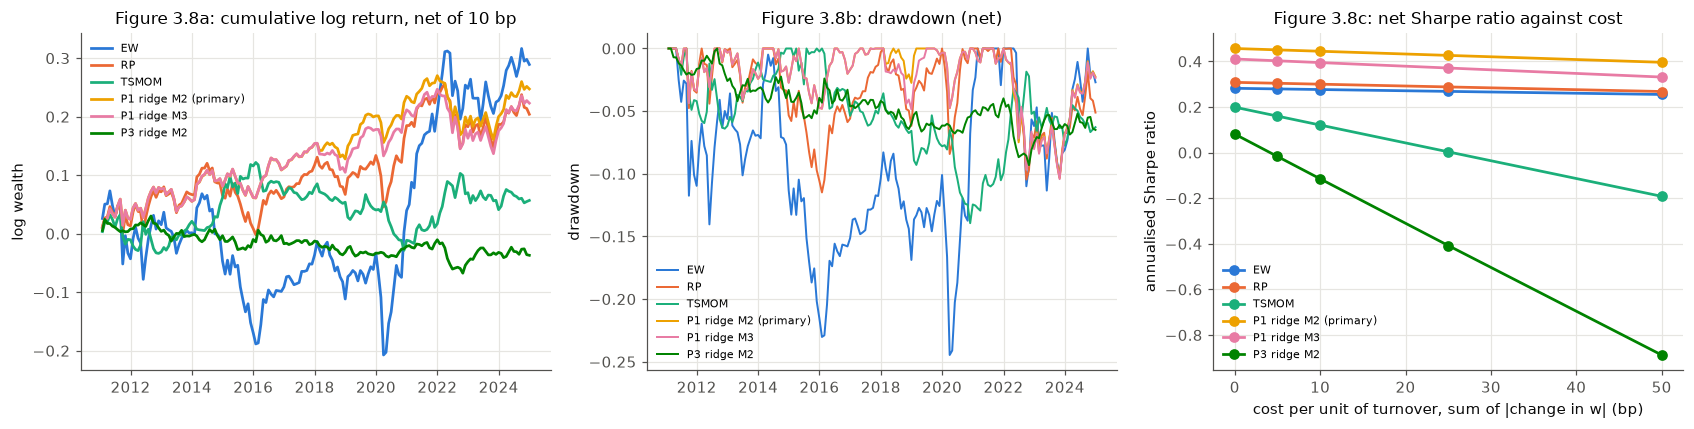

In [53]:
# ---------- Costs: net Sharpe on a grid, and break-even costs ----------
from scipy.optimize import brentq
def net_sharpe(k, bp):
    return perf(S_RET[k], S_TO[k], OOS_M, bp)['Sharpe']
cost_tab = pd.DataFrame({f'{bp} bp': {k: net_sharpe(k, bp) for k in STRATS} for bp in COST_BP})
g = {k: perf(S_RET[k], S_TO[k], OOS_M) for k in STRATS}
cost_tab['break-even cost (bp): net mean = 0'] = [1e4 * g[k]['ann. mean'] / 12 / g[k]['turnover / month'] for k in STRATS]
def breakeven_vs(k, b, hi=500):
    f = lambda bp: net_sharpe(k, bp) - net_sharpe(b, bp)
    return brentq(f, 0, hi) if f(0) * f(hi) < 0 else np.nan
for b in ['EW', 'RP', 'TSMOM']:
    cost_tab[f'cost (bp) at which P1-M2 = {b}'] = [breakeven_vs('P1 ridge M2 (primary)', b) if k == 'P1 ridge M2 (primary)' else np.nan for k in STRATS]
display(cost_tab.style.format('{:.2f}', na_rep='').set_caption('Table 3.26: net Sharpe ratio against the cost per unit of turnover (sum of |change in w|)'))
print('(a blank break-even means the two net Sharpe curves do not cross between 0 and 500 bp)')

show = ['EW', 'RP', 'TSMOM', 'P1 ridge M2 (primary)', 'P1 ridge M3', 'P3 ridge M2']
cols6 = [C_BLUE, C_ORANGE, C_AQUA, C_YELLOW, '#e87ba4', '#008300']
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4))
for k, col in zip(show, cols6):
    r = S_RET[k] - HEADLINE_BP / 1e4 * S_TO[k].where(S_TO[k].index != OOS_IDX[0], 0.0)
    w = (1 + r).cumprod()
    axes[0].plot(OOS_IDX, np.log(w), color=col, label=k)
    axes[1].plot(OOS_IDX, -(1 - w / w.cummax()), color=col, linewidth=1.3, label=k)
    axes[2].plot(COST_BP, [net_sharpe(k, bp) for bp in COST_BP], marker='o', color=col, label=k)
axes[0].set_title(f'Figure 3.8a: cumulative log return, net of {HEADLINE_BP} bp')
axes[0].set_ylabel('log wealth')
axes[1].set_title('Figure 3.8b: drawdown (net)')
axes[1].set_ylabel('drawdown')
axes[2].set_title('Figure 3.8c: net Sharpe ratio against cost')
axes[2].set_xlabel('cost per unit of turnover, sum of |change in w| (bp)')
axes[2].set_ylabel('annualised Sharpe ratio')
for ax in axes:
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

In [54]:
# ---------- Exposure vs timing: regress P1 on the benchmark rules (net of costs) ----------
import statsmodels.formula.api as smf
def net_ret(k):
    to = S_TO[k].copy()
    to.iloc[0] = 0.0
    return S_RET[k] - HEADLINE_BP / 1e4 * to
dfp = pd.DataFrame({'P1': net_ret('P1 ridge M2 (primary)'), 'EW': net_ret('EW'), 'RP': net_ret('RP'), 'TS': net_ret('TSMOM'),
                    'M1': net_ret('P1 class means (M1)'), 'P1_M3': net_ret('P1 ridge M3'),
                    'P1_static': net_ret('P1 ridge M2, static (one fit, 2010-12)')})
att = {}
for lab, formula in [('P1 on EW + RP + TSMOM', 'P1 ~ EW + RP + TS'), ('P1 on RP alone', 'P1 ~ RP'),
                     ('P1 on EW + RP + TSMOM + class-means tilt', 'P1 ~ EW + RP + TS + M1'), ('P1 (M3) on EW + RP + TSMOM', 'P1_M3 ~ EW + RP + TS'),
                     ('P1 class means (M1) on EW + RP + TSMOM', 'M1 ~ EW + RP + TS'), ('P1 static (M2) on EW + RP + TSMOM', 'P1_static ~ EW + RP + TS')]:
    fit = smf.ols(formula, data=dfp).fit()
    att[lab] = {'alpha (annualised)': 12 * fit.params['Intercept'], 't(alpha)': fit.tvalues['Intercept'], 'R2': fit.rsquared,
                **{f'beta {v}': fit.params[v] for v in ['EW', 'RP', 'TS', 'M1'] if v in fit.params}}
att_tab = pd.DataFrame(att).T
display(att_tab.style.format('{:.3f}', na_rep='').set_caption(f'Table 3.27: exposure vs timing, monthly net returns 2011-2024 ({T_OOS} months)'))
fit_rp = smf.ols('P1 ~ RP', data=dfp).fit()
t_beta1 = (fit_rp.params['RP'] - 1) / fit_rp.bse['RP']                            # testing beta = 1 by hand (L2 p.97)
print(f'P1 on RP alone: beta = {fit_rp.params["RP"]:.3f} (SE {fit_rp.bse["RP"]:.3f}); t for beta = 1: {t_beta1:.2f}')
# the same regression within each sub-period (added after the first review)
sub_att = {}
for lab, (s0, s1) in SUBPERIODS.items():
    d_ = dfp.loc[DATES[s0]:DATES[s1]]
    f_ = smf.ols('P1 ~ EW + RP + TS', data=d_).fit()
    sub_att[lab] = {'months': len(d_), 'alpha (annualised)': 12 * f_.params['Intercept'], 't(alpha)': f_.tvalues['Intercept'], 'R2': f_.rsquared}
display(pd.DataFrame(sub_att).T.style.format({'months': '{:.0f}', 'alpha (annualised)': '{:.3%}', 't(alpha)': '{:.2f}', 'R2': '{:.3f}'})
        .set_caption('Table 3.27b: P1 (ridge M2) on EW + RP + TSMOM, by sub-period (net of 10 bp)'))

Wp, Wr, Wt = STRATS['P1 ridge M2 (primary)'], STRATS['RP'], STRATS['TSMOM']
overlap = pd.Series({'avg monthly corr(P1 weights, RP weights)': np.mean([np.corrcoef(Wp.iloc[i], Wr.iloc[i])[0, 1] for i in range(T_OOS)]),
                     'avg monthly corr(P1 weights, TSMOM weights)': np.mean([np.corrcoef(Wp.iloc[i], Wt.iloc[i])[0, 1] for i in range(T_OOS)]),
                     'share of months P1 is net short at least one class': np.mean([(Wp.iloc[i].T.groupby(CLS_S).sum() < 0).any() for i in range(T_OOS)]),
                     'P1 average net exposure (sum of w)': Wp.sum(axis=1).mean(),
                     'P1 largest single |weight|': Wp.abs().max().max(), 'P1 asset_16 average |weight|': Wp['asset_16'].abs().mean()}, name='value')
display(overlap.to_frame().style.format('{:.3f}'))
display(pd.DataFrame({k: STRATS[k].abs().T.groupby(CLS_S).sum().T.mean() for k in ['RP', 'P1 ridge M2 (primary)', 'P1 ridge M2, class risk budget', 'RP, class risk budget']}).T
        .style.format('{:.3f}').set_caption('Table 3.28: average share of gross exposure by class, 2011-2024'))

# is the class tilt fixed or re-estimated? class-D share of gross by year, and the class-means forecast of y by year
yr = OOS_IDX.year
d_share = pd.DataFrame({k: STRATS[k].abs().T.groupby(CLS_S).sum().T['D'].groupby(yr).mean()
                        for k in ['RP', 'P1 class means (M1)', 'P1 ridge M2 (primary)', 'P1 ridge M2, static (one fit, 2010-12)']})
cls_fc = yh_wide('ols|M1|expanding').T.groupby(CLS_S).mean().T.groupby(yr).mean()
cls_fc.columns = [f'class {c}: forecast of y' for c in cls_fc.columns]
tilt_tab = pd.concat([d_share.add_prefix('class-D share: '), cls_fc], axis=1)
tilt_tab.index.name = 'year'
display(tilt_tab.style.format('{:.3f}').set_caption('Table 3.28b: the class tilt year by year (class means re-estimated every December)'))

,alpha (annualised),t(alpha),R2,beta EW,beta RP,beta TS,beta M1
P1 on EW + RP + TSMOM,0.006,1.744,0.904,-0.303,1.212,0.100,
P1 on RP alone,0.007,1.591,0.845,,0.719,,
P1 on EW + RP + TSMOM + class-means tilt,0.000,0.815,0.998,-0.022,0.067,0.008,0.947
P1 (M3) on EW + RP + TSMOM,0.004,1.115,0.896,-0.313,1.242,0.108,
P1 class means (M1) on EW + RP + TSMOM,0.006,1.648,0.897,-0.296,1.208,0.098,
P1 static (M2) on EW + RP + TSMOM,-0.002,-0.914,0.983,-0.028,0.962,0.009,


P1 on RP alone: beta = 0.719 (SE 0.024); t for beta = 1: -11.76


,months,alpha (annualised),t(alpha),R2
2011-2017,84,-0.162%,-0.37,0.930
2018-2024,84,1.358%,2.47,0.902


,value
"avg monthly corr(P1 weights, RP weights)",0.935
"avg monthly corr(P1 weights, TSMOM weights)",0.251
share of months P1 is net short at least one class,0.143
P1 average net exposure (sum of w),0.989
P1 largest single |weight|,0.418
P1 asset_16 average |weight|,0.216


,A,B,C,D
RP,0.258,0.215,0.154,0.373
P1 ridge M2 (primary),0.175,0.070,0.156,0.600
"P1 ridge M2, class risk budget",0.143,0.249,0.144,0.464
"RP, class risk budget",0.143,0.249,0.144,0.464


,class-D share: RP,class-D share: P1 class means (M1),class-D share: P1 ridge M2 (primary),"class-D share: P1 ridge M2, static (one fit, 2010-12)",class A: forecast of y,class B: forecast of y,class C: forecast of y,class D: forecast of y
year,,,,,,,,
2011,0.381,0.450,0.450,0.450,0.150,0.122,0.087,0.169
2012,0.378,0.546,0.546,0.449,0.126,0.111,0.066,0.210
2013,0.360,0.535,0.535,0.431,0.119,0.105,0.084,0.215
2014,0.358,0.497,0.496,0.429,0.101,0.086,0.116,0.177
2015,0.344,0.584,0.584,0.416,0.081,0.047,0.120,0.216
2016,0.360,0.669,0.669,0.432,0.055,0.022,0.116,0.216
2017,0.357,0.648,0.648,0.430,0.062,0.015,0.124,0.213
2018,0.363,0.619,0.619,0.436,0.061,0.027,0.137,0.203
2019,0.381,0.697,0.697,0.454,0.050,0.011,0.113,0.198


In [55]:
# ---------- How precise are the Sharpe comparisons? Paired month bootstrap (the same resampled months as before) ----------
def sharpe_b(r):
    a = r.to_numpy()[BOOT_IDX]
    return np.sqrt(12) * a.mean(1) / a.std(1, ddof=1)
sb = {k: sharpe_b(net_ret(k)) for k in STRATS}
p1 = 'P1 ridge M2 (primary)'
d_tab = pd.DataFrame({b: {'net Sharpe P1 - benchmark': net_sharpe(p1, HEADLINE_BP) - net_sharpe(b, HEADLINE_BP),
                          'bootstrap SE': (sb[p1] - sb[b]).std(ddof=1)} for b in ['EW', 'RP', 'TSMOM', 'RP, class risk budget']}).T
d_tab['difference / SE'] = d_tab.iloc[:, 0] / d_tab.iloc[:, 1]
display(d_tab.style.format('{:.3f}').set_caption('Table 3.29: Sharpe-ratio differences, P1 (ridge M2) minus each rule, net of 10 bp'))

# Q3, pre-registered: higher net Sharpe than all three rules AND a positive alpha with t > 2
sr_p1 = net_sharpe(p1, HEADLINE_BP)
beats = {b: sr_p1 > net_sharpe(b, HEADLINE_BP) for b in ['EW', 'RP', 'TSMOM']}
q3_verdict = all(beats.values()) and att['P1 on EW + RP + TSMOM']['alpha (annualised)'] > 0 and att['P1 on EW + RP + TSMOM']['t(alpha)'] > 2
print(f'Q3: net Sharpe P1 = {sr_p1:.2f}; beats ' + ', '.join(f'{b}: {v}' for b, v in beats.items())
      + f"; alpha t = {att['P1 on EW + RP + TSMOM']['t(alpha)']:.2f} -> pre-registered rule: {'YES' if q3_verdict else 'NO'}")

,net Sharpe P1 - benchmark,bootstrap SE,difference / SE
EW,0.168,0.181,0.927
RP,0.144,0.109,1.323
TSMOM,0.324,0.414,0.782
"RP, class risk budget",0.153,0.098,1.565


Q3: net Sharpe P1 = 0.44; beats EW: True, RP: True, TSMOM: True; alpha t = 1.74 -> pre-registered rule: NO


In [56]:
# ---------- Diversification: does the correlation structure change over time? ----------
periods = {'2003-2010 (training)': ('2003-01-31', '2010-12-31'), '2011-2019': ('2011-01-31', '2019-12-31'), '2020-2024': ('2020-01-31', '2024-12-31')}
div = {}
for lab, (a, b) in periods.items():
    C = R.loc[a:b].corr()
    bt = block_table(C)
    ev = np.linalg.eigvalsh(C.to_numpy())
    div[lab] = {**{f'within {c}': bt.loc[c, c] for c in 'ABCD'},
                'A-C (commodity-like vs equity-like)': bt.loc['A', 'C'], 'C-D (equity-like vs bond-like)': bt.loc['C', 'D'],
                'B-C': bt.loc['B', 'C'], 'first principal component, share of variance': ev.max() / ev.sum()}
display(pd.DataFrame(div).style.format('{:.2f}').set_caption('Table 3.30: average return correlations and the first-PC share, by period (L1 p.42-44)'))

,2003-2010 (training),2011-2019,2020-2024
within A,0.25,0.19,0.21
within B,0.52,0.51,0.68
within C,0.76,0.66,0.77
within D,0.59,0.61,0.59
A-C (commodity-like vs equity-like),0.22,0.14,0.22
C-D (equity-like vs bond-like),-0.17,-0.23,0.22
B-C,0.26,0.20,0.44
"first principal component, share of variance",0.29,0.26,0.30


## 3.8 Leakage audit

These are the five questions of L5 p.58 and the four traps of AI guide §4, and where each is guarded in this notebook. The first and third L5 items are graded as fatal.

| risk | where it could enter | how it is prevented | executable check |
|---|---|---|---|
| **a transformation fitted before the split** (FATAL; L5 p.58 #1; AI guide §4b) | scalers, imputation, PCA, z-scores, winsorising | `StandardScaler` and PCA are fitted inside every fit window and every validation fold. Ranks use a single date. Global and country z-scores are trailing. Nothing is imputed. The clip bounds are fixed constants. | `n_samples_seen_` asserted at every fit; the truncation causality test (Section 3.2); unit tests (Section 3.4) |
| a merge on period end instead of publication date (L5 p.58 #2) | macro used contemporaneously; `x10`'s same-year averages | 2-month lag on every macro series; `x10` replaced by `x86`; annual/quarterly columns unused | lag spot checks; `x10` audit (Figure 3.1a); leak demonstration (Table 3.22) |
| **a random fold on time-ordered data** (FATAL; L5 p.58 #3; AI guide §4a) | `train_test_split`, `KFold`, `*CV` estimators, shuffled early stopping | one splitter (`window`, `inner_folds`), date masks only | `train.max() < validation.min()` and `window.max() < test.min()` asserted at every fold and refit |
| a threshold or hyper-parameter chosen on the test block (L5 p.58 #4) | penalties, number of components, forest settings, portfolio rules, cost | tuned on validation years inside the training window; forest untuned; rules and costs fixed in Section 3.0 | refit log (Table 3.14); the test rows never enter `run_linear`'s tuning loop |
| a benchmark changed after the fact (L5 p.58 #5) | switching trailing means | pooled trailing mean fixed in Section 3.0; all others always shown | benchmark unit tests (Section 3.3) |
| `r2_score` read as $R^2_{OOS}$ (AI guide §4d) | sklearn's default scoring | own `r2_oos`; explicit `neg_mean_squared_error` in permutation importance | scorer unit tests |
| `LogisticRegression()` called plain (AI guide §4c) | none | no classifier in Problem 3 | none needed |
| look-ahead in characteristics | x2/x5 pre-lagged, x1/x3/x4 contemporaneous, back-fills | lag only x1/x3/x4; back-filled cells set to missing; first target after the last fill | identities x2 = R12, x5 = SD36; fill table (Section 3.1) |
| snooping in the exploratory analysis | predictor–return statistics on 2011–2024 | tercile sorts on 2003–2010 only | assertion in the sort cell |
| too good to be true (L5 p.57) | any leak | alarm on any $R^2_{OOS}$ above 2% | Section 3.5 (not triggered) |

In [57]:
n_refits = sum(len(LOGS[n]) for n in ledger.index)
n_of = lambda models: sum(len(LOGS[n]) for n in ledger.index if ledger.loc[n, 'model'] in models)
audit = pd.Series({
    'model refits, each with train < test asserted': n_refits,
    'linear refits tuned on 3 forward validation folds, order asserted (ridge, lasso, PCR, per-class ridge)': n_of(('ridge', 'lasso', 'pcr', 'ridge-per-class')),
    'linear refits with nothing to tune (OLS, PCR with K fixed)': n_of(('ols', 'pcr-K3', 'pcr-K5')),
    'forest refits (untuned)': n_of(('rf', 'rf-deep')),
    'lag spot checks passed': 20,
    'causality test (rebuild from data truncated at 2010-12): identical features': True,
    'unit tests of the harness passed': True,
    'largest R2_OOS of the 38 specifications (alarm at 2%)': f"{res_tab[['R2 vs pooled mean', 'R2 vs zero']].max().max():.2%}",
    'tercile sorts use months up to': str(DATES[INIT_END_M].date())}, name='check')
display(audit.to_frame())

,check
"model refits, each with train < test asserted",512
"linear refits tuned on 3 forward validation folds, order asserted (ridge, lasso, PCR, per-class ridge)",326
"linear refits with nothing to tune (OLS, PCR with K fixed)",100
forest refits (untuned),86
lag spot checks passed,20
causality test (rebuild from data truncated at 2010-12): identical features,True
unit tests of the harness passed,True
largest R2_OOS of the 38 specifications (alarm at 2%),0.21%
tercile sorts use months up to,2010-12-31


## 3.9 Headline numbers

Every number the write-up quotes is printed in the table below (cell 1: every number comes from a cell).

In [58]:
# ---------- Every number quoted in the write-up, printed from the objects above ----------
best = res_tab['R2 vs pooled mean'].idxmax()
b_tab = res_tab.loc[best]
def edge_share(n):
    return (LOGS[n]['choice'] == GRIDS['ridge'][0]).mean()
headline = pd.Series({
    'specifications in the ledger': len(ledger), 'Bonferroni critical |t| for 38 tests': round(bonf38, 2),
    'OOS months / asset-months': f'{T_OOS} / {len(OOS):,}',
    'mean of y: training block / OOS': f'{F.loc[F.m <= INIT_END_M, "y"].mean():.3f} / {OOS.y.mean():.3f}',
    'R2_OOS of the zero forecast vs the pooled trailing mean': f'{r2_oos(OOS.y, ZERO, OOS.b_pool):.2%}',
    'Q1: R2_OOS ridge M2 expanding vs pooled mean (SE)': f'{q1:.3%} ({q1_se:.3%})',
    'Q1: same, vs zero (SE)': '{:.3%} ({:.3%})'.format(*r2_boot(RES[P], ZERO)),
    'Q1: class means alone (M1) vs pooled mean (SE)': f'{m1:.3%} ({m1_se:.3%})',
    'Q1: characteristics beyond class means (SE)': f'{d_char:.3%} ({d_char_se:.3%})',
    'Q1: pre-registered verdict': 'YES' if q1_verdict else 'NO',
    'Q1: true R2_OOS needed to pass the rule at 50% / 80% power': f'{q1_mde:.2%} / {q1_mde80:.2%}',
    'R2_OOS vs the pooled mean, range over the 38 specifications': f"{res_tab['R2 vs pooled mean'].min():.2%} .. {res_tab['R2 vs pooled mean'].max():.2%}",
    'specifications at or above -1% vs the pooled mean, and their lowest value': f"{(res_tab['R2 vs pooled mean'] >= -0.01).sum()}, {res_tab.loc[res_tab['R2 vs pooled mean'] >= -0.01, 'R2 vs pooled mean'].min():.2%}",
    'ridge M2: static minus expanding, paired (SE, t)': f"{sch_tab.loc[('ridge M2', 'static - expanding'), 'difference in R2_OOS']:.3%} "
                                                        f"({sch_tab.loc[('ridge M2', 'static - expanding'), 'paired SE']:.3%}, t = {sch_tab.loc[('ridge M2', 'static - expanding'), 'difference / SE']:.2f})",
    'paired t, static minus expanding: OLS M2 / RF M2 / PCR M3': ' / '.join(f"{sch_tab.loc[(k, 'static - expanding'), 'difference / SE']:.2f}" for k in ['ols M2', 'rf M2', 'pcr M3']),
    'vs the per-asset trailing mean of y: ridge M2 / class means M1 (SE, t)': ' / '.join(f"{pa.loc[n, 'R2 vs per-asset mean']:.2%} ({pa.loc[n, 'SE']:.3%}, t = {pa.loc[n, 'R2 / SE']:.2f})"
                                                                                  for n in ['ridge|M2|expanding', 'ols|M1|expanding']),
    'specifications with R2_OOS > 0 vs the per-asset mean; the per-asset mean vs the pooled mean': f"{n_pa} of {len(res_tab)}; {r2_oos(OOS.y, OOS.b_asset, OOS.b_pool):.2%}",
    'ridge M2 with and without the 10 stale-x1 rows': f"{cuts.loc['ridge|M2|expanding', 'all 168 months']:.3%} / {cuts.loc['ridge|M2|expanding', 'without the 10 stale-x1 rows']:.3%}",
    'share of refits where ridge chose the no-signal end: M2 / M3': f"{edge_share('ridge|M2|expanding'):.0%} / {edge_share('ridge|M3|expanding'):.0%}",
    'best of 38 vs pooled mean (SE)': f"{best}: {b_tab['R2 vs pooled mean']:.2%} ({b_tab['SE']:.2%})",
    'number of specifications with R2_OOS > 0 vs zero': int((res_tab['R2 vs zero'] > 0).sum()),
    'OLS M3 static / expanding': f"{res_tab.loc['ols|M3|static', 'R2 vs pooled mean']:.1%} / {res_tab.loc['ols|M3|expanding', 'R2 vs pooled mean']:.1%}",
    'deep forest M2 / M3: OOS (mean IS R2)': f"{res_tab.loc['rf-deep|M2|expanding', 'R2 vs pooled mean']:.1%} ({res_tab.loc['rf-deep|M2|expanding', 'mean IS R2']:.0%}) / "
                                          f"{res_tab.loc['rf-deep|M3|expanding', 'R2 vs pooled mean']:.1%} ({res_tab.loc['rf-deep|M3|expanding', 'mean IS R2']:.0%})",
    'Q2: macro gain ridge M3 - M2 expanding (SE)': f'{q2_gain:.3%} ({q2_se:.3%})',
    'Q2: rank of real macro among real + 8 placebos': f'{1 + (plac["gain vs ridge M2"] > q2_gain).sum()} of 9',
    'Q2: placebo gains, min / max': f'{plac["gain vs ridge M2"].min():.3%} / {plac["gain vs ridge M2"].max():.3%}',
    'Q2: pre-registered verdict': 'YES' if q2_verdict else 'NO',
    'country macro: share of variance across countries within a month (classes B-D), min / max': f'{xs_share.min().min():.0%} / {xs_share.max().max():.0%}',
    'placebo: OOS target months with wrapped macro, s = 72 / 120': f"{wrap.loc[72, 'OOS target months with wrapped macro']} / {wrap.loc[120, 'OOS target months with wrapped macro']}",
    'PCR M3 with K = 0 allowed: R2_OOS; refits choosing K = 0': f"{r2_oos(OOS.y, PCR0_YH, BP):.3%}; {(PCR0_LOG['choice'] == 0).sum()} of {len(PCR0_LOG)}",
    'x10 at 14-month lag minus x86 (SE)': f"{rob.loc['curated x10 (14-month lag) vs x86', 'difference']:.3%} ({rob.loc['curated x10 (14-month lag) vs x86', 'SE']:.3%})",
    'x10 leak demonstration, R2_OOS vs pooled mean': f'{r2_oos(OOS.y, LEAK_YH, BP):.3%}',
    'Q3: net Sharpe P1 / EW / RP / TSMOM': ' / '.join(f'{net_sharpe(k, HEADLINE_BP):.2f}' for k in ['P1 ridge M2 (primary)', 'EW', 'RP', 'TSMOM']),
    'Q3: alpha (annual) and t on EW + RP + TSMOM': f"{att['P1 on EW + RP + TSMOM']['alpha (annualised)']:.2%}, t = {att['P1 on EW + RP + TSMOM']['t(alpha)']:.2f}",
    'Q3: net Sharpe P1 minus RP (bootstrap SE)': f"{d_tab.loc['RP', 'net Sharpe P1 - benchmark']:.2f} ({d_tab.loc['RP', 'bootstrap SE']:.2f})",
    'Q3: P1 on class means alone, net Sharpe': f"{net_sharpe('P1 class means (M1)', HEADLINE_BP):.2f}",
    'Q3: with the class-means tilt as a regressor: beta, R2, alpha t': f"{att['P1 on EW + RP + TSMOM + class-means tilt']['beta M1']:.2f}, {att['P1 on EW + RP + TSMOM + class-means tilt']['R2']:.3f}, "
                                                                     f"{att['P1 on EW + RP + TSMOM + class-means tilt']['t(alpha)']:.2f}",
    'Q3: P3 (within-class long-short) gross Sharpe': f"{g['P3 ridge M2']['Sharpe']:.2f}",
    'Q3: P1 static: alpha and t on EW + RP + TSMOM': f"{att['P1 static (M2) on EW + RP + TSMOM']['alpha (annualised)']:.2%}, t = {att['P1 static (M2) on EW + RP + TSMOM']['t(alpha)']:.2f}",
    'Q3: P3 (within-class long-short) net Sharpe and turnover': f"{net_sharpe('P3 ridge M2', HEADLINE_BP):.2f}, {g['P3 ridge M2']['turnover / month']:.0%} / month",
    'Q3: P1 share of gross in class D (RP)': f"{STRATS['P1 ridge M2 (primary)'].abs().T.groupby(CLS_S).sum().T.mean()['D']:.0%} ({STRATS['RP'].abs().T.groupby(CLS_S).sum().T.mean()['D']:.0%})",
    'Q3: P1 asset_16 average |w|, largest |w|': f"{Wp['asset_16'].abs().mean():.0%}, {Wp.abs().max().max():.0%}",
    'Q3: break-even cost vs EW / RP (bp)': f"{cost_tab.loc['P1 ridge M2 (primary)', 'cost (bp) at which P1-M2 = EW']:.0f} / {cost_tab.loc['P1 ridge M2 (primary)', 'cost (bp) at which P1-M2 = RP']:.0f}",
    'Q3: pre-registered verdict': 'YES' if q3_verdict else 'NO',
    'Q3: net Sharpe of P1 static (2010 tilt frozen) / P1 rolling (not selected)': f"{net_sharpe('P1 ridge M2, static (one fit, 2010-12)', HEADLINE_BP):.2f} / "
                                                                                f"{net_sharpe('P1 ridge M2, rolling (not selected)', HEADLINE_BP):.2f}",
    'Q3: P1 rolling turnover / month': f"{g['P1 ridge M2, rolling (not selected)']['turnover / month']:.1%}",
    'Q3: P1 class means (M1) alpha and t on EW + RP + TSMOM': f"{att['P1 class means (M1) on EW + RP + TSMOM']['alpha (annualised)']:.2%}, t = {att['P1 class means (M1) on EW + RP + TSMOM']['t(alpha)']:.2f}",
    'Q3: avg monthly corr of P1 weights, ridge M2 vs class means M1': f"{np.mean([np.corrcoef(Wp.iloc[i], STRATS['P1 class means (M1)'].iloc[i])[0, 1] for i in range(T_OOS)]):.4f}",
    'Q3: alpha of P1 (t), 2011-2017 / 2018-2024': ' / '.join(f"{v['alpha (annualised)']:.2%} ({v['t(alpha)']:.2f})" for v in sub_att.values()),
    'Q3: net Sharpe 2011-2017 / 2018-2024, EW': f"{subp.loc['EW', '2011-2017']:.2f} / {subp.loc['EW', '2018-2024']:.2f}",
    'Q3: class-D share of P1 by year: first / highest (year) / last': f"{tilt_tab.iloc[0, 2]:.0%} / {tilt_tab.iloc[:, 2].max():.0%} ({tilt_tab.iloc[:, 2].idxmax()}) / {tilt_tab.iloc[-1, 2]:.0%}",
    'Q3: class-means forecast of y for class B, 2011 / 2024': f"{tilt_tab.loc[2011, 'class B: forecast of y']:.3f} / {tilt_tab.loc[2024, 'class B: forecast of y']:.3f}",
    'Q3: class-means forecast of y for class D, 2011 / highest (year) / 2024': f"{tilt_tab.loc[2011, 'class D: forecast of y']:.3f} / {tilt_tab['class D: forecast of y'].max():.3f} "
                                                                             f"({tilt_tab['class D: forecast of y'].idxmax()}) / {tilt_tab.loc[2024, 'class D: forecast of y']:.3f}",
    'C-D correlation 2011-2019 / 2020-2024': f"{div['2011-2019']['C-D (equity-like vs bond-like)']:.2f} / {div['2020-2024']['C-D (equity-like vs bond-like)']:.2f}",
    'P1 net Sharpe 2011-2017 / 2018-2024': f"{subp.loc['P1 ridge M2 (primary)', '2011-2017']:.2f} / {subp.loc['P1 ridge M2 (primary)', '2018-2024']:.2f}",
    'Problem 3 runtime (minutes)': round((time.perf_counter() - P3_T0) / 60, 1)}, name='value')
display(headline.to_frame().style.set_caption('Table 3.31: the numbers the write-up quotes'))

,value
specifications in the ledger,38
Bonferroni critical |t| for 38 tests,3.270000
OOS months / asset-months,"168 / 8,400"
mean of y: training block / OOS,0.137 / 0.036
R2_OOS of the zero forecast vs the pooled trailing mean,0.32%
Q1: R2_OOS ridge M2 expanding vs pooled mean (SE),0.042% (0.241%)
"Q1: same, vs zero (SE)",-0.279% (0.570%)
Q1: class means alone (M1) vs pooled mean (SE),0.087% (0.236%)
Q1: characteristics beyond class means (SE),-0.045% (0.027%)
Q1: pre-registered verdict,NO


## 3.10 Deviations from the design in Section 3.0

Every change made after the design cell was written is listed here, together with its effect.

1. **The leak-alarm check.** It was first coded on the absolute value of $R^2_{OOS}$, so large *negative* values set it off. The design (and L5 p.57) means a suspiciously *high* value, so the check was corrected to test the maximum. No result changed: the largest $R^2_{OOS}$ is far below 2%.
2. **The curated-`x10` variant (an extra).** With a 14-month lag, `x10`'s trailing z-score first exists for target 2003-02, so the 50 rows of 2003-01 are set to 0, the neutral value. This affects one training month of one extra specification.
3. **"In-sample fit exceeds out-of-sample fit"** was written as an assertion. It is a sanity expectation, not a guarantee, so it became a printed count. It holds for all 38 specifications.

4. **Diagnostics added after an independent review of the first full run.** They are post hoc. None is a candidate specification, and none changes a pre-registered verdict:
   - the average next-month $y$ in each tercile (Table 3.6b);
   - the power of the actual Q1 statistic (Section 3.5) and the per-asset benchmark summary (Table 3.10c);
   - paired scheme differences (Table 3.12b);
   - the share of country-macro variance that lies across countries (Table 3.18b);
   - where the placebo shift wraps (Table 3.19b), and PCR with $K = 0$ allowed (Section 3.6). The pre-registered PCR grid starts at $K = 1$, so it could not reach the class-means model that ridge and lasso can reach;
   - P1 on the static and rolling ridge M2 forecasts, the regression of P1 on the rules by sub-period (Table 3.27b) and the class tilt year by year (Table 3.28b).
5. **Descriptions corrected, computations unchanged.**
   - Turnover is $\sum_i|\Delta w_i|$, buys plus sells. The design cell's "one-way turnover" means this sum, not half of it, so the cost is conservative under the half-sum convention.
   - The class risk budget uses the RP sleeve's volatility for P1 too.
   - The leaf of 200 is flagged as a departure from L8 p.44.
   - Several lecture citations were tightened, and references to exam cells now name the exam's sections.
   - A unit test that could not fail was removed. The property it named is asserted inside the harness.
6. **Timing evidence for the design.** The design cells were written in the development scripts before the ledger was run. Version control does not prove that order: the design first appears in a commit (591c8ff) made after the development ledger had run, together with the analysis cells.

Nothing else changed: windows, target, benchmarks, primary tests, decision rules, grids, forest settings, placebo shifts and cost are exactly as fixed in Section 3.0.

## Write-up

# Characteristics, macro and cross-country asset returns: a pre-registered out-of-sample study

*Every number below is printed by a cell above. Table 3.31 collects them in one place. Figure and table numbers refer to Sections 3.0–3.10.*

## 1. Introduction

A desk that trades across 12 countries and four asset classes wants to know three things:
- **Q1.** How much of next month's excess return is forecastable from lagged asset characteristics?
- **Q2.** Does global or country macro add anything?
- **Q3.** Does a forecast-based portfolio beat the simple rules (equal weight, risk parity, time-series momentum) out of sample, after costs?

These questions decide whether a systematic allocator should pay for a forecasting model at all, or whether cheap rules that use only past returns already capture what is there.

The literature says there should be something to find, but not much:
- Value and momentum premia appear across many markets and asset classes (Asness, Moskowitz and Pedersen, 2013, *Value and Momentum Everywhere*). An asset's own past 12-month return predicts its next return across futures markets (Moskowitz, Ooi and Pedersen, 2012, *Time Series Momentum*).
- Machine-learning forecasts on the US stock panel reach monthly out-of-sample R² of only a few tenths of a percent (Gu, Kelly and Xiu, 2020). The course's sanity range for monthly stock-level $R^2_{OOS}$ is 0.3–0.5% (L5 p.57).
- Lecture 8 adds the caution that "when the linear model does win, it is usually because the signal really is weak and linear — which, in asset pricing, is more often than you would like" (L8 p.62).

**How much could this design detect?** The power calculation written with the design (Section 3.0) said that a within-class ranking signal of 0.3% would be detectable and a class-level macro signal of the same size would not. The pre-registered Q1 statistic turned out noisier than that calculation assumed, because it also carries the errors of the class intercepts, which load on common class shocks. Its standard error is 0.24%, so a true $R^2_{OOS}$ of 0.48% was needed to pass the rule half the time, and 0.68% to pass it with 80% probability (Section 3.5). The sharpest within-class test is therefore the paired comparison of the characteristic model with the class-means model, not the headline statistic.

**Preview.**
- **Q1: no detectable predictability.** The pre-registered model (ridge on within-class characteristic ranks, expanding window) has $R^2_{OOS}$ = 0.04% (SE 0.24%) against the pooled trailing mean and −0.28% against zero. The characteristics add −0.045% (SE 0.027%) to a model of class means alone.
- **Q2: no.** Macro lowers $R^2_{OOS}$ in every model, and the real macro series do no better than the same series shifted by three to ten years.
- **Q3: not beyond the simple rules.** The forecast portfolio does have a higher net Sharpe ratio than all three rules (0.44 against 0.12–0.30), but its α is not significant (t = 1.74).
  - A model with class intercepts only produces the same portfolio, so the characteristics add nothing.
  - The gain comes from class means that are re-estimated every year. The same tilt frozen at its 2010 estimate earns a net Sharpe ratio of 0.27, below risk parity.

## 2. Data

**The panel** covers 50 assets in four anonymised classes over 300 month-ends (2000-01 to 2024-12):

| class | assets | median annual volatility | median Sharpe | within-class correlation | our hypothesis |
|---|---|---|---|---|---|
| A | 26 | 30% | 0.25 | 0.21 | commodity-like: no country, fat tails; a 54.7% loss in 2020-03 |
| B | 8 | 10% | −0.01 | 0.55 | currencies: country 7, which has no B asset, is the base |
| C | 9 | 18% | 0.24 | 0.73 | equity indices |
| D | 7 | 7% | 0.47 | 0.58 | government bonds, negatively correlated with A and C |

(Tables 3.1–3.2, Figures 3.2–3.3.)

Monthly volatility ranges from 0.82% to 17.40%. That is why the target is volatility-scaled and the characteristics are ranked within class. Year-to-year Sharpe ratios of the classes are essentially unpersistent (Table 3.3, correlations −0.10 to 0.14).

**Characteristics.** Two of the five hidden characteristics are known exactly:
- `x2` is the compounded return over months t−12..t−1 (99.63% of asset-months);
- `x5` is the 36-month volatility, the risk measure (99.67%).

The other three we identify from their relation to past returns and macro only (Table 3.5):
- `x1` behaves like **carry** for the currencies: in class B it correlates 0.93 with the short-rate differential against country 7. We have no comparable evidence for the other classes.
- `x3` behaves like **value / five-year reversal**: it correlates about −0.93 to −0.98 with the 60-month past return in classes A, B and D.
- `x4` behaves like the **12-month change in the carry fundamental** for the currencies: in class B it correlates 1.00 with the change in the rate differential. In the equity-like class C it correlates −0.60 with the past 12-month return instead, so it may measure something else there.

So `x2` and `x5` are exactly what the TSMOM and risk-parity rules are built from. For the currencies, `x1` and `x4` already contain country interest-rate information.

**Data problems found and how they were treated** (Section 3.1):
1. **Back-fills.** Eight (variable, asset) pairs in seven assets carry copies of their first genuine value; the last filled month is 2002-07. They are set to missing, and the first target month is 2003-01, so none enters any model.
2. **`x10` has look-ahead.** It is constant within each calendar year and correlates 0.998 with the *same-year* average of the monthly short rate `x86`, against 0.839 with the prior-year average (Figure 3.1a). A one-month lag would leave up to 11 months of look-ahead. We use `x86` at the common two-month macro lag instead.
3. **`x11` stops early** for countries 12, 9 and 11 (2020-10, 2021-08, 2024-03). The first two stops fall before or early in the 2021–23 inflation shock, the third after it. A stale forward fill would be wrong by up to 10.1 percentage points (Figure 3.1b).
   - It can be rebuilt as `x86 − x12` (pooled correlation 0.988, RMSE 0.354; weakest for country 12 at 0.871).
   - It is not used as a separate column, because it is an exact combination of two included series.
4. **The extended file** contains:
   - six exact copies of curated series;
   - 26 series identical across all countries (four of them copies of the global file);
   - 35 annual and 26 quarterly series, whose values change only in January or only at quarter starts;
   - 7 series with gaps.

   Whether a series is a same-period average, like `x10`, was verified only for `x10` and its copy `x73`. The timing of the other annual and quarterly series is unknown, so none is used. The file was audited but never screened against returns. Only `x86` is used.
5. **Two small flags, kept as stored.**
   - `x1` is stale for five currencies in late 2024 (10 target rows). Removing them changes the ridge $R^2_{OOS}$ only from 0.042% to 0.026% (Table 3.23).
   - `x5` is floored at 0.004 for asset_16. Our volatility is computed from returns, so no weight uses the floor.

**Features** (Table 3.7):
- Characteristics are ranked within class and month.
- Global macro (log `x6`, `x7`, `x8`, `x9`) enters as trailing 60-month z-scores, lagged two months, with a separate slope for each class.
- Country macro (`x86`, `x12`, `x13`, log `x14`, log `x15`, `x16`) enters as the differential against country 7. That differential becomes a trailing z-score per country, so static country gaps cannot pose as macro, and is lagged two months, with a slope per class for B, C and D.
- Class A has no natural country and gets no country macro.

The characteristics-only set (M2) has 8 columns including 3 class intercepts; the full set (M3) has 42.

**A first look** (Tables 3.6 and 3.6b, **training block only**). The strongest tercile spreads are value in class D (t = 3.22, just above the Bonferroni value of 3.18 for 25 tests), low volatility in class A (t = −2.71) and `x4` across classes (t = 2.08). No design choice was made from these tables.

## 3. Methodology

The design, decision rules and specification list were written before any model was fitted (Section 3.0). They were written in the development scripts first; version control shows them only in a commit made after the development ledger had run (Section 3.10).

**Target and benchmarks.**
- The target is $y_{i,t}=r_{i,t}/\hat\sigma_{i,t-1}$, with $\hat\sigma$ the 36-month standard deviation (ddof = 1) of the asset's own past excess returns. This removes the 20-fold spread in volatility that would otherwise let class A dominate every pooled regression (L3 p.2–3; L2 p.71–73).
- Forecasts are scored with $R^2_{OOS}=1-\sum(y-\hat y)^2/\sum(y-\bar y^{bench})^2$ (L5 p.55–57). The primary benchmark is the **pooled trailing mean** of $y$ through month $t-1$, updated monthly. Zero, per-class and per-asset trailing means are always shown. For raw returns, the literal per-asset trailing mean of excess returns is used.
- An important fact, computed before any model (Table 3.8): the average of $y$ fell from 0.137 in the training block to 0.036 out of sample, so the zero forecast beats the pooled trailing mean by 0.32%. Against zero, the pre-registered benchmark is the *easier* one. The per-asset trailing mean is a harder bar in the other direction, because it is noisy: it scores −0.27% against the pooled mean. We report all of them and never switch between them.

**Sample and evaluation schemes.**
- Training starts in 2003-01. The out-of-sample window is 2011-01 to 2024-12: 168 months and 8,400 asset-months, touched once.
- Three schemes (L5 p.48–52):
  - static: fit once at 2010-12;
  - expanding: the primary scheme, refit every December from 2010 to 2023, so 14 refits;
  - rolling: the 96 months ending each December.
- Tuning happens *inside* each training window, never on test data:
  - For a window ending in December of year $b$, fit on the window up to year $b-j$ and validate on year $b-j+1$, for $j = 3, 2, 1$.
  - The grid value with the lowest mean validation MSE wins, and a tie goes to the heavier penalty.
  - The model is then refit on the whole window.

**Models** (all taught, except where marked):
- OLS.
- **Ridge** (primary; L5 p.12–16, p.60). The penalty is set as α/n on the summed squared error, so it means the same at every sample size. The grid has 36 log-spaced values of α/n from $10^{3}$ (class means only) to $10^{-4}$ (close to OLS).
- Lasso (L5 p.17–24), with sklearn's α on 33 log-spaced values from $10^{-0.5}$ to $10^{-4.5}$.
- PCR: the principal components of the training window (PCA, L1 p.45–74), then OLS on the first $K \in \{1, 2, 3, 4, 5, 6, 8, 10\}$. The lectures teach PCA and OLS; combining them is our construction.
- A random forest: 300 trees, a third of the inputs per split and a minimum leaf of 200 observations, untuned, seed 7034 (L8 p.41–45). The large leaf departs from L8 p.44, where a forest's trees are grown deep; it is our choice for a weak signal. A deep version with a leaf of 5 is an extra.
- Per-class ridge: a separate ridge for each class, using only the columns that can be non-zero for it (in M3: 9 for class A, 15 for B, C and D).
- Variants: within-class z-scores instead of ranks (clipped at ±3); own-history levels of each characteristic (a trailing 60-month z-score, clipped at ±5); a one-month macro lag; `x10` at a 14-month lag.

**Estimation details.**
- Linear models leave the class intercepts unpenalised (L5 p.12; L3 p.50): $y$ and $X$ are demeaned within class on the fit rows, which equals unpenalised class dummies (unit-tested).
- Every scaler and PCA is fitted on training rows only (AI guide §4b; L5 p.58).
- The only splitter is a date mask that moves forward in time (AI guide §4a).
- A truncation test shows no feature up to 2010-12 changes when all later data are deleted (Section 3.2).

**Inference.**
- The 168 OOS months are resampled with replacement 10,000 times, and each month keeps its whole cross-section. The same draws are used for every model, so comparisons are paired.
- The lectures bootstrap single observations (L2 p.80); resampling whole months is our construction.
- Results are reported as estimate ± 2 SE (L2 p.85).
- There are 38 candidate specifications, so the Bonferroni value for a "best of the ledger" claim is 3.27 (L4 p.25–28).

**Placebo.** Every raw macro series is circularly shifted by 36, 48, …, 120 months before the identical pipeline runs (the exam's suggested workflow).
- The shift wraps around, so the first months of the sample receive values from its end.
- A target month uses raw macro months $t-61..t-2$, so all target months up to $s+60$ carry some wrapped values. For $s = 120$, that includes the first 49 out-of-sample months (Table 3.19b).
- The wrapped values are later macro at the wrong date, which is what a placebo is meant to be. But the placebo inputs are not strictly past data.

**Portfolios** (unit gross exposure, monthly rebalancing):
- P1 holds $w_{i,t}\propto\hat y_{i,t}/\hat\sigma_{i,t-1}$. A constant forecast turns it into risk parity exactly.
- P3 holds $w_{i,t}\propto(\hat y_{i,t}-\bar{\hat y}_{\text{class},t})/\hat\sigma_{i,t-1}$, a long–short portfolio within each class.
- The benchmarks (EW, RP ∝ 1/σ̂, TSMOM ∝ sign(R12)/σ̂) use the same σ̂.
- The class risk budget sets each class sleeve to unit gross within the class and scales it by the inverse of the trailing 36-month volatility of that class's RP sleeve. The same scales are applied to P1.
- Turnover is $\sum_i|w_{i,t}-w_{i,t-1}(1+r_{i,t-1})/(1+r_{p,t-1})|$, buys plus sells, against the drifted weights; the first month's build is excluded.
- Costs are 10 bp per unit of that turnover (our assumption; costs are not taught), charged to every strategy, with a 0–50 bp grid and break-even costs. Under the convention that one-way turnover is half the sum, this is 20 bp per unit, so it is conservative.
- The Sharpe ratio is $\sqrt{12}$ × mean / sd of monthly excess returns.
- Exposure vs timing is measured by regressing net P1 returns on the net benchmark returns (L2 p.94–97).

**Pre-registered decision rules:**
- Q1: $R^2_{OOS}$ more than 2 SE above zero.
- Q2: a macro gain more than 2 SE above zero **and** above every placebo gain.
- Q3: a higher net Sharpe than all three rules **and** α > 0 with t > 2.

## 4. Results

### 4.1 Forecastability (Q1)

**The headline is no.** Ridge on the characteristic ranks, expanding window, has $R^2_{OOS}$ = **0.042% (SE 0.241%)** against the pooled trailing mean and **−0.279%** against zero (Table 3.10). The pre-registered rule fails. As Section 1 explains, this statistic could only have detected an $R^2_{OOS}$ of about 0.5% or more, so on its own it says little.
- **The sharper within-class test is also negative.** The class-means model alone scores 0.087% (SE 0.236%). The characteristics add **−0.045% (SE 0.027%)** to it, on the same months and benchmark. That difference is precisely estimated, and it is below zero.
- **Regularisation reached the same conclusion.** In 64% of the refits, ridge chose the no-signal end of its penalty grid, which leaves only the class means (93% once macro is added; Table 3.14).
- **The ledger as a whole.**
  - The best $R^2_{OOS}$ against the pooled mean is 0.21% (SE 0.36%), from a forest with rolling windows: 0.6 SE, against a Bonferroni bar of 3.27. Every positive value is inside one SE.
  - None of the 38 specifications beats a zero forecast. These are 38 highly dependent estimates, and they share one fact: the average $y$ fell after 2010, so any forecast that carries the training-period mean loses to zero. Ridge M2 against zero is −0.28% with an SE of 0.57% (Table 3.10b).

**Against each asset's own trailing mean** (Table 3.10c), the picture looks better, and the reason matters:
- The class-means model scores **+0.36% (SE 0.165%, t = 2.18)**, and ridge M2 +0.32% (t = 1.92); 17 of 38 specifications are positive.
- That sits inside the 0.3–0.5% range of the literature. It is the gain from shrinking 50 noisy asset means toward four class means, not predictability from characteristics.
- The per-asset trailing mean is simply a noisy forecast: it loses 0.27% to the pooled mean.

**The flexible models lose, as the lectures predict:**
- Kitchen-sink OLS on the 42 columns scores −20.4% (static) and −4.7% (expanding) (L4 p.47–48).
- The deep forests fit their training windows with $R^2$ of 27% and 58% but score −2.2% and −6.2% out of sample, the overfitting pattern of L4 p.47–48 and L8 p.40.
- The shallow forest does no better. On characteristics alone it scores −0.78% to +0.21% across schemes; with macro, −3.74% to −0.74%.
- In all, 29 of the 38 specifications score between −0.97% and +0.21%. The other nine are the three macro OLS fits, the static and expanding macro forests, the two deep forests, per-class ridge with macro (−1.17%) and PCR with five components fixed (−1.13%).
- Lasso selects almost nothing: no variable survives in half the refits.
- PCR chooses one component in most refits, but that is the edge of its pre-registered grid, which starts at $K = 1$. Allowed $K = 0$ (class means only; a post-hoc check), it picks 0 in 8 of 14 refits and scores −0.095% instead of −0.171% (Section 3.6).
- The forecasts carry essentially no information. Their standard deviation is 0.055 against 1.043 for $y$, their correlation with outcomes is 0.020, and the decile plot is flat (Figure 3.6b).

**Schemes, classes and periods** (Tables 3.10–3.12b):
- **The static fit is worst for every model.** On the same months, static minus expanding is −0.727% for ridge M2 (paired SE 0.385%, t = −1.89), with t = −2.47 for OLS, −2.10 for the forest and −1.89 for PCR (Table 3.12b). A model estimated once in 2010 goes stale.
- Rolling and expanding windows differ by less than one SE in every model.
- By class, the class intercepts help currencies (+1.8% against the pooled mean, because currencies earn about zero) and hurt bonds (−1.4%, because bonds' strong training-period premium did not repeat).
- In raw-return units the only sizeable number is the equity-like class, whose positive class mean beats a zero forecast by 2.5% (Table 3.13). That is the equity premium being forecast, not a characteristic.
- The first half of the OOS window was kinder (+0.32%) than the second (−0.16%).

**Which characteristics carry any signal?** The coefficients are tiny, but three keep their sign in every refit (Table 3.15, Figure 3.5):
- low volatility (`u5`, negative);
- carry (`u1`, positive);
- the change in carry (`u4`, positive).

This is weak evidence. The expanding windows share most of their rows, and in 64% of refits ridge sits at its heaviest penalty, where a coefficient's sign is essentially that of its univariate covariance with $y$. Momentum (`u2`) flips sign in more than half of the refits. The forest's out-of-sample permutation importance ranks the class dummies and volatility first (Table 3.16).

Separate models per class are no better than the pooled model with characteristics only (+0.001%). With macro they are much worse (−1.09%, SE 0.39%; Table 3.17): at the first refit the currency, equity and bond classes each have only 672–864 training rows, too few for 15 slopes.

### 4.2 Does macro add? (Q2)

**No, and the evidence is consistent throughout** (Table 3.18, Figure 3.7):
- **The primary comparison.** Ridge with macro minus ridge without it (expanding) is **−0.123% (SE 0.085%)**.
- **Every model and scheme loses when macro is added.** Global macro alone loses 0.41%, and country macro alone 0.11%.
- **The real macro series rank 4th of 9 against eight placebos,** which are real macro at the wrong time, with gains between −0.56% and +0.13% (Table 3.19). Correctly timed macro does no better than macro shifted by three to ten years. The rule fails on both of its conditions.
- **Robustness** (Table 3.21).
  - A one-month macro lag is worse, and adding own-history characteristic levels (a time-series channel) does not help.
  - Using the curated `x10` at a correct 14-month lag instead of `x86` is 0.15% better (SE 0.07%). That is about 2 SE for one of nine robustness comparisons, and still near zero in level.
- **The `x10` leak demonstration** (a 1-month lag, never a result) scores −0.05% (Table 3.22). The look-ahead would not have produced a spurious success here, because short rates carry little information about next month's vol-scaled returns. It would still have been an invalid design.
- **A timing asymmetry, in the characteristics' favour.** The class-B characteristics `x1` and `x4` are same-month functions of short rates and enter at a one-month lag, as the exam's rule for characteristics allows. Macro enters at two months to allow for release delays. The characteristics therefore have a small timing edge in this comparison, and they still add nothing.

### 4.3 Portfolios (Q3)

**Net of 10 bp, 2011–2024** (Tables 3.24–3.25, Figure 3.8):

| portfolio | net Sharpe ratio |
|---|---|
| **P1 on ridge M2 (pre-registered)** | **0.44** |
| P1 on ridge M3 | 0.39 |
| P1 on the class-means model | 0.44 |
| P1 on ridge M2, static (2010 forecasts frozen; diagnostic) | 0.27 |
| P1 on ridge M2, rolling (not selected; diagnostic) | 0.60 |
| RP | 0.30 |
| EW | 0.28 |
| TSMOM (turnover 26% a month) | 0.12 |
| P3, the within-class long–short | −0.11 |

- P3 earns almost nothing before costs (gross Sharpe ratio 0.08), and its 34% monthly turnover makes it lose after them.
- P1's Sharpe advantage survives costs up to about 260 bp against EW and 363 bp against RP (Table 3.26).
- The rolling version is not a result. It was not the pre-registered scheme, and it is reported only to show how much the portfolio depends on the scheme; its turnover is 8.2% a month.

**It does not pass the pre-registered test** (Tables 3.27, 3.29):
- Regressing net P1 on the three net benchmark returns gives α = 0.61% a year with **t = 1.74**. The rules explain 90% of its variance, with a β of 1.21 on RP.
- The Sharpe gain over RP is 0.14 with a bootstrap SE of 0.11.
- P1's weights correlate 0.94 month by month with RP's.

**Where the gain comes from.**
- **Not from the characteristics.** P1 on the class-means model holds almost the same weights: the average monthly correlation of the two weight vectors is 0.9994. With it as a fourth regressor, its β is 0.95, the $R^2$ is 0.998, and α disappears (t = 0.82).
- **Not from a fixed tilt.** The class means are re-estimated every December on the expanding window, and the tilt moves with them (Table 3.28b):
  - Class D's share of P1's gross exposure rises from 45% in 2011 to 74% in 2021 and falls back to 46% in 2024.
  - The forecast of $y$ for the bond class rises from 0.169 in 2011 to 0.216 in 2015 and falls to 0.125 in 2024. The forecast for the currency class falls from 0.122 to −0.011.
  - Frozen at the 2010 estimates, the same model gives P1 a net Sharpe ratio of 0.27, below RP's 0.30, and a negative α (−0.16% a year, t = −0.91).
- **From slowly updated class premia.** The forecast portfolio is risk parity plus a class tilt that follows the running average of each class's volatility-scaled return. On average that tilt puts 60% of gross exposure in the bond-like class D, against 37% for RP. It is slow, class-level learning, which the three rules do not do. It is not predictability from the characteristics.

**The tilt is concentrated, and its timing is uneven:**
- asset_16, the lowest-volatility bond, averages 22% of gross exposure and reaches 42%.
- Against the three rules, α is **−0.16% a year (t = −0.37) in 2011–17 and +1.36% (t = 2.47) in 2018–24** (Table 3.27b; a post-hoc split into two sub-periods). The outperformance is concentrated after 2018.
- P1's own net Sharpe ratio fell from 0.58 to 0.32 between the two halves. The rules moved too: in 2018–24, EW (0.53) beats P1 (Table 3.25).
- The correlation between the equity-like and bond-like classes turned from −0.23 (2011–19) to +0.22 (2020–24; Table 3.30). That may explain part of the fall in P1's own Sharpe ratio. It cannot explain its α, which rose in the same years.
- Budgeting risk equally across classes cuts class D to 46% and the net Sharpe ratio to 0.41.

## 5. Interpretation and discussion

**Why there is so little.**
1. **Monthly returns are mostly news** (L1 p.33). With 168 months, and 50 assets in four highly correlated blocks, even the sharpest paired test can only rule out effects of a few hundredths of a percent. The headline statistic needed about 0.5%.
2. **Two characteristics overlap with the benchmarks, but only in time series.** `x2` is exactly the 12-month return behind TSMOM, and `x5` exactly the volatility behind risk parity. Those rules use them asset by asset over time. A within-class bet on their *ranks* is a different, cross-sectional bet. P3 is exactly that bet, and it earns a gross Sharpe ratio of 0.08. So the characteristics were given a fair chance beyond the rules, and they did not use it.
3. **Macro faces two limits.**
   - Global macro is one number per month. It enters at the class level, where there are effectively only about 8 independent assets (Section 3.0).
   - Country macro does vary across countries within a month (20–80% of its variance in classes B–D; Table 3.18b), so it is not only a class-level signal. It is partly duplicated inside `x1` and `x4` for the currencies.
   - With 34 extra slopes, both mostly add estimation error. That is why every model gets worse, and why the placebos do as well as the real series.

**What the models did learn** is that average risk-adjusted returns differ across classes, and that these averages drift. Bonds earned more per unit of risk than commodities or currencies in 2003–2010, and the currencies' premium kept shrinking afterwards. A portfolio that follows the running class means beat risk parity; the same tilt frozen in 2010 did not.

**Clear and fragile evidence.** The clear evidence is negative:
- the characteristics add nothing to class means, a paired estimate with a small SE (−0.045%, SE 0.027%);
- macro loses in every model and matches its placebos;
- the flexible learners overfit, as L4 p.47–48 and L8 p.40 predict.

The absence of predictability is "not detectable" rather than "shown to be zero": the headline statistic could only have detected an $R^2_{OOS}$ of about 0.5%.

The fragile evidence is positive:
- every positive $R^2_{OOS}$ against the pooled mean is inside one SE;
- the one result beyond 2 SE, against the per-asset mean, measures shrinkage toward class means, not characteristic predictability;
- the portfolio's Sharpe advantage is 1.3 SEs over RP. It depends on re-estimating the class means, its α appears only after 2018, and it leans heavily on one asset.

**What we tried that did not work.** All 38 specifications are in Table 3.10b, including:
- lasso and PCR (sparse and dense compression);
- deep forests;
- per-class models;
- a one-month macro lag;
- z-scores instead of ranks;
- own-history levels;
- the curated-`x10` variant.

**What we did not try.** Two natural extensions were considered and not run, because they were not in the pre-registered list:
- interactions between characteristics and macro states (for example, carry × a global risk indicator);
- cross-country macro transforms, such as ranking the 12 countries each month or measuring deviations from the cross-country mean.

**Limitations.**
- The data are anonymised, and the 50-asset universe is fixed (survivorship).
- The macro series are revised data, not real-time vintages.
- The cost is one uniform number, although bonds and currencies are cheaper to trade than commodities.
- The month bootstrap ignores serial dependence. Monthly returns are nearly serially uncorrelated, so this matters little for $R^2_{OOS}$, but the Sharpe-ratio SEs are approximate.
- Credit, valuation and external-balance series in the extended file were not tested, because we had no pre-registered hypothesis for them.
- The exam's setup cell silences warnings. We kept it, so a future library deprecation would not be shown. The forests dominate the runtime.

**Next steps.**
- Class-specific transaction costs.
- Point-in-time macro vintages.
- A longer history or a wider universe, so that a class-level signal of 0.3% becomes detectable.
- A weight cap, or a shrunk covariance estimate for the risk budget.
- A fresh holdout period, to test the one hypothesis this study generates: that tilting risk parity toward slowly updated class premia earns more than risk parity.

## 6. Conclusion

- **Is next month's return forecastable from the five characteristics? Not detectably.**
  - Ridge on the characteristics explains 0.04% of the volatility-scaled return against the trailing mean (SE 0.24%).
  - Its sharpest test, the characteristics on top of class means, is slightly negative and precisely estimated.
  - No model we tried beats a forecast of zero.
- **Does macro help? No.** Adding global and country macro makes every model slightly worse, and macro shifted to the wrong years does just as well.
- **Should you pay for the forecast portfolio?**
  - It earned a net Sharpe ratio of 0.44 in 2011–2024, against 0.30 for risk parity, 0.28 for equal weight and 0.12 for time-series momentum.
  - The characteristics contribute nothing to it. It is risk parity plus a class tilt that is re-estimated every year: on average 60% of exposure in the bond-like class, and 22% in a single bond.
  - Frozen at its 2010 estimate, the tilt does worse than risk parity.
  - Its α over the three rules is 0.61% a year with t = 1.74. It is negative in 2011–17 and positive only in 2018–24.

A desk can get the same portfolio from running class average returns and risk parity, without a characteristic model. If it wants the bet, it should size it as a deliberate, slowly updated class tilt with its own concentration limits, not treat it as evidence of predictability, and test it on data it has not yet seen.